In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from scipy import stats
from scipy.stats import entropy
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load Attribution Data

In [2]:
CSV_FILE = 'FULL_ATTRIBUTIONS_GROVER.csv'

df = pd.read_csv(CSV_FILE)

print(f"Loaded {len(df)} sequences")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSequence type distribution:")
print(df['sequence_type'].value_counts())
print(f"\nCorrect predictions: {df['is_correct'].sum()} / {len(df)}")

Loaded 25000 sequences

Columns: ['sample_id', 'sequence', 'sequence_type', 'true_label', 'pred_label', 'is_correct', 'tokens', 'attributions', 'token_ids', 'positions']

Sequence type distribution:
sequence_type
non-coding    12500
coding        12500
Name: count, dtype: int64

Correct predictions: 22267 / 25000


---
# CATEGORY 1: Motif & Pattern Discovery (Positive/Negative Separation)

In [3]:
# ========== Cell: Strongest Attribution Tokens (Aggregated by Token) ==========

def analyze_strongest_attribution_tokens(df, top_n=20, only_correct=True):
    """
    Find tokens with the strongest average positive and negative attributions
    Aggregates repeated tokens and shows their average attribution + occurrence count
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        # Aggregate attributions by token
        token_positive_attrs = defaultdict(list)
        token_negative_attrs = defaultdict(list)
        
        for idx, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    if attr > 0:
                        token_positive_attrs[token].append(attr)
                    else:
                        token_negative_attrs[token].append(attr)
        
        # Calculate averages for positive attributions
        positive_summary = []
        for token, attrs in token_positive_attrs.items():
            mean_attr = np.mean(attrs)
            std_attr = np.std(attrs)
            count = len(attrs)
            positive_summary.append((token, mean_attr, std_attr, count))
        
        # Calculate averages for negative attributions
        negative_summary = []
        for token, attrs in token_negative_attrs.items():
            mean_attr = np.mean(attrs)
            std_attr = np.std(attrs)
            count = len(attrs)
            negative_summary.append((token, mean_attr, std_attr, count))
        
        # Sort by mean attribution
        positive_summary.sort(key=lambda x: x[1], reverse=True)  # Highest positive first
        negative_summary.sort(key=lambda x: x[1])  # Most negative first (lowest value)
        
        print(f"\n{'='*80}")
        print(f"{seq_type.upper()} Sequences - Strongest Attribution Tokens (Aggregated)")
        print(f"{'='*80}")
        
        print(f"\n  ✓ STRONGEST POSITIVE Attributions (top {top_n} by average):")
        print(f"  {'Rank':<6} {'Token':<20} {'Mean Attr':<15} {'Std':<12} {'Count':<8}")
        print("  " + "-" * 63)
        for rank, (token, mean_attr, std_attr, count) in enumerate(positive_summary[:top_n], 1):
            print(f"  {rank:<6} {token:<20} {mean_attr:+.6f}      {std_attr:<12.6f} {count:<8}")
        
        print(f"\n  ✗ STRONGEST NEGATIVE Attributions (top {top_n} by average):")
        print(f"  {'Rank':<6} {'Token':<20} {'Mean Attr':<15} {'Std':<12} {'Count':<8}")
        print("  " + "-" * 63)
        for rank, (token, mean_attr, std_attr, count) in enumerate(negative_summary[:top_n], 1):
            print(f"  {rank:<6} {token:<20} {mean_attr:+.6f}      {std_attr:<12.6f} {count:<8}")
        
        # Overall statistics
        all_positive = [attr for attrs in token_positive_attrs.values() for attr in attrs]
        all_negative = [attr for attrs in token_negative_attrs.values() for attr in attrs]
        
        print(f"\n  Attribution Range Summary:")
        print(f"    Positive attributions:")
        print(f"      Maximum: {max(all_positive):+.6f}")
        print(f"      Mean: {np.mean(all_positive):+.6f}")
        print(f"      Median: {np.median(all_positive):+.6f}")
        print(f"      Total tokens with positive attr: {len(all_positive):,}")
        
        print(f"    Negative attributions:")
        print(f"      Minimum (most negative): {min(all_negative):+.6f}")
        print(f"      Mean: {np.mean(all_negative):+.6f}")
        print(f"      Median: {np.median(all_negative):+.6f}")
        print(f"      Total tokens with negative attr: {len(all_negative):,}")
        
        print(f"\n    Overall range: {max(all_positive) - min(all_negative):.6f}")
        print(f"    Unique tokens with positive attr: {len(token_positive_attrs)}")
        print(f"    Unique tokens with negative attr: {len(token_negative_attrs)}")

# Run analysis
analyze_strongest_attribution_tokens(df, top_n=20, only_correct=True)


CODING Sequences - Strongest Attribution Tokens (Aggregated)

  ✓ STRONGEST POSITIVE Attributions (top 20 by average):
  Rank   Token                Mean Attr       Std          Count   
  ---------------------------------------------------------------
  1      ATCTTC               +0.575830      0.291020     261     
  2      AACATC               +0.570896      0.276178     148     
  3      ATGTTC               +0.530977      0.234523     112     
  4      AGATC                +0.519616      0.217884     749     
  5      ATCG                 +0.516166      0.183509     1332    
  6      AACAAC               +0.514009      0.221299     228     
  7      AAAATC               +0.502148      0.290149     93      
  8      AACTG                +0.494341      0.203176     346     
  9      AGTT                 +0.491561      0.307107     334     
  10     ATCATG               +0.485462      0.215703     159     
  11     TCATC                +0.479483      0.237835     446     
  12     

In [4]:
def find_consistent_sign_tokens(df, min_occurrences=5, only_correct=True):
    """
    Find tokens that ALWAYS have the same sign (positive or negative)
    These are the most reliable discriminative features
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        # Track all attributions for each token
        token_attributions = defaultdict(list)
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    token_attributions[token].append(attr)
        
        # Find tokens that never change sign
        always_positive = []
        always_negative = []
        
        for token, attrs in token_attributions.items():
            if len(attrs) >= min_occurrences:
                # Check if all positive
                if all(a > 0 for a in attrs):
                    mean_attr = np.mean(attrs)
                    std_attr = np.std(attrs)
                    always_positive.append((token, mean_attr, std_attr, len(attrs)))
                
                # Check if all negative
                elif all(a < 0 for a in attrs):
                    mean_attr = np.mean(attrs)
                    std_attr = np.std(attrs)
                    always_negative.append((token, mean_attr, std_attr, len(attrs)))
        
        # Sort by mean absolute attribution
        always_positive.sort(key=lambda x: x[1], reverse=True)
        always_negative.sort(key=lambda x: abs(x[1]), reverse=True)
        
        print(f"\n{'='*80}")
        print(f"{seq_type.upper()} Sequences - Consistent Attribution Sign Tokens")
        print(f"(Tokens appearing >={min_occurrences} times that NEVER change sign)")
        print(f"{'='*80}")
        
        print(f"\n  ✓ ALWAYS POSITIVE Attribution Tokens (n={len(always_positive)}):")
        if always_positive:
            print(f"  {'Rank':<6} {'Token':<20} {'Mean Attr':<15} {'Std':<12} {'Count':<10}")
            print("  " + "-" * 65)
            for rank, (token, mean_attr, std_attr, count) in enumerate(always_positive[:30], 1):
                print(f"  {rank:<6} {token:<20} {mean_attr:+.6f}      {std_attr:<12.6f} {count:<10}")
        else:
            print(f"  No tokens found (try lowering min_occurrences={min_occurrences})")
        
        print(f"\n  ✗ ALWAYS NEGATIVE Attribution Tokens (n={len(always_negative)}):")
        if always_negative:
            print(f"  {'Rank':<6} {'Token':<20} {'Mean Attr':<15} {'Std':<12} {'Count':<10}")
            print("  " + "-" * 65)
            for rank, (token, mean_attr, std_attr, count) in enumerate(always_negative[:30], 1):
                print(f"  {rank:<6} {token:<20} {mean_attr:+.6f}      {std_attr:<12.6f} {count:<10}")
        else:
            print(f"  No tokens found (try lowering min_occurrences={min_occurrences})")
        
        # Summary statistics
        print(f"\n  Summary:")
        print(f"    Total unique tokens analyzed: {len(token_attributions)}")
        print(f"    Always positive: {len(always_positive)} ({100*len(always_positive)/len(token_attributions):.2f}%)")
        print(f"    Always negative: {len(always_negative)} ({100*len(always_negative)/len(token_attributions):.2f}%)")
        print(f"    Mixed sign (context-dependent): {len(token_attributions) - len(always_positive) - len(always_negative)}")

# Run analysis
find_consistent_sign_tokens(df, min_occurrences=5, only_correct=True)


CODING Sequences - Consistent Attribution Sign Tokens
(Tokens appearing >=5 times that NEVER change sign)

  ✓ ALWAYS POSITIVE Attribution Tokens (n=0):
  No tokens found (try lowering min_occurrences=5)

  ✗ ALWAYS NEGATIVE Attribution Tokens (n=2):
  Rank   Token                Mean Attr       Std          Count     
  -----------------------------------------------------------------
  1      ACTTTGGG             -0.548307      0.328222     13        
  2      TGTGTGTG             -0.541318      0.306663     33        

  Summary:
    Total unique tokens analyzed: 601
    Always positive: 0 (0.00%)
    Always negative: 2 (0.33%)
    Mixed sign (context-dependent): 599

NON-CODING Sequences - Consistent Attribution Sign Tokens
(Tokens appearing >=5 times that NEVER change sign)

  ✓ ALWAYS POSITIVE Attribution Tokens (n=1):
  Rank   Token                Mean Attr       Std          Count     
  -----------------------------------------------------------------
  1      ATCG           

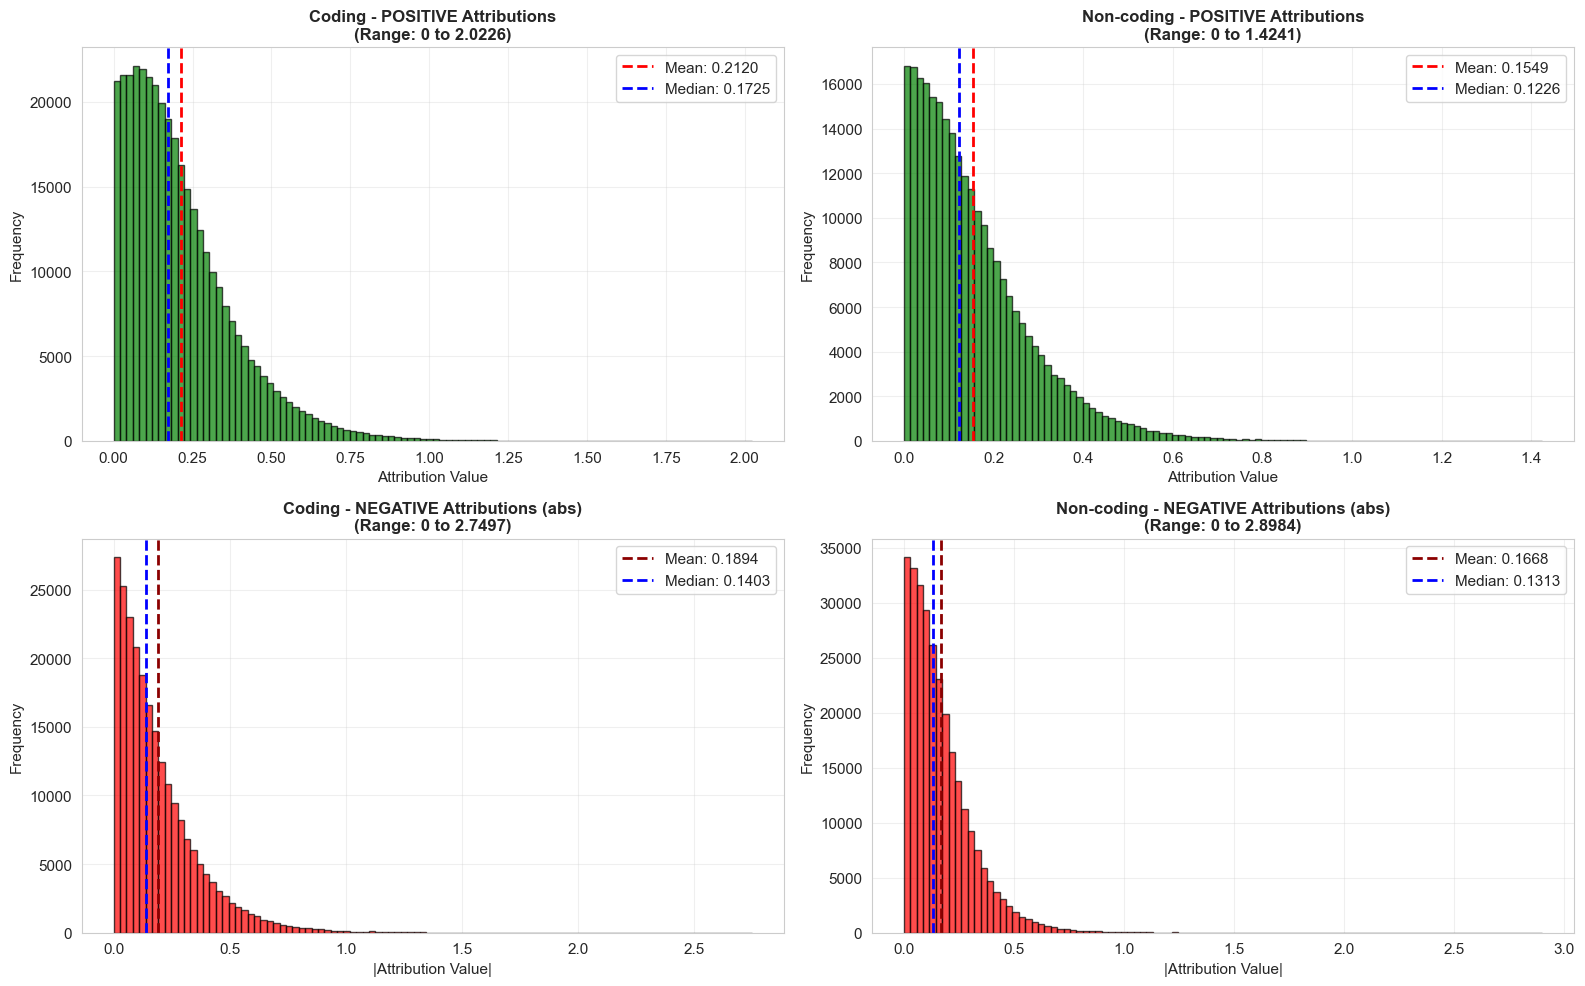


Interpretation:
  • Green histograms: Distribution of tokens SUPPORTING the classification
  • Red histograms: Distribution of tokens OPPOSING the classification
  • Longer tail = model uses some tokens with very strong influence
  • Sharp peak near zero = most tokens have weak individual influence


In [5]:
def visualize_attribution_ranges(df, only_correct=True):
    """
    Visualize the distribution of attribution strengths
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        positive_attrs = []
        negative_attrs = []
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    if attr > 0:
                        positive_attrs.append(attr)
                    else:
                        negative_attrs.append(attr)
        
        # Histogram of positive attributions
        axes[0, col_idx].hist(positive_attrs, bins=100, color='green', alpha=0.7, edgecolor='black')
        axes[0, col_idx].set_xlabel('Attribution Value', fontsize=11)
        axes[0, col_idx].set_ylabel('Frequency', fontsize=11)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attributions\n(Range: 0 to {max(positive_attrs):.4f})', 
                                   fontsize=12, fontweight='bold')
        axes[0, col_idx].grid(True, alpha=0.3)
        axes[0, col_idx].axvline(np.mean(positive_attrs), color='red', linestyle='--', 
                                linewidth=2, label=f'Mean: {np.mean(positive_attrs):.4f}')
        axes[0, col_idx].axvline(np.median(positive_attrs), color='blue', linestyle='--',
                                linewidth=2, label=f'Median: {np.median(positive_attrs):.4f}')
        axes[0, col_idx].legend()
        
        # Histogram of negative attributions (absolute values)
        negative_attrs_abs = [abs(x) for x in negative_attrs]
        axes[1, col_idx].hist(negative_attrs_abs, bins=100, color='red', alpha=0.7, edgecolor='black')
        axes[1, col_idx].set_xlabel('|Attribution Value|', fontsize=11)
        axes[1, col_idx].set_ylabel('Frequency', fontsize=11)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attributions (abs)\n(Range: 0 to {max(negative_attrs_abs):.4f})',
                                   fontsize=12, fontweight='bold')
        axes[1, col_idx].grid(True, alpha=0.3)
        axes[1, col_idx].axvline(np.mean(negative_attrs_abs), color='darkred', linestyle='--',
                                linewidth=2, label=f'Mean: {np.mean(negative_attrs_abs):.4f}')
        axes[1, col_idx].axvline(np.median(negative_attrs_abs), color='blue', linestyle='--',
                                linewidth=2, label=f'Median: {np.median(negative_attrs_abs):.4f}')
        axes[1, col_idx].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print("  • Green histograms: Distribution of tokens SUPPORTING the classification")
    print("  • Red histograms: Distribution of tokens OPPOSING the classification")
    print("  • Longer tail = model uses some tokens with very strong influence")
    print("  • Sharp peak near zero = most tokens have weak individual influence")

# Run visualization
visualize_attribution_ranges(df, only_correct=True)


## 1.1 High-Attribution K-mer Identification

In [6]:
def identify_discriminative_kmers_by_sign(df, top_percentile=95, only_correct=True):
    """
    Find k-mers with high POSITIVE and NEGATIVE attributions separately
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    coding_df = df[df['sequence_type'] == 'coding']
    noncoding_df = df[df['sequence_type'] == 'non-coding']
    
    results = {}
    
    for seq_type, subset_df in [('coding', coding_df), ('non-coding', noncoding_df)]:
        positive_tokens = []  # Tokens supporting the prediction
        negative_tokens = []  # Tokens opposing the prediction
        
        for _, row in subset_df.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            # Filter special tokens
            filtered = [(t, a) for t, a in zip(tokens, attrs) 
                       if t not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']]
            
            if not filtered:
                continue
            
            # Separate by sign
            for token, attr in filtered:
                if attr > 0:
                    positive_tokens.append(token)
                elif attr < 0:
                    negative_tokens.append(token)
        
        # Get top tokens by frequency
        freq_positive = Counter(positive_tokens)
        freq_negative = Counter(negative_tokens)
        
        results[seq_type] = {
            'positive': freq_positive,
            'negative': freq_negative
        }
        
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} Sequences - Discriminative Tokens")
        print(f"{'='*70}")
        
        print(f"\n  ✓ POSITIVE Attribution Tokens (support '{seq_type}' classification):")
        print(f"  {'Rank':<6} {'Token':<20} {'Frequency':<12}")
        print("  " + "-" * 40)
        for rank, (token, count) in enumerate(freq_positive.most_common(20), 1):
            print(f"  {rank:<6} {token:<20} {count:<12}")
        
        print(f"\n  ✗ NEGATIVE Attribution Tokens (oppose '{seq_type}' classification):")
        print(f"  {'Rank':<6} {'Token':<20} {'Frequency':<12}")
        print("  " + "-" * 40)
        for rank, (token, count) in enumerate(freq_negative.most_common(20), 1):
            print(f"  {rank:<6} {token:<20} {count:<12}")
    
    return results

# Run analysis
discriminative_kmers = identify_discriminative_kmers_by_sign(df, top_percentile=95, only_correct=True)


CODING Sequences - Discriminative Tokens

  ✓ POSITIVE Attribution Tokens (support 'coding' classification):
  Rank   Token                Frequency   
  ----------------------------------------
  1      GC                   11893       
  2      G                    11386       
  3      GG                   10571       
  4      AGC                  9884        
  5      TGG                  8529        
  6      ACC                  8428        
  7      ATC                  7227        
  8      AAC                  6974        
  9      GGC                  6882        
  10     AC                   6685        
  11     AAG                  6239        
  12     TCC                  5665        
  13     GCC                  5535        
  14     ATG                  5303        
  15     TAC                  5119        
  16     TGC                  4837        
  17     TTC                  4742        
  18     ATCC                 4353        
  19     AGG                  

---
# CATEGORY 2: Biological Feature Validation (Positive/Negative Separation)

## known motifs


In [7]:
def check_known_motif_enrichment_by_sign(df, only_correct=True):
    """
    Check if known biological motifs have positive or negative attributions
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    # Define known motifs
    known_motifs = {
        'coding': {
            'ATG': 'Start codon',
            'TAA': 'Stop codon (Amber)',
            'TAG': 'Stop codon (Ochre)',
            'TGA': 'Stop codon (Opal)',
            'TGG': 'Tryptophan codon',
            'GC': 'GC-rich coding region',
            'AGG': 'Arginine codon',
            'CCC': 'Proline codon',
            'AAC': 'Asparagine codon',
        },
        'non-coding': {
            'TATA': 'TATA box (promoter)',
            'CAAT': 'CAAT box (promoter)',
            'TTTT': 'Poly-T terminator',
            'AAAA': 'Poly-A signal',
            'TGTG': 'Repetitive element',
            'AT': 'AT-rich non-coding',
        }
    }
    
    all_results = {}
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        motif_data = {motif: {'positive': [], 'negative': []} for motif in known_motifs[seq_type]}
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    continue
                
                # Check if token contains known motif
                for motif in known_motifs[seq_type].keys():
                    if motif in token or token in motif or token == motif:
                        if attr > 0:
                            motif_data[motif]['positive'].append(attr)
                        else:
                            motif_data[motif]['negative'].append(attr)
                        break
        
        all_results[seq_type] = motif_data
        
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Known motif attribution (by sign)")
        print(f"{'='*70}\n")
        
        for motif, data in motif_data.items():
            pos_attrs = data['positive']
            neg_attrs = data['negative']
            total = len(pos_attrs) + len(neg_attrs)
            
            if total > 0:
                print(f"  {motif} ({known_motifs[seq_type][motif]}):")
                print(f"    Total occurrences: {total}")
                
                if pos_attrs:
                    print(f"    ✓ POSITIVE ({len(pos_attrs)}, {100*len(pos_attrs)/total:.1f}%):")
                    print(f"       Mean: +{np.mean(pos_attrs):.4f}, Median: +{np.median(pos_attrs):.4f}")
                
                if neg_attrs:
                    print(f"    ✗ NEGATIVE ({len(neg_attrs)}, {100*len(neg_attrs)/total:.1f}%):")
                    print(f"       Mean: {np.mean(neg_attrs):.4f}, Median: {np.median(neg_attrs):.4f}")
                
                print()
            else:
                print(f"  {motif} ({known_motifs[seq_type][motif]}): NOT FOUND\n")
    
    return all_results

# Run analysis
motif_results = check_known_motif_enrichment_by_sign(df, only_correct=True)


CODING - Known motif attribution (by sign)

  ATG (Start codon):
    Total occurrences: 58322
    ✓ POSITIVE (41071, 70.4%):
       Mean: +0.2168, Median: +0.1832
    ✗ NEGATIVE (17251, 29.6%):
       Mean: -0.1507, Median: -0.1148

  TAA (Stop codon (Amber)):
    Total occurrences: 15790
    ✓ POSITIVE (8272, 52.4%):
       Mean: +0.1669, Median: +0.1297
    ✗ NEGATIVE (7518, 47.6%):
       Mean: -0.1670, Median: -0.1292

  TAG (Stop codon (Ochre)):
    Total occurrences: 14953
    ✓ POSITIVE (9349, 62.5%):
       Mean: +0.1806, Median: +0.1438
    ✗ NEGATIVE (5604, 37.5%):
       Mean: -0.1490, Median: -0.1049

  TGA (Stop codon (Opal)):
    Total occurrences: 9581
    ✓ POSITIVE (5734, 59.8%):
       Mean: +0.1922, Median: +0.1631
    ✗ NEGATIVE (3847, 40.2%):
       Mean: -0.1796, Median: -0.1354

  TGG (Tryptophan codon):
    Total occurrences: 57849
    ✓ POSITIVE (35772, 61.8%):
       Mean: +0.2308, Median: +0.1892
    ✗ NEGATIVE (22077, 38.2%):
       Mean: -0.2193, Median: -

## 2.2 GC Content vs Attribution


CODING - Positive attributions:
  GC-content correlation: -0.0873
  N tokens: 362038

CODING - Negative attributions:
  GC-content correlation: -0.0357
  N tokens: 233883

NON-CODING - Positive attributions:
  GC-content correlation: 0.0538
  N tokens: 265442

NON-CODING - Negative attributions:
  GC-content correlation: 0.0094
  N tokens: 285288


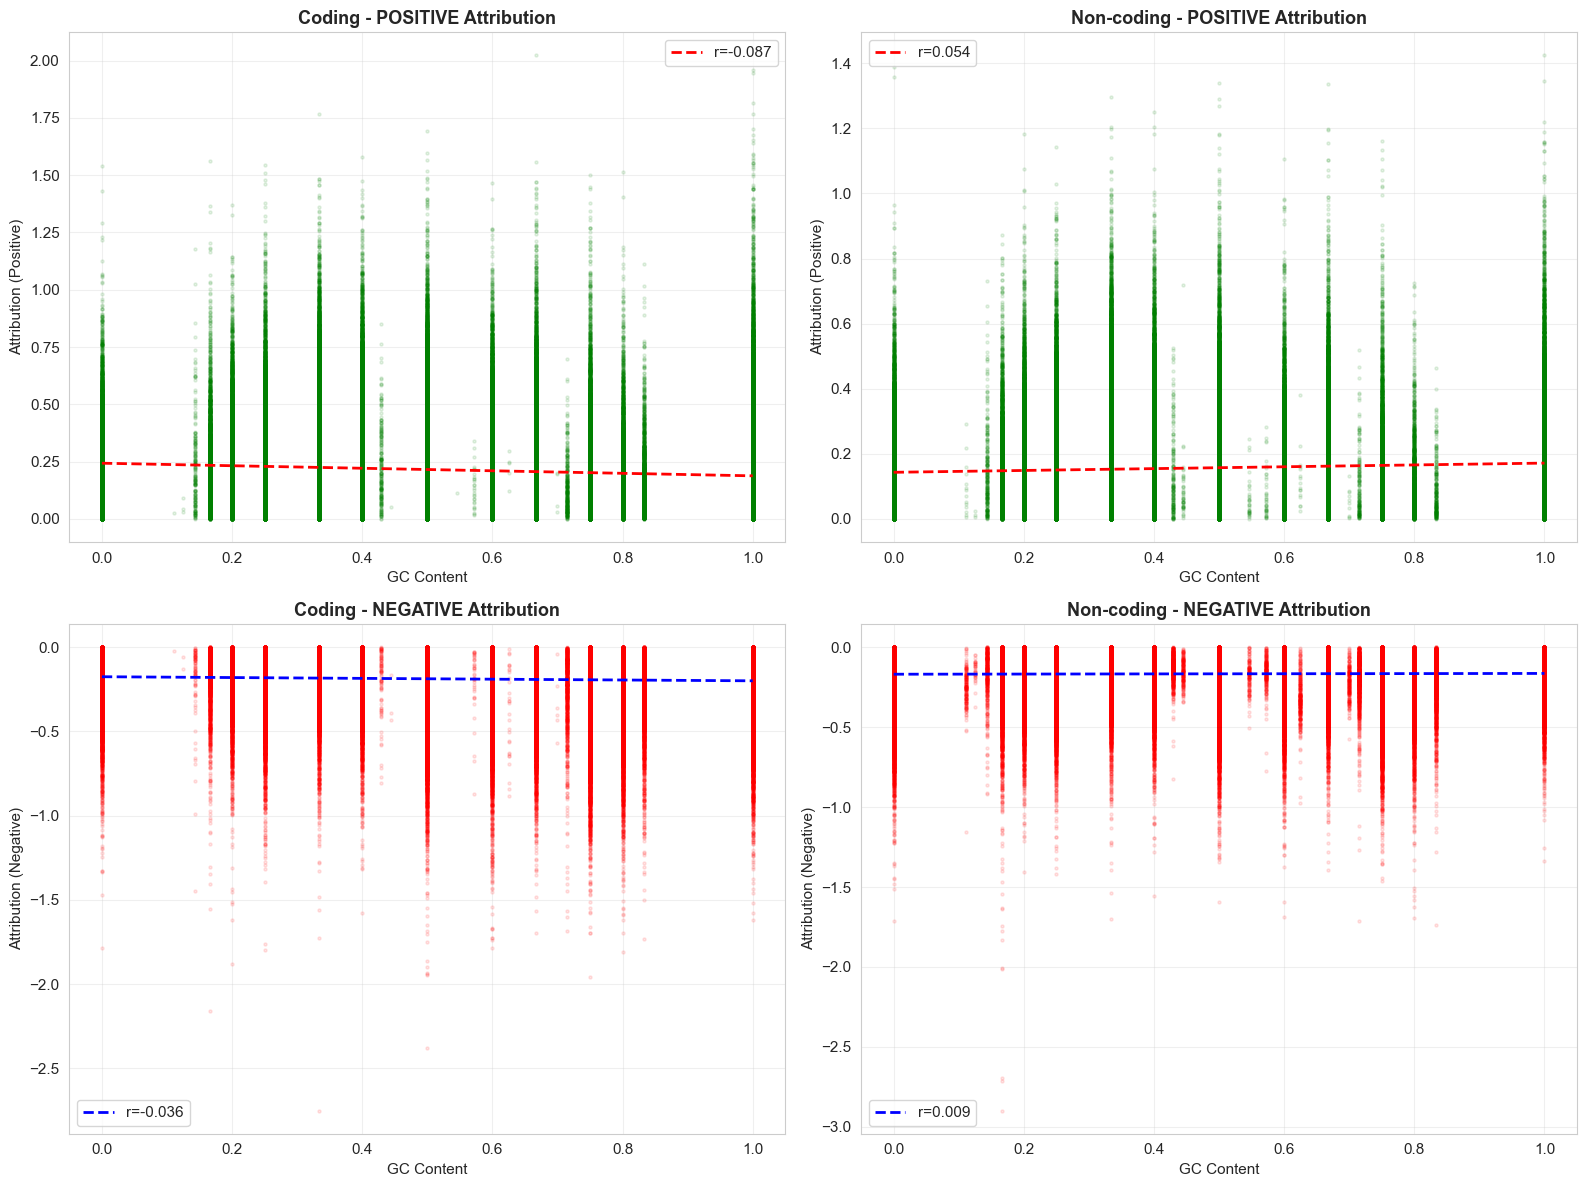

In [8]:
def analyze_gc_content_by_sign(df, only_correct=True):
    """
    Analyze GC content correlation separately for positive and negative attributions
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    def get_gc_content(token):
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        gc_count = token.upper().count('G') + token.upper().count('C')
        return gc_count / len(token) if len(token) > 0 else 0
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        gc_pos, attr_pos = [], []
        gc_neg, attr_neg = [], []
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                gc = get_gc_content(token)
                if gc is not None:
                    if attr > 0:
                        gc_pos.append(gc)
                        attr_pos.append(attr)
                    else:
                        gc_neg.append(gc)
                        attr_neg.append(attr)
        
        # Positive attributions
        if len(gc_pos) > 0:
            corr_pos = np.corrcoef(gc_pos, attr_pos)[0, 1]
            axes[0, col_idx].scatter(gc_pos, attr_pos, alpha=0.1, s=5, color='green')
            z = np.polyfit(gc_pos, attr_pos, 1)
            p = np.poly1d(z)
            x_line = np.linspace(0, 1, 100)
            axes[0, col_idx].plot(x_line, p(x_line), "r--", linewidth=2, label=f'r={corr_pos:.3f}')
            axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution', fontsize=13, fontweight='bold')
            axes[0, col_idx].set_xlabel('GC Content')
            axes[0, col_idx].set_ylabel('Attribution (Positive)')
            axes[0, col_idx].legend()
            axes[0, col_idx].grid(True, alpha=0.3)
            
            print(f"\n{seq_type.upper()} - Positive attributions:")
            print(f"  GC-content correlation: {corr_pos:.4f}")
            print(f"  N tokens: {len(gc_pos)}")
        
        # Negative attributions
        if len(gc_neg) > 0:
            corr_neg = np.corrcoef(gc_neg, attr_neg)[0, 1]
            axes[1, col_idx].scatter(gc_neg, attr_neg, alpha=0.1, s=5, color='red')
            z = np.polyfit(gc_neg, attr_neg, 1)
            p = np.poly1d(z)
            x_line = np.linspace(0, 1, 100)
            axes[1, col_idx].plot(x_line, p(x_line), "b--", linewidth=2, label=f'r={corr_neg:.3f}')
            axes[1, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attribution', fontsize=13, fontweight='bold')
            axes[1, col_idx].set_xlabel('GC Content')
            axes[1, col_idx].set_ylabel('Attribution (Negative)')
            axes[1, col_idx].legend()
            axes[1, col_idx].grid(True, alpha=0.3)
            
            print(f"\n{seq_type.upper()} - Negative attributions:")
            print(f"  GC-content correlation: {corr_neg:.4f}")
            print(f"  N tokens: {len(gc_neg)}")
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_gc_content_by_sign(df, only_correct=True)

---
# CATEGORY 3: Token Interaction & Context Analysis

## 3.1 Co-occurring Token Patterns (Separated by Sign)

In [9]:
def find_cooccurring_patterns_by_sign(df, window=3, min_support=5, attr_threshold=0.1, only_correct=True):
    """
    Find co-occurring patterns separately for positive and negative attributions
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        positive_patterns = defaultdict(int)
        negative_patterns = defaultdict(int)
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            filtered = [(t, a) for t, a in zip(tokens, attrs)
                       if t not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']]
            
            if len(filtered) < window:
                continue
            
            tokens_filtered = [t for t, _ in filtered]
            attrs_filtered = [a for _, a in filtered]
            
            for i in range(len(tokens_filtered) - window + 1):
                window_tokens = tokens_filtered[i:i+window]
                window_attrs = attrs_filtered[i:i+window]
                
                # Check if most tokens have high attribution
                high_attr_count = sum(1 for a in window_attrs if abs(a) > attr_threshold)
                if high_attr_count >= window // 2:
                    pattern = ' → '.join(window_tokens)
                    # Determine if mostly positive or negative
                    avg_attr = np.mean(window_attrs)
                    if avg_attr > 0:
                        positive_patterns[pattern] += 1
                    else:
                        negative_patterns[pattern] += 1
        
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Co-occurring patterns (by sign)")
        print(f"{'='*70}")
        
        print(f"\n  ✓ POSITIVE Attribution Patterns:")
        pos_found = [(p, c) for p, c in positive_patterns.items() if c >= min_support]
        pos_found.sort(key=lambda x: x[1], reverse=True)
        if pos_found:
            for rank, (pattern, count) in enumerate(pos_found[:15], 1):
                print(f"    {rank:2d}. {pattern} (n={count})")
        else:
            print(f"    None found (try lowering min_support={min_support})")
        
        print(f"\n  ✗ NEGATIVE Attribution Patterns:")
        neg_found = [(p, c) for p, c in negative_patterns.items() if c >= min_support]
        neg_found.sort(key=lambda x: x[1], reverse=True)
        if neg_found:
            for rank, (pattern, count) in enumerate(neg_found[:15], 1):
                print(f"    {rank:2d}. {pattern} (n={count})")
        else:
            print(f"    None found (try lowering min_support={min_support})")

# Run analysis
find_cooccurring_patterns_by_sign(df, window=3, min_support=5, attr_threshold=0.1, only_correct=True)


CODING - Co-occurring patterns (by sign)

  ✓ POSITIVE Attribution Patterns:
     1. GGC → GGC → GGC (n=170)
     2. GC → GC → GC (n=108)
     3. GCC → GCC → GCC (n=105)
     4. GC → GC → GG (n=65)
     5. GGC → GGC → GG (n=62)
     6. GGC → GC → GC (n=61)
     7. GC → GG → GGC (n=56)
     8. GC → GG → CCC (n=55)
     9. GC → GC → TGC (n=54)
    10. GG → GGC → GC (n=53)
    11. GC → GGC → GC (n=52)
    12. GGC → GGC → G (n=51)
    13. GC → GCC → CC (n=49)
    14. AGC → GC → GC (n=48)
    15. GCC → GC → GC (n=47)

  ✗ NEGATIVE Attribution Patterns:
     1. GCC → GCC → GCC (n=27)
     2. GC → TC → GG (n=18)
     3. TGGG → GCC → CC (n=16)
     4. TC → GG → GGC (n=15)
     5. GGC → GGC → GGC (n=15)
     6. GGC → G → TC (n=15)
     7. TC → GG → TG (n=13)
     8. GC → GC → TC (n=13)
     9. GC → TC → GGG (n=11)
    10. TC → GG → AC (n=11)
    11. GC → GCC → GC (n=11)
    12. AC → GCC → GCC (n=11)
    13. GCC → GCC → GC (n=10)
    14. TC → AGCC → TC (n=10)
    15. TGC → GGG → AGC (n=10)

NON


Attribution Statistics (by type and sign)

CODING - POS attributions:
  N: 362038
  Mean: +0.2120
  Median: +0.1725
  Std: 0.1716

CODING - NEG attributions:
  N: 233883
  Mean: -0.1894
  Median: -0.1403
  Std: 0.1763

NON-CODING - POS attributions:
  N: 265442
  Mean: +0.1549
  Median: +0.1226
  Std: 0.1305

NON-CODING - NEG attributions:
  N: 285288
  Mean: -0.1668
  Median: -0.1313
  Std: 0.1440



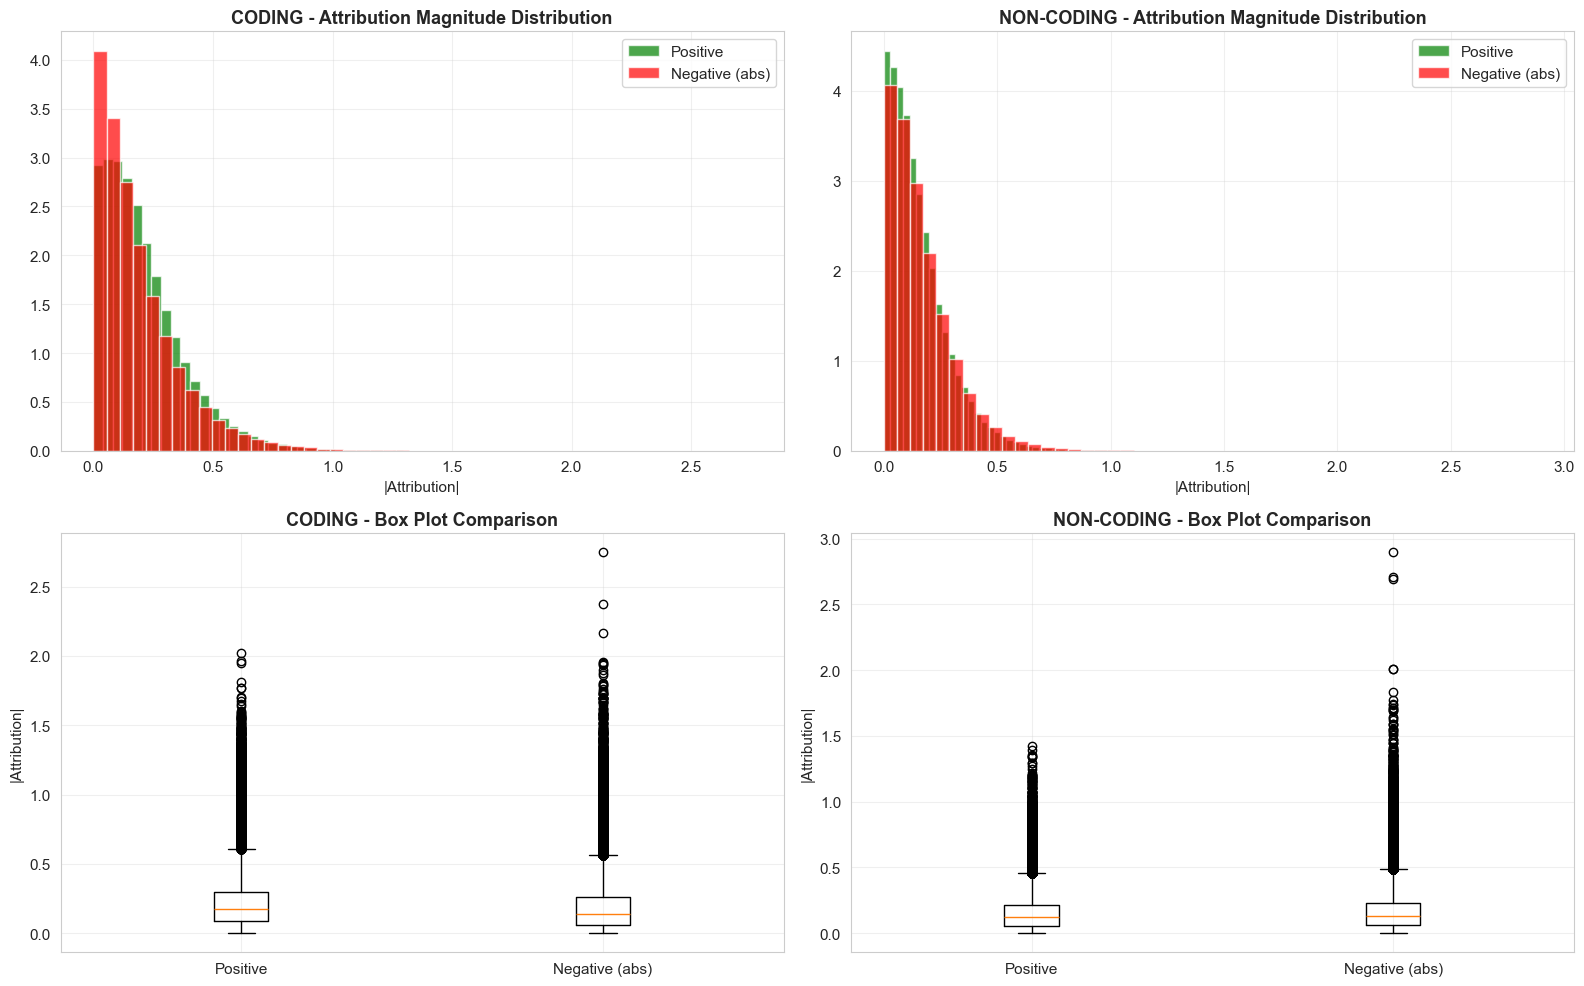

In [10]:
def compare_attribution_distributions_by_sign(df, only_correct=True):
    """
    Compare positive and negative attribution patterns
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    data = {
        'coding_pos': [], 'coding_neg': [],
        'non-coding_pos': [], 'non-coding_neg': []
    }
    
    for _, row in df.iterrows():
        attrs = [float(x) for x in row['attributions'].split('|')]
        seq_type = row['sequence_type']
        
        for attr in attrs:
            if attr > 0:
                data[f'{seq_type}_pos'].append(attr)
            else:
                data[f'{seq_type}_neg'].append(attr)
    
    print(f"\n{'='*70}")
    print(f"Attribution Statistics (by type and sign)")
    print(f"{'='*70}\n")
    
    for key, attrs in data.items():
        if attrs:
            seq_type, sign = key.rsplit('_', 1)
            print(f"{seq_type.upper()} - {sign.upper()} attributions:")
            print(f"  N: {len(attrs)}")
            print(f"  Mean: {np.mean(attrs):+.4f}")
            print(f"  Median: {np.median(attrs):+.4f}")
            print(f"  Std: {np.std(attrs):.4f}\n")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Coding - Positive vs Negative
    axes[0, 0].hist(data['coding_pos'], bins=50, alpha=0.7, color='green', label='Positive', density=True)
    axes[0, 0].hist([abs(x) for x in data['coding_neg']], bins=50, alpha=0.7, color='red', label='Negative (abs)', density=True)
    axes[0, 0].set_title('CODING - Attribution Magnitude Distribution', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('|Attribution|')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Non-coding - Positive vs Negative
    axes[0, 1].hist(data['non-coding_pos'], bins=50, alpha=0.7, color='green', label='Positive', density=True)
    axes[0, 1].hist([abs(x) for x in data['non-coding_neg']], bins=50, alpha=0.7, color='red', label='Negative (abs)', density=True)
    axes[0, 1].set_title('NON-CODING - Attribution Magnitude Distribution', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('|Attribution|')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Box plots
    axes[1, 0].boxplot([data['coding_pos'], [abs(x) for x in data['coding_neg']]],
                       labels=['Positive', 'Negative (abs)'])
    axes[1, 0].set_title('CODING - Box Plot Comparison', fontsize=13, fontweight='bold')
    axes[1, 0].set_ylabel('|Attribution|')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].boxplot([data['non-coding_pos'], [abs(x) for x in data['non-coding_neg']]],
                       labels=['Positive', 'Negative (abs)'])
    axes[1, 1].set_title('NON-CODING - Box Plot Comparison', fontsize=13, fontweight='bold')
    axes[1, 1].set_ylabel('|Attribution|')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run analysis
compare_attribution_distributions_by_sign(df, only_correct=True)


CODING - Token length effect:

Positive attributions:
Length   Mean         Count     
--------------------------------
1        0.1943       17222     
2        0.1787       42504     
3        0.2123       109966    
4        0.2033       95534     
5        0.2341       68255     
6        0.2485       27641     
7        0.2032       874       
8        0.1387       33        
9        0.0388       2         
10       0.1184       4         
11       0.1138       1         
12       0.1119       1         
16       0.1409       1         

Negative attributions:
Length   Mean |Attr|  Count     
--------------------------------
1        0.0989       2792      
2        0.1388       26874     
3        0.1580       52154     
4        0.2068       83827     
5        0.2129       47206     
6        0.2175       19672     
7        0.2587       1144      
8        0.3968       197       
9        0.2529       4         
10       0.3402       6         
12       0.5082       7       

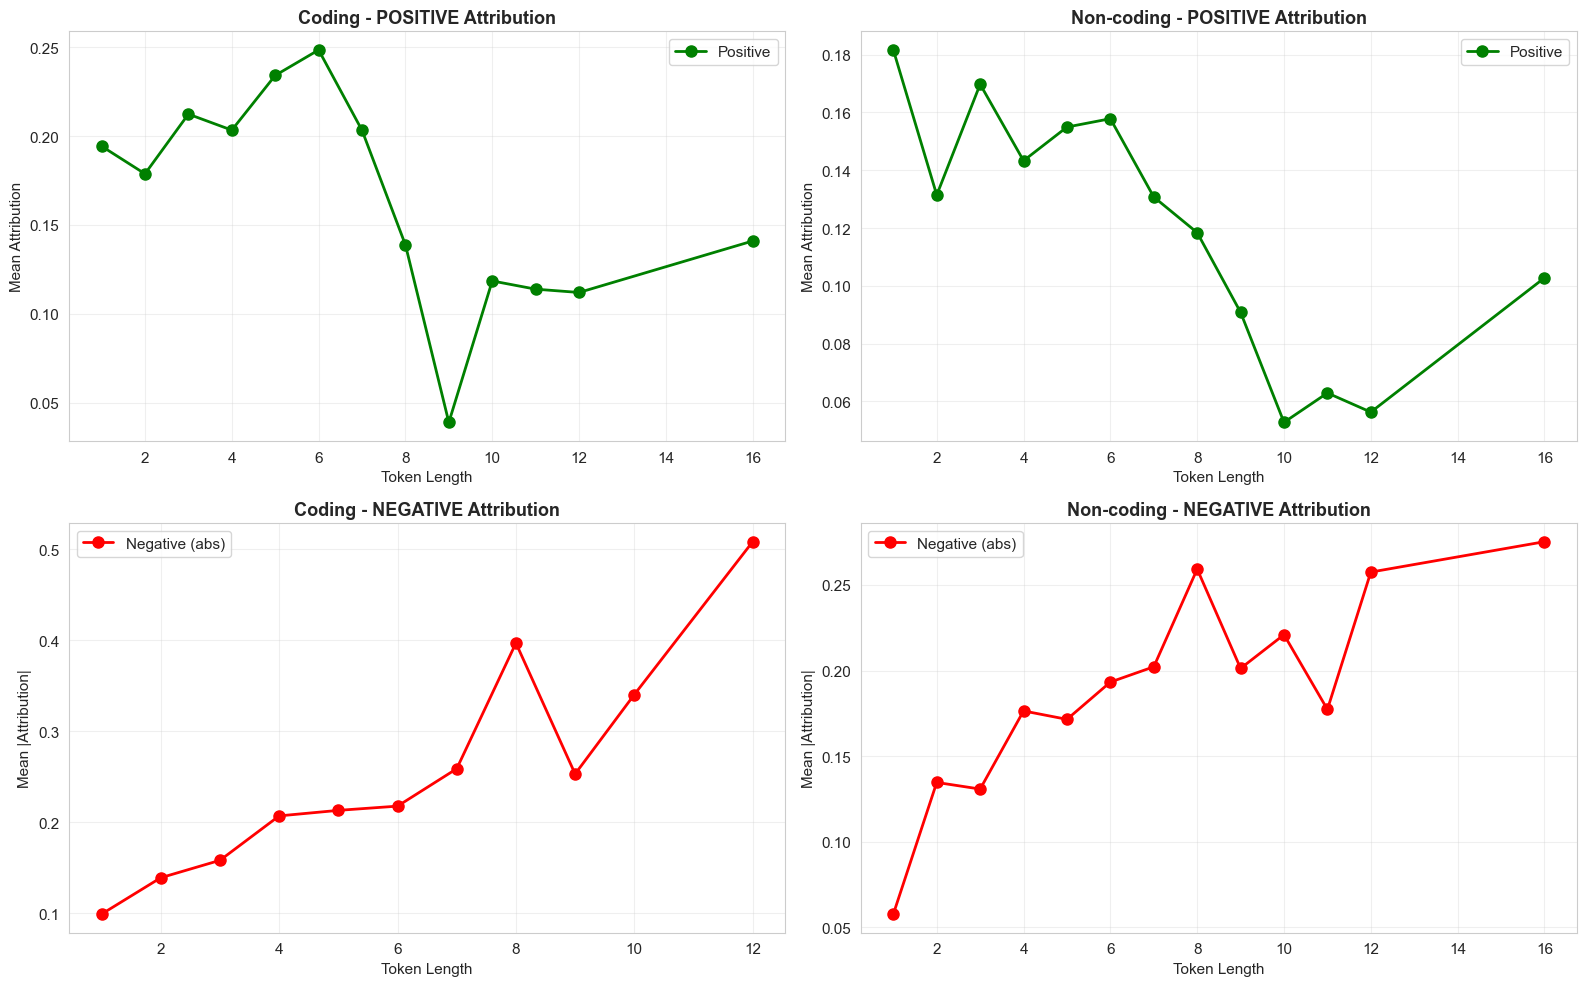

In [11]:
def analyze_token_length_by_sign(df, only_correct=True):
    """
    Analyze token length effect separately for positive/negative attributions
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        length_pos = defaultdict(list)
        length_neg = defaultdict(list)
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    if attr > 0:
                        length_pos[len(token)].append(attr)
                    else:
                        length_neg[len(token)].append(abs(attr))
        
        # Positive attributions
        lengths_pos = sorted(length_pos.keys())
        means_pos = [np.mean(length_pos[l]) for l in lengths_pos]
        
        axes[0, col_idx].plot(lengths_pos, means_pos, marker='o', linewidth=2, 
                             markersize=8, color='green', label='Positive')
        axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution', 
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].set_xlabel('Token Length')
        axes[0, col_idx].set_ylabel('Mean Attribution')
        axes[0, col_idx].grid(True, alpha=0.3)
        axes[0, col_idx].legend()
        
        # Negative attributions
        lengths_neg = sorted(length_neg.keys())
        means_neg = [np.mean(length_neg[l]) for l in lengths_neg]
        
        axes[1, col_idx].plot(lengths_neg, means_neg, marker='o', linewidth=2,
                             markersize=8, color='red', label='Negative (abs)')
        axes[1, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attribution',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].set_xlabel('Token Length')
        axes[1, col_idx].set_ylabel('Mean |Attribution|')
        axes[1, col_idx].grid(True, alpha=0.3)
        axes[1, col_idx].legend()
        
        # Print statistics
        print(f"\n{seq_type.upper()} - Token length effect:")
        print("\nPositive attributions:")
        print(f"{'Length':<8} {'Mean':<12} {'Count':<10}")
        print("-" * 32)
        for l, m in zip(lengths_pos, means_pos):
            print(f"{l:<8} {m:<12.4f} {len(length_pos[l]):<10}")
        
        print("\nNegative attributions:")
        print(f"{'Length':<8} {'Mean |Attr|':<12} {'Count':<10}")
        print("-" * 32)
        for l, m in zip(lengths_neg, means_neg):
            print(f"{l:<8} {m:<12.4f} {len(length_neg[l]):<10}")
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_token_length_by_sign(df, only_correct=True)

dont do mean, plot everything in scatterplots

---
# CATEGORY 5: Model Interpretation

## 5.1 Positive vs Negative Attribution Ratio


CODING - Positive/Negative Attribution Ratio:
  Mean: 1.8967
  Median: 1.7349
  Interpretation: Higher ratio = model more confident (positive support >> negative contradiction)

NON-CODING - Positive/Negative Attribution Ratio:
  Mean: 0.8640
  Median: 0.8611
  Interpretation: Higher ratio = model more confident (positive support >> negative contradiction)


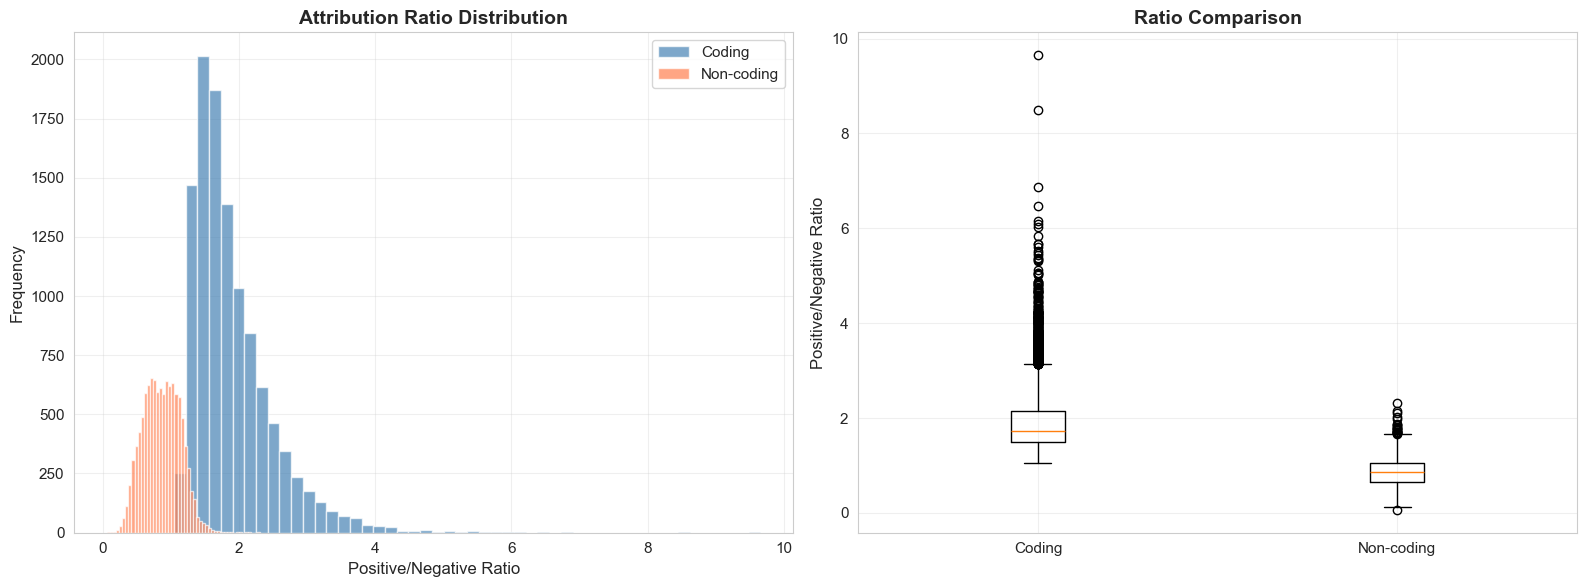

In [12]:
def analyze_positive_negative_ratio(df, only_correct=True):
    """
    Analyze the ratio of positive to negative attributions
    Shows how 'confident' the model is in its predictions
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    ratios = {'coding': [], 'non-coding': []}
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        for _, row in subset.iterrows():
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            pos_sum = sum(a for a in attrs if a > 0)
            neg_sum = abs(sum(a for a in attrs if a < 0))
            
            if neg_sum > 0:
                ratio = pos_sum / neg_sum
                ratios[seq_type].append(ratio)
        
        print(f"\n{seq_type.upper()} - Positive/Negative Attribution Ratio:")
        print(f"  Mean: {np.mean(ratios[seq_type]):.4f}")
        print(f"  Median: {np.median(ratios[seq_type]):.4f}")
        print(f"  Interpretation: Higher ratio = model more confident (positive support >> negative contradiction)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].hist(ratios['coding'], bins=50, alpha=0.7, color='steelblue', label='Coding')
    axes[0].hist(ratios['non-coding'], bins=50, alpha=0.7, color='coral', label='Non-coding')
    axes[0].set_xlabel('Positive/Negative Ratio', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Attribution Ratio Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].boxplot([ratios['coding'], ratios['non-coding']], labels=['Coding', 'Non-coding'])
    axes[1].set_ylabel('Positive/Negative Ratio', fontsize=12)
    axes[1].set_title('Ratio Comparison', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_positive_negative_ratio(df, only_correct=True)

## 5.2 Attribution Entropy (Overall)


CODING - Attribution Entropy:
  Mean: 3.6768
  Median: 3.6755
  (Lower = focused on few tokens, Higher = distributed)

NON-CODING - Attribution Entropy:
  Mean: 3.6088
  Median: 3.6131
  (Lower = focused on few tokens, Higher = distributed)


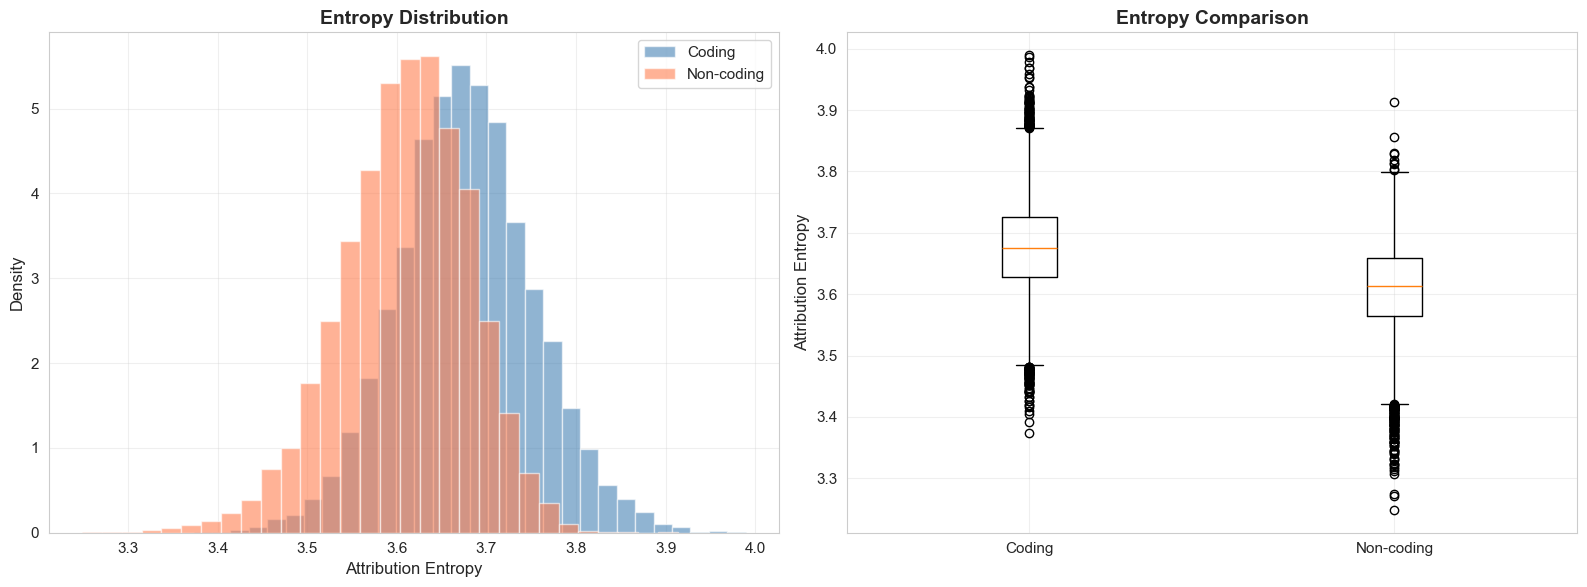

In [13]:
def compute_attribution_entropy(df, only_correct=True):
    """
    Measure how 'focused' or 'distributed' attributions are
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    all_entropies = {'coding': [], 'non-coding': []}
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        entropies = []
        
        for _, row in subset.iterrows():
            attrs = [float(x) for x in row['attributions'].split('|')]
            attrs_abs = np.abs(attrs)
            if attrs_abs.sum() > 0:
                probs = attrs_abs / attrs_abs.sum()
                ent = entropy(probs)
                entropies.append(ent)
        
        all_entropies[seq_type] = entropies
        
        print(f"\n{seq_type.upper()} - Attribution Entropy:")
        print(f"  Mean: {np.mean(entropies):.4f}")
        print(f"  Median: {np.median(entropies):.4f}")
        print(f"  (Lower = focused on few tokens, Higher = distributed)")
    
    axes[0].hist(all_entropies['coding'], bins=30, alpha=0.6, label='Coding', color='steelblue', density=True)
    axes[0].hist(all_entropies['non-coding'], bins=30, alpha=0.6, label='Non-coding', color='coral', density=True)
    axes[0].set_xlabel('Attribution Entropy', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].set_title('Entropy Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].boxplot([all_entropies['coding'], all_entropies['non-coding']], 
                    labels=['Coding', 'Non-coding'])
    axes[1].set_ylabel('Attribution Entropy', fontsize=12)
    axes[1].set_title('Entropy Comparison', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run analysis
compute_attribution_entropy(df, only_correct=True)

## 6.1 Unexpected High-Attribution Tokens

In [14]:
def find_unexpected_discriminators_by_sign(df, known_motifs_coding, known_motifs_noncoding,
                                          min_occurrences=10, attr_threshold=0.15, only_correct=True):
    """
    Find novel tokens with high positive or negative attributions
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    known_all = set(known_motifs_coding + known_motifs_noncoding)
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        token_data = defaultdict(lambda: {'positive': [], 'negative': []})
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    if attr > 0:
                        token_data[token]['positive'].append(attr)
                    else:
                        token_data[token]['negative'].append(attr)
        
        # Find novel tokens
        novel_positive = []
        novel_negative = []
        
        for token, data in token_data.items():
            # Check if known
            is_known = any(known in token or token in known for known in known_all)
            
            if not is_known:
                # Check positive
                if len(data['positive']) >= min_occurrences:
                    mean_pos = np.mean(data['positive'])
                    if mean_pos >= attr_threshold:
                        novel_positive.append((token, mean_pos, len(data['positive'])))
                
                # Check negative
                if len(data['negative']) >= min_occurrences:
                    mean_neg = np.mean(np.abs(data['negative']))
                    if mean_neg >= attr_threshold:
                        novel_negative.append((token, mean_neg, len(data['negative'])))
        
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Novel Discriminative Elements")
        print(f"{'='*70}")
        
        print(f"\n  ✓ Novel POSITIVE Attribution Tokens:")
        if novel_positive:
            novel_positive.sort(key=lambda x: x[1], reverse=True)
            print(f"  {'Rank':<6} {'Token':<15} {'Mean Attr':<15} {'Count':<10}")
            print("  " + "-" * 48)
            for rank, (token, mean_attr, count) in enumerate(novel_positive[:20], 1):
                print(f"  {rank:<6} {token:<15} {mean_attr:<15.4f} {count:<10}")
        else:
            print(f"  None found (try lowering thresholds)")
        
        print(f"\n  ✗ Novel NEGATIVE Attribution Tokens:")
        if novel_negative:
            novel_negative.sort(key=lambda x: x[1], reverse=True)
            print(f"  {'Rank':<6} {'Token':<15} {'Mean |Attr|':<15} {'Count':<10}")
            print("  " + "-" * 48)
            for rank, (token, mean_attr, count) in enumerate(novel_negative[:20], 1):
                print(f"  {rank:<6} {token:<15} {mean_attr:<15.4f} {count:<10}")
        else:
            print(f"  None found (try lowering thresholds)")

# Define known motifs
known_coding = ['ATG', 'TAA', 'TAG', 'TGA', 'TGG', 'GC', 'AGG', 'CCC', 'AAC', 'ACC']
known_noncoding = ['TATA', 'CAAT', 'TTTT', 'AAAA', 'TGTG', 'AT']

# Run analysis
find_unexpected_discriminators_by_sign(df, known_coding, known_noncoding,
                                      min_occurrences=10, attr_threshold=0.15, only_correct=True)


CODING - Novel Discriminative Elements

  ✓ Novel POSITIVE Attribution Tokens:
  Rank   Token           Mean Attr       Count     
  ------------------------------------------------
  1      AGTT            0.4916          334       
  2      TCCTCC          0.4738          376       
  3      ACTTG           0.4195          99        
  4      AGTTTG          0.4144          152       
  5      TTCTTC          0.3820          228       
  6      AGTTC           0.3790          702       
  7      TGTCC           0.3662          359       
  8      TACTG           0.3603          210       
  9      AGTTG           0.3392          295       
  10     TTGTTG          0.3348          54        
  11     AAGTC           0.3330          448       
  12     TCTTC           0.3056          780       
  13     TCCTC           0.3053          657       
  14     TACTC           0.3014          232       
  15     AAGAAG          0.2866          581       
  16     ACAAG           0.2854      

# RESULTS SUMMARY & INTERPRETATION

Let's summarize key findings and explore deeper analyses:

## Advanced Analysis 1: Attribution vs Frequency Scatterplots

Examine if high-frequency tokens have strong or weak attributions


CODING - Frequency vs Attribution Correlation
  POSITIVE: r = 0.0312
    Interpretation: Frequency and attribution strength are weakly related
  NEGATIVE: r = 0.0834
    Interpretation: Frequency and attribution strength are weakly related

NON-CODING - Frequency vs Attribution Correlation
  POSITIVE: r = 0.1527
    Interpretation: Frequency and attribution strength are weakly related
  NEGATIVE: r = 0.1308
    Interpretation: Frequency and attribution strength are weakly related


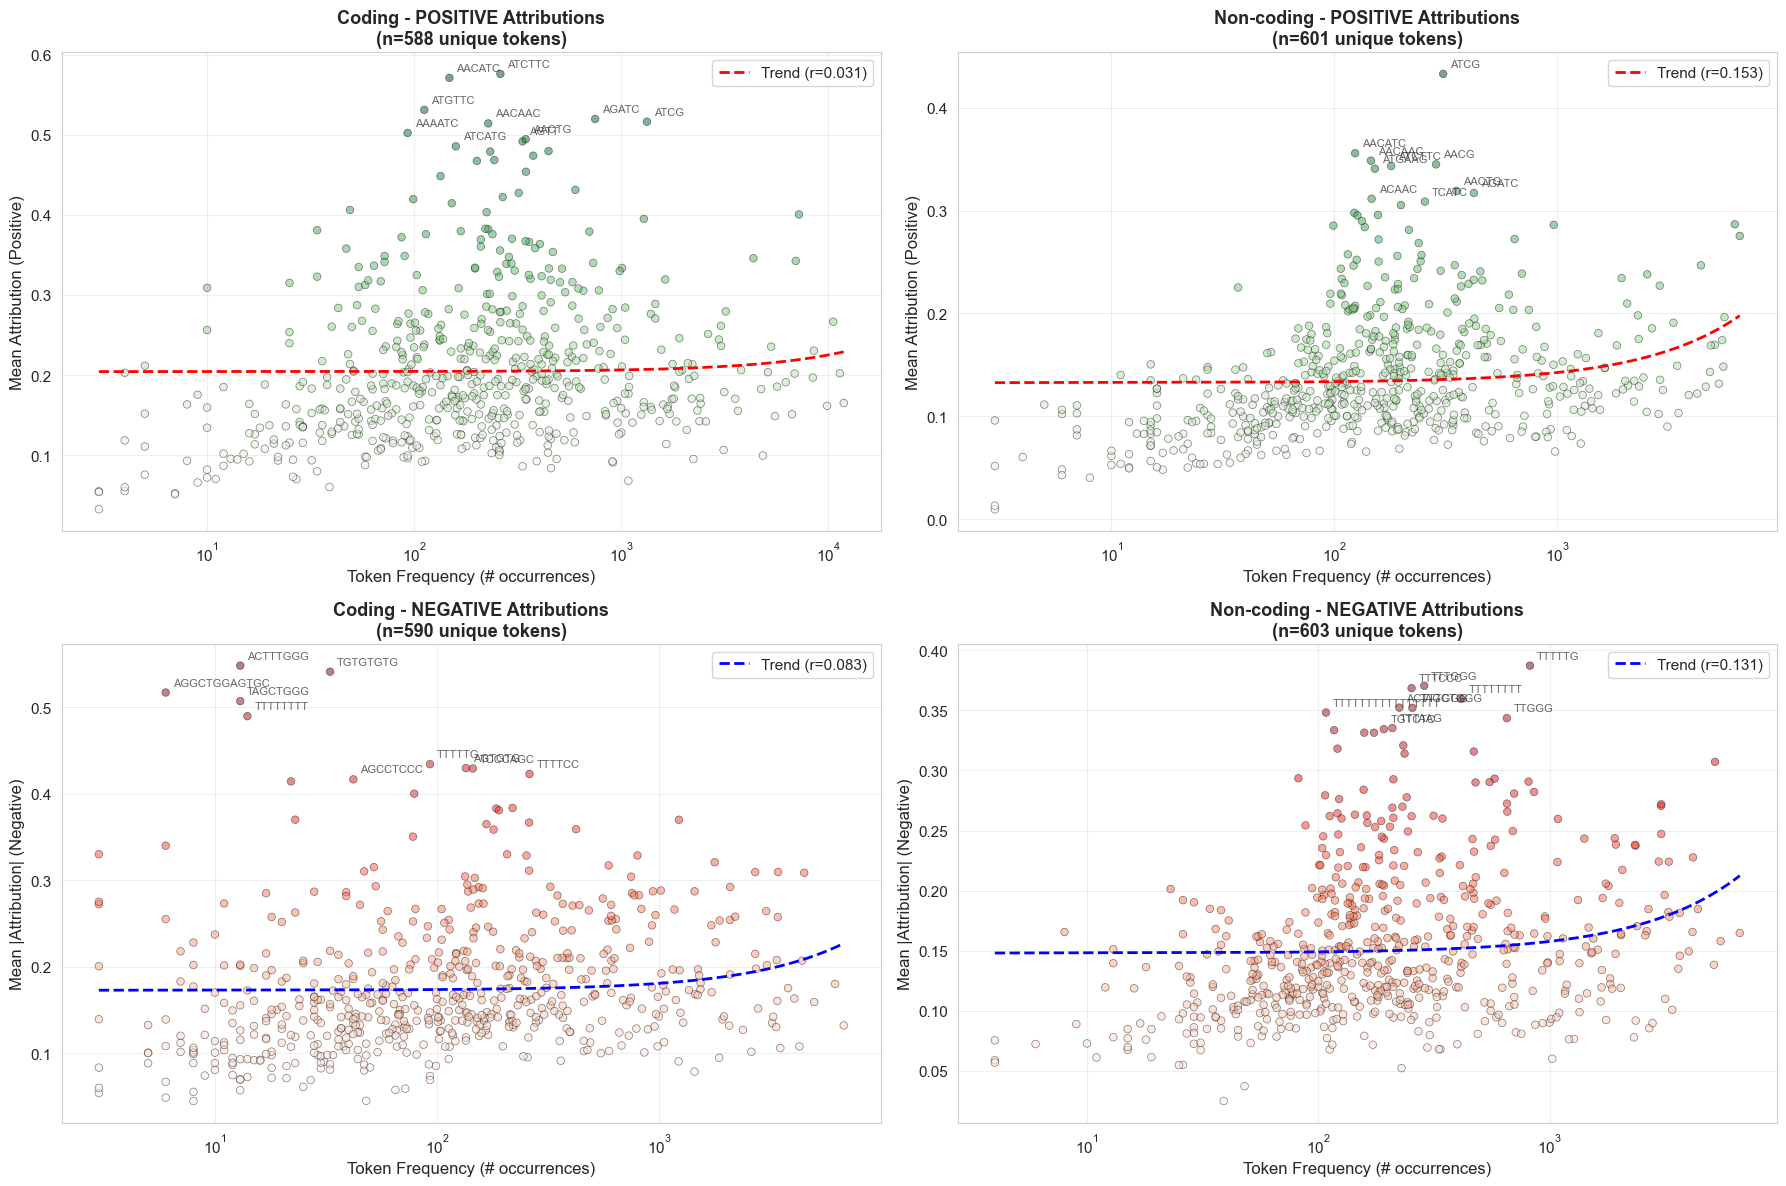

In [15]:
def attribution_vs_frequency_scatter(df, only_correct=True, min_occurrences=3):
    """
    Scatterplot: Token frequency vs attribution strength
    Shows if common tokens have strong/weak influence
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        # Collect token data
        token_positive = defaultdict(list)
        token_negative = defaultdict(list)
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    if attr > 0:
                        token_positive[token].append(attr)
                    else:
                        token_negative[token].append(attr)
        
        # Prepare data for plotting
        freq_pos, mean_attr_pos, tokens_pos = [], [], []
        for token, attrs in token_positive.items():
            if len(attrs) >= min_occurrences:
                freq_pos.append(len(attrs))
                mean_attr_pos.append(np.mean(attrs))
                tokens_pos.append(token)
        
        freq_neg, mean_attr_neg, tokens_neg = [], [], []
        for token, attrs in token_negative.items():
            if len(attrs) >= min_occurrences:
                freq_neg.append(len(attrs))
                mean_attr_neg.append(abs(np.mean(attrs)))
                tokens_neg.append(token)
        
        # POSITIVE attributions scatter
        axes[0, col_idx].scatter(freq_pos, mean_attr_pos, alpha=0.5, s=30, c=mean_attr_pos, 
                                cmap='Greens', edgecolors='black', linewidth=0.5)
        
        # Add correlation line
        if len(freq_pos) > 1:
            z = np.polyfit(freq_pos, mean_attr_pos, 1)
            p = np.poly1d(z)
            x_line = np.linspace(min(freq_pos), max(freq_pos), 100)
            corr = np.corrcoef(freq_pos, mean_attr_pos)[0, 1]
            axes[0, col_idx].plot(x_line, p(x_line), "r--", linewidth=2, 
                                 label=f'Trend (r={corr:.3f})')
        
        # Annotate top tokens
        top_indices = np.argsort(mean_attr_pos)[-10:]
        for idx in top_indices:
            axes[0, col_idx].annotate(tokens_pos[idx], 
                                     (freq_pos[idx], mean_attr_pos[idx]),
                                     fontsize=8, alpha=0.7, 
                                     xytext=(5, 5), textcoords='offset points')
        
        axes[0, col_idx].set_xlabel('Token Frequency (# occurrences)', fontsize=12)
        axes[0, col_idx].set_ylabel('Mean Attribution (Positive)', fontsize=12)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attributions\n(n={len(freq_pos)} unique tokens)',
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].legend()
        axes[0, col_idx].grid(True, alpha=0.3)
        axes[0, col_idx].set_xscale('log')
        
        # NEGATIVE attributions scatter
        axes[1, col_idx].scatter(freq_neg, mean_attr_neg, alpha=0.5, s=30, c=mean_attr_neg,
                                cmap='Reds', edgecolors='black', linewidth=0.5)
        
        # Add correlation line
        if len(freq_neg) > 1:
            z = np.polyfit(freq_neg, mean_attr_neg, 1)
            p = np.poly1d(z)
            x_line = np.linspace(min(freq_neg), max(freq_neg), 100)
            corr = np.corrcoef(freq_neg, mean_attr_neg)[0, 1]
            axes[1, col_idx].plot(x_line, p(x_line), "b--", linewidth=2,
                                 label=f'Trend (r={corr:.3f})')
        
        # Annotate top tokens
        top_indices = np.argsort(mean_attr_neg)[-10:]
        for idx in top_indices:
            axes[1, col_idx].annotate(tokens_neg[idx],
                                     (freq_neg[idx], mean_attr_neg[idx]),
                                     fontsize=8, alpha=0.7,
                                     xytext=(5, 5), textcoords='offset points')
        
        axes[1, col_idx].set_xlabel('Token Frequency (# occurrences)', fontsize=12)
        axes[1, col_idx].set_ylabel('Mean |Attribution| (Negative)', fontsize=12)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attributions\n(n={len(freq_neg)} unique tokens)',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].legend()
        axes[1, col_idx].grid(True, alpha=0.3)
        axes[1, col_idx].set_xscale('log')
        
        # Print stats
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Frequency vs Attribution Correlation")
        print(f"{'='*70}")
        if len(freq_pos) > 1:
            corr_pos = np.corrcoef(freq_pos, mean_attr_pos)[0, 1]
            print(f"  POSITIVE: r = {corr_pos:.4f}")
            print(f"    Interpretation: {'Frequent tokens have stronger attributions' if corr_pos > 0.3 else 'Frequency and attribution strength are weakly related' if corr_pos > -0.3 else 'Frequent tokens have weaker attributions'}")
        if len(freq_neg) > 1:
            corr_neg = np.corrcoef(freq_neg, mean_attr_neg)[0, 1]
            print(f"  NEGATIVE: r = {corr_neg:.4f}")
            print(f"    Interpretation: {'Frequent tokens have stronger attributions' if corr_neg > 0.3 else 'Frequency and attribution strength are weakly related' if corr_neg > -0.3 else 'Frequent tokens have weaker attributions'}")
    
    plt.tight_layout()
    plt.show()

# Run analysis
attribution_vs_frequency_scatter(df, only_correct=True, min_occurrences=3)

## Advanced Analysis 2: Nucleotide Composition Analysis

Analyze A/T/C/G composition in high-attribution tokens


CODING - Nucleotide Composition of Top 100 Tokens

  POSITIVE Attribution Tokens:
    Mean A: 0.324 ± 0.191
    Mean T: 0.324 ± 0.186
    Mean C: 0.181 ± 0.157
    Mean G: 0.171 ± 0.167
    Mean AT: 0.648 ± 0.162
    Mean GC: 0.352 ± 0.162

  NEGATIVE Attribution Tokens:
    Mean A: 0.155 ± 0.165
    Mean T: 0.334 ± 0.280
    Mean C: 0.202 ± 0.241
    Mean G: 0.310 ± 0.286
    Mean AT: 0.489 ± 0.266
    Mean GC: 0.511 ± 0.266

NON-CODING - Nucleotide Composition of Top 100 Tokens

  POSITIVE Attribution Tokens:
    Mean A: 0.340 ± 0.210
    Mean T: 0.219 ± 0.175
    Mean C: 0.187 ± 0.160
    Mean G: 0.254 ± 0.226
    Mean AT: 0.560 ± 0.195
    Mean GC: 0.440 ± 0.195

  NEGATIVE Attribution Tokens:
    Mean A: 0.174 ± 0.182
    Mean T: 0.353 ± 0.283
    Mean C: 0.209 ± 0.262
    Mean G: 0.264 ± 0.261
    Mean AT: 0.527 ± 0.296
    Mean GC: 0.473 ± 0.296


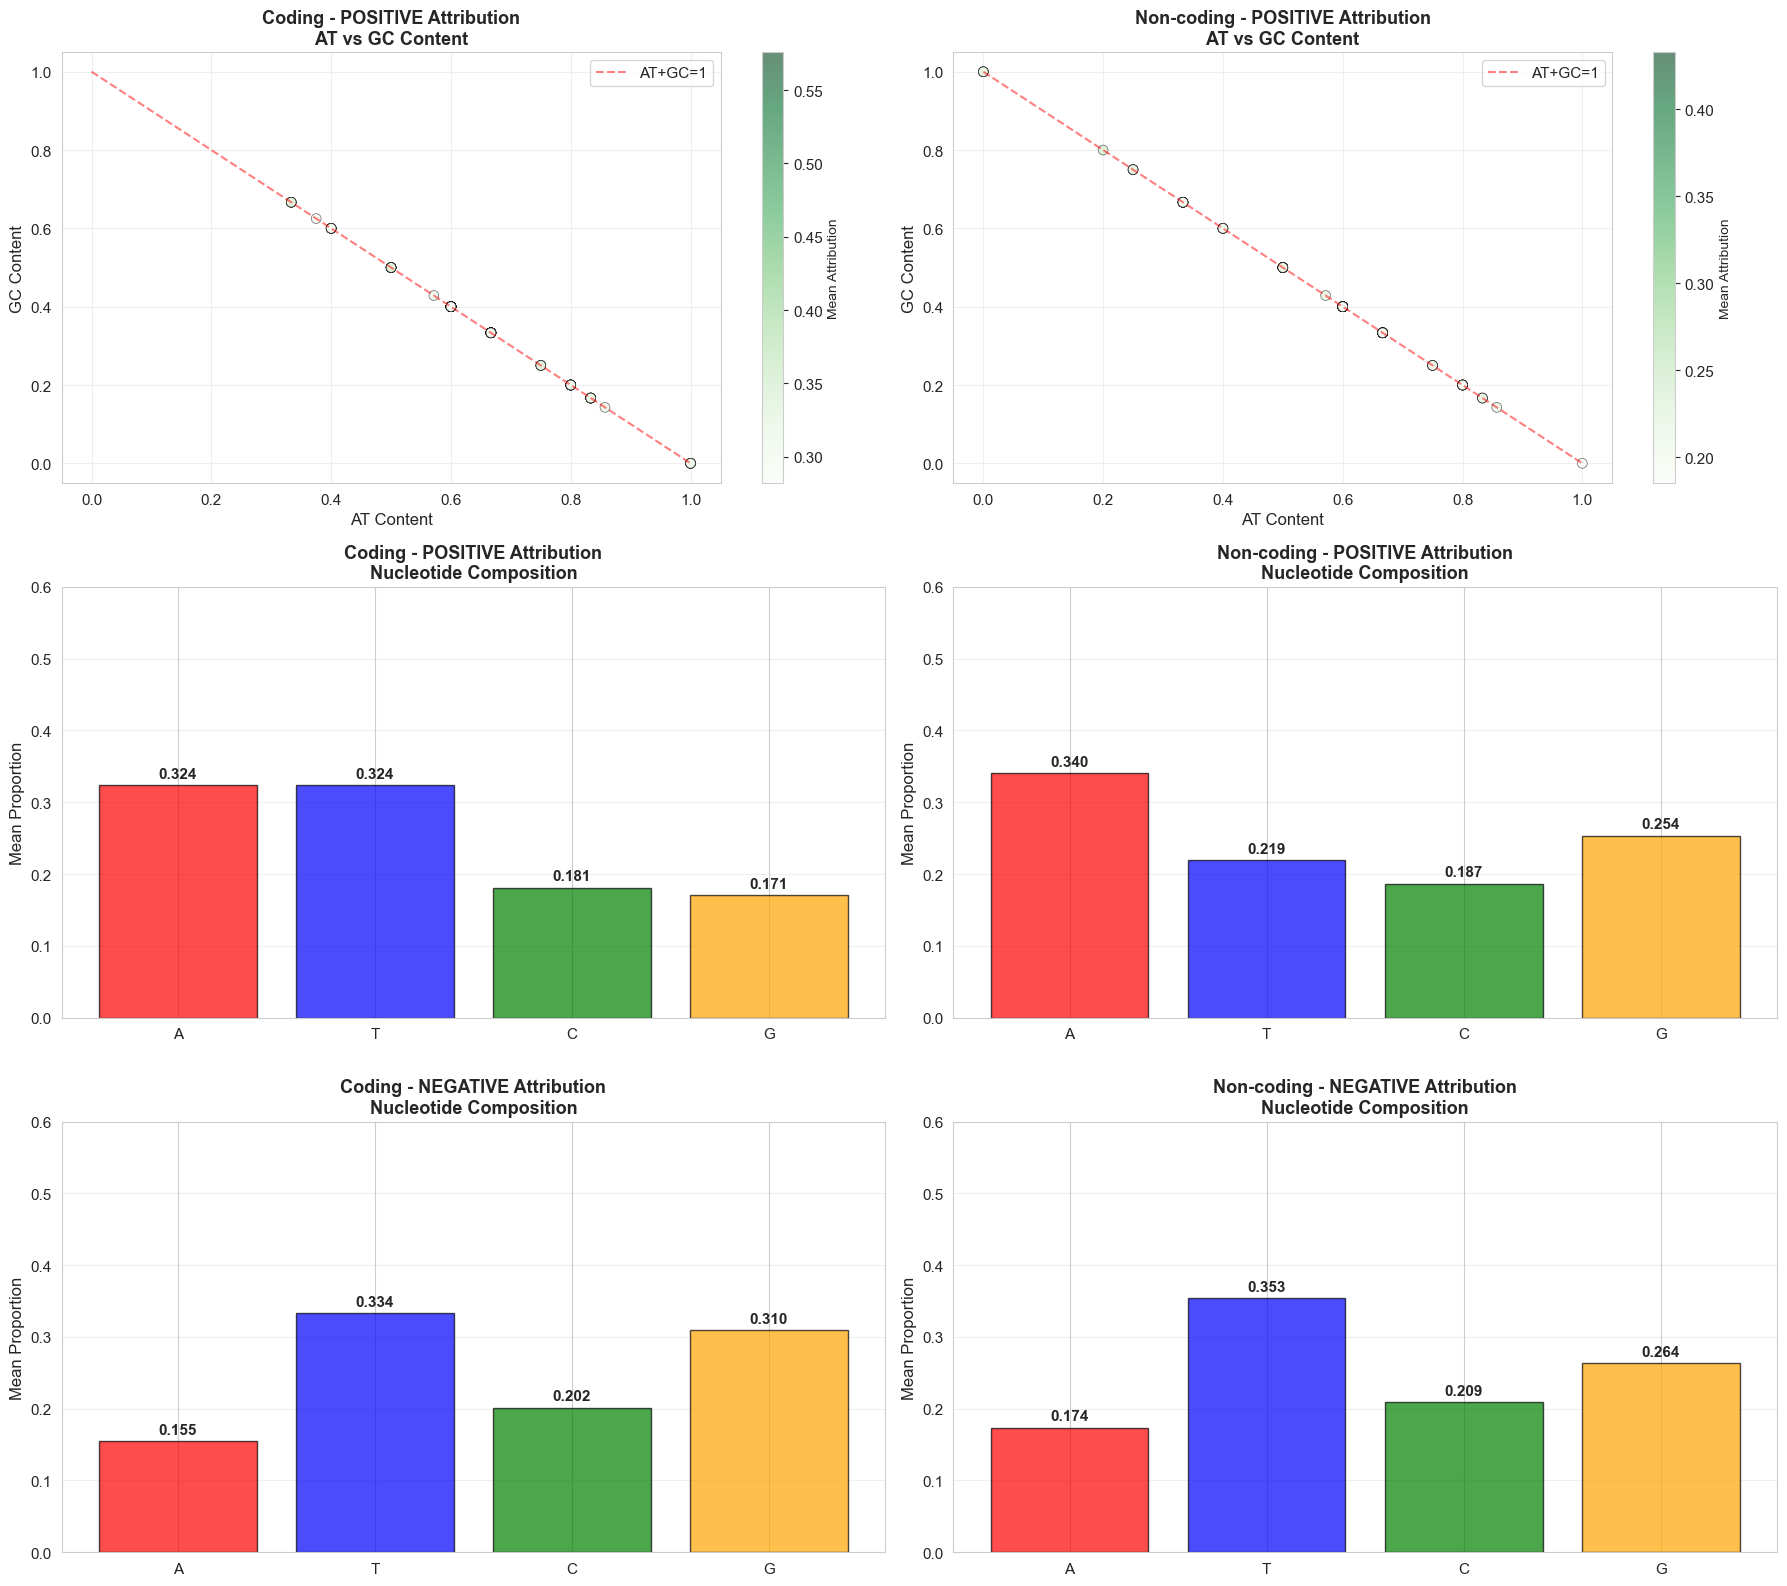

In [16]:
def nucleotide_composition_analysis(df, top_n=100, only_correct=True):
    """
    Comprehensive nucleotide composition analysis for high-attribution tokens
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    def get_nucleotide_composition(token):
        """Calculate A, T, C, G percentages"""
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        token_upper = token.upper()
        total = len(token_upper)
        if total == 0:
            return None
        return {
            'A': token_upper.count('A') / total,
            'T': token_upper.count('T') / total,
            'C': token_upper.count('C') / total,
            'G': token_upper.count('G') / total,
            'AT': (token_upper.count('A') + token_upper.count('T')) / total,
            'GC': (token_upper.count('G') + token_upper.count('C')) / total,
        }
    
    results = {}
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        # Collect token data
        token_positive_attrs = defaultdict(list)
        token_negative_attrs = defaultdict(list)
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    if attr > 0:
                        token_positive_attrs[token].append(attr)
                    else:
                        token_negative_attrs[token].append(attr)
        
        # Get top tokens by mean attribution
        top_positive = sorted([(t, np.mean(a)) for t, a in token_positive_attrs.items()], 
                             key=lambda x: x[1], reverse=True)[:top_n]
        top_negative = sorted([(t, np.mean(np.abs(a))) for t, a in token_negative_attrs.items()],
                             key=lambda x: x[1], reverse=True)[:top_n]
        
        # Calculate nucleotide composition for top tokens
        results[seq_type] = {
            'positive': {'tokens': [], 'A': [], 'T': [], 'C': [], 'G': [], 'AT': [], 'GC': [], 'attr': []},
            'negative': {'tokens': [], 'A': [], 'T': [], 'C': [], 'G': [], 'AT': [], 'GC': [], 'attr': []},
        }
        
        for token, attr in top_positive:
            comp = get_nucleotide_composition(token)
            if comp:
                results[seq_type]['positive']['tokens'].append(token)
                results[seq_type]['positive']['A'].append(comp['A'])
                results[seq_type]['positive']['T'].append(comp['T'])
                results[seq_type]['positive']['C'].append(comp['C'])
                results[seq_type]['positive']['G'].append(comp['G'])
                results[seq_type]['positive']['AT'].append(comp['AT'])
                results[seq_type]['positive']['GC'].append(comp['GC'])
                results[seq_type]['positive']['attr'].append(attr)
        
        for token, attr in top_negative:
            comp = get_nucleotide_composition(token)
            if comp:
                results[seq_type]['negative']['tokens'].append(token)
                results[seq_type]['negative']['A'].append(comp['A'])
                results[seq_type]['negative']['T'].append(comp['T'])
                results[seq_type]['negative']['C'].append(comp['C'])
                results[seq_type]['negative']['G'].append(comp['G'])
                results[seq_type]['negative']['AT'].append(comp['AT'])
                results[seq_type]['negative']['GC'].append(comp['GC'])
                results[seq_type]['negative']['attr'].append(attr)
    
    # Visualization
    fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        # 1. AT vs GC content for positive attributions
        pos_data = results[seq_type]['positive']
        axes[0, col_idx].scatter(pos_data['AT'], pos_data['GC'], 
                                c=pos_data['attr'], s=50, alpha=0.6,
                                cmap='Greens', edgecolors='black', linewidth=0.5)
        axes[0, col_idx].plot([0, 1], [1, 0], 'r--', alpha=0.5, label='AT+GC=1')
        axes[0, col_idx].set_xlabel('AT Content', fontsize=12)
        axes[0, col_idx].set_ylabel('GC Content', fontsize=12)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution\nAT vs GC Content',
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].legend()
        axes[0, col_idx].grid(True, alpha=0.3)
        cbar = plt.colorbar(axes[0, col_idx].collections[0], ax=axes[0, col_idx])
        cbar.set_label('Mean Attribution', fontsize=10)
        
        # 2. Individual nucleotide composition (positive)
        nucleotides = ['A', 'T', 'C', 'G']
        mean_comp = [np.mean(pos_data[nuc]) for nuc in nucleotides]
        axes[1, col_idx].bar(nucleotides, mean_comp, color=['red', 'blue', 'green', 'orange'],
                            alpha=0.7, edgecolor='black')
        axes[1, col_idx].set_ylabel('Mean Proportion', fontsize=12)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution\nNucleotide Composition',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].grid(True, alpha=0.3, axis='y')
        axes[1, col_idx].set_ylim(0, 0.6)
        
        # Add values on bars
        for i, (nuc, val) in enumerate(zip(nucleotides, mean_comp)):
            axes[1, col_idx].text(i, val + 0.01, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
        
        # 3. Individual nucleotide composition (negative)
        neg_data = results[seq_type]['negative']
        mean_comp_neg = [np.mean(neg_data[nuc]) for nuc in nucleotides]
        axes[2, col_idx].bar(nucleotides, mean_comp_neg, color=['red', 'blue', 'green', 'orange'],
                            alpha=0.7, edgecolor='black')
        axes[2, col_idx].set_ylabel('Mean Proportion', fontsize=12)
        axes[2, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attribution\nNucleotide Composition',
                                   fontsize=13, fontweight='bold')
        axes[2, col_idx].grid(True, alpha=0.3, axis='y')
        axes[2, col_idx].set_ylim(0, 0.6)
        
        # Add values on bars
        for i, (nuc, val) in enumerate(zip(nucleotides, mean_comp_neg)):
            axes[2, col_idx].text(i, val + 0.01, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
        
        # Print statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Nucleotide Composition of Top {top_n} Tokens")
        print(f"{'='*70}")
        
        print(f"\n  POSITIVE Attribution Tokens:")
        print(f"    Mean A: {np.mean(pos_data['A']):.3f} ± {np.std(pos_data['A']):.3f}")
        print(f"    Mean T: {np.mean(pos_data['T']):.3f} ± {np.std(pos_data['T']):.3f}")
        print(f"    Mean C: {np.mean(pos_data['C']):.3f} ± {np.std(pos_data['C']):.3f}")
        print(f"    Mean G: {np.mean(pos_data['G']):.3f} ± {np.std(pos_data['G']):.3f}")
        print(f"    Mean AT: {np.mean(pos_data['AT']):.3f} ± {np.std(pos_data['AT']):.3f}")
        print(f"    Mean GC: {np.mean(pos_data['GC']):.3f} ± {np.std(pos_data['GC']):.3f}")
        
        print(f"\n  NEGATIVE Attribution Tokens:")
        print(f"    Mean A: {np.mean(neg_data['A']):.3f} ± {np.std(neg_data['A']):.3f}")
        print(f"    Mean T: {np.mean(neg_data['T']):.3f} ± {np.std(neg_data['T']):.3f}")
        print(f"    Mean C: {np.mean(neg_data['C']):.3f} ± {np.std(neg_data['C']):.3f}")
        print(f"    Mean G: {np.mean(neg_data['G']):.3f} ± {np.std(neg_data['G']):.3f}")
        print(f"    Mean AT: {np.mean(neg_data['AT']):.3f} ± {np.std(neg_data['AT']):.3f}")
        print(f"    Mean GC: {np.mean(neg_data['GC']):.3f} ± {np.std(neg_data['GC']):.3f}")
    
    plt.tight_layout()
    plt.show()
    
    return results

# Run analysis
nuc_results = nucleotide_composition_analysis(df, top_n=100, only_correct=True)

## Advanced Analysis 3: Nucleotide Position-Specific Importance

Check if specific nucleotides at specific positions drive attributions

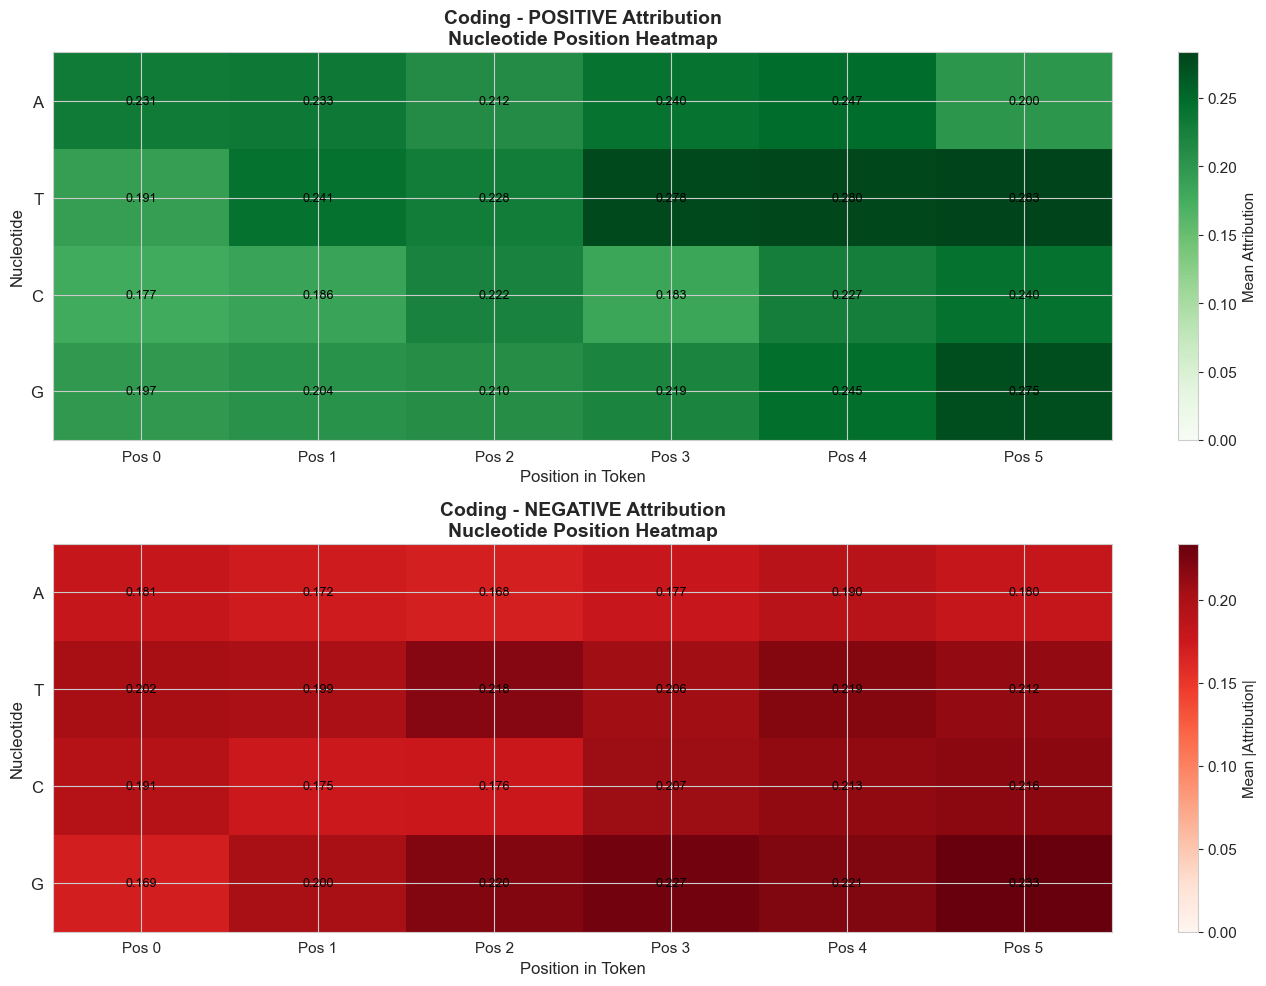


CODING - Position-Specific Nucleotide Importance

  POSITIVE Attribution - Top 10 (Nucleotide, Position, Mean Attr):
     1. T at position 5: 0.2833 (n=716)
     2. T at position 4: 0.2797 (n=7589)
     3. T at position 3: 0.2779 (n=34379)
     4. G at position 5: 0.2751 (n=7380)
     5. A at position 4: 0.2473 (n=8042)
     6. G at position 4: 0.2450 (n=29375)
     7. T at position 1: 0.2413 (n=72530)
     8. C at position 5: 0.2402 (n=18054)
     9. A at position 3: 0.2402 (n=36129)
    10. A at position 1: 0.2326 (n=67107)

  NEGATIVE Attribution - Top 10 (Nucleotide, Position, Mean |Attr|):
     1. G at position 5: 0.2335 (n=4405)
     2. G at position 3: 0.2274 (n=50567)
     3. G at position 4: 0.2214 (n=20289)
     4. G at position 2: 0.2202 (n=70407)
     5. T at position 4: 0.2192 (n=4102)
     6. T at position 2: 0.2182 (n=32084)
     7. C at position 5: 0.2159 (n=13761)
     8. C at position 4: 0.2129 (n=37780)
     9. T at position 5: 0.2118 (n=306)
    10. C at position 3

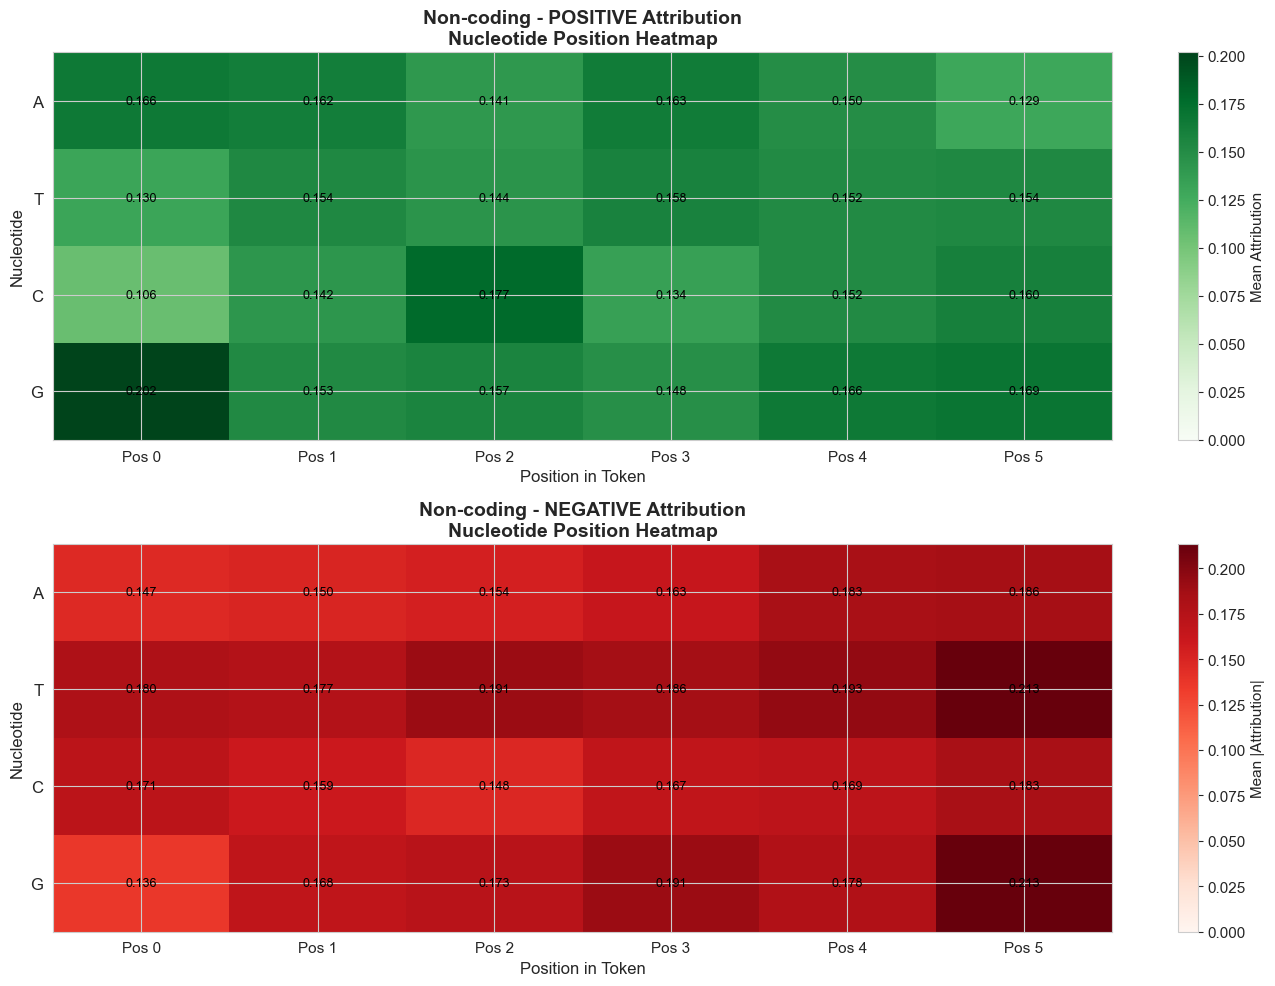


NON-CODING - Position-Specific Nucleotide Importance

  POSITIVE Attribution - Top 10 (Nucleotide, Position, Mean Attr):
     1. G at position 0: 0.2020 (n=14611)
     2. C at position 2: 0.1774 (n=67801)
     3. G at position 5: 0.1692 (n=4843)
     4. G at position 4: 0.1661 (n=21169)
     5. A at position 0: 0.1660 (n=155751)
     6. A at position 3: 0.1634 (n=36437)
     7. A at position 1: 0.1619 (n=73721)
     8. C at position 5: 0.1598 (n=11262)
     9. T at position 3: 0.1583 (n=33348)
    10. G at position 2: 0.1566 (n=56466)

  NEGATIVE Attribution - Top 10 (Nucleotide, Position, Mean |Attr|):
     1. G at position 5: 0.2134 (n=7114)
     2. T at position 5: 0.2134 (n=2796)
     3. T at position 4: 0.1934 (n=17237)
     4. G at position 3: 0.1908 (n=58014)
     5. T at position 2: 0.1907 (n=78934)
     6. T at position 3: 0.1864 (n=45485)
     7. A at position 5: 0.1858 (n=5336)
     8. A at position 4: 0.1832 (n=15951)
     9. C at position 5: 0.1827 (n=14971)
    10. T at 

In [17]:
def nucleotide_position_analysis(df, max_token_length=6, only_correct=True):
    """
    Analyze which nucleotides at which positions have highest attributions
    Creates heatmaps showing position-specific nucleotide importance
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        # Create matrices: position x nucleotide
        # Separate for positive and negative attributions
        pos_matrix = {nuc: defaultdict(list) for nuc in ['A', 'T', 'C', 'G']}
        neg_matrix = {nuc: defaultdict(list) for nuc in ['A', 'T', 'C', 'G']}
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    continue
                
                token_upper = token.upper()
                if len(token_upper) <= max_token_length:
                    for pos, nucleotide in enumerate(token_upper):
                        if nucleotide in ['A', 'T', 'C', 'G']:
                            if attr > 0:
                                pos_matrix[nucleotide][pos].append(attr)
                            else:
                                neg_matrix[nucleotide][pos].append(abs(attr))
        
        # Create heatmaps
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Positive attributions heatmap
        pos_data = np.zeros((4, max_token_length))
        nucleotides = ['A', 'T', 'C', 'G']
        
        for nuc_idx, nuc in enumerate(nucleotides):
            for pos in range(max_token_length):
                if pos in pos_matrix[nuc] and len(pos_matrix[nuc][pos]) > 0:
                    pos_data[nuc_idx, pos] = np.mean(pos_matrix[nuc][pos])
        
        im1 = axes[0].imshow(pos_data, cmap='Greens', aspect='auto', vmin=0, vmax=np.max(pos_data))
        axes[0].set_yticks(range(4))
        axes[0].set_yticklabels(nucleotides, fontsize=12)
        axes[0].set_xticks(range(max_token_length))
        axes[0].set_xticklabels([f'Pos {i}' for i in range(max_token_length)], fontsize=11)
        axes[0].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution\nNucleotide Position Heatmap',
                         fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Position in Token', fontsize=12)
        axes[0].set_ylabel('Nucleotide', fontsize=12)
        
        # Add values to cells
        for i in range(4):
            for j in range(max_token_length):
                text = axes[0].text(j, i, f'{pos_data[i, j]:.3f}',
                                   ha="center", va="center", color="black", fontsize=9)
        
        cbar1 = plt.colorbar(im1, ax=axes[0])
        cbar1.set_label('Mean Attribution', fontsize=11)
        
        # Negative attributions heatmap
        neg_data = np.zeros((4, max_token_length))
        
        for nuc_idx, nuc in enumerate(nucleotides):
            for pos in range(max_token_length):
                if pos in neg_matrix[nuc] and len(neg_matrix[nuc][pos]) > 0:
                    neg_data[nuc_idx, pos] = np.mean(neg_matrix[nuc][pos])
        
        im2 = axes[1].imshow(neg_data, cmap='Reds', aspect='auto', vmin=0, vmax=np.max(neg_data))
        axes[1].set_yticks(range(4))
        axes[1].set_yticklabels(nucleotides, fontsize=12)
        axes[1].set_xticks(range(max_token_length))
        axes[1].set_xticklabels([f'Pos {i}' for i in range(max_token_length)], fontsize=11)
        axes[1].set_title(f'{seq_type.capitalize()} - NEGATIVE Attribution\nNucleotide Position Heatmap',
                         fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Position in Token', fontsize=12)
        axes[1].set_ylabel('Nucleotide', fontsize=12)
        
        # Add values to cells
        for i in range(4):
            for j in range(max_token_length):
                text = axes[1].text(j, i, f'{neg_data[i, j]:.3f}',
                                   ha="center", va="center", color="black", fontsize=9)
        
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label('Mean |Attribution|', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        # Print key findings
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Position-Specific Nucleotide Importance")
        print(f"{'='*70}")
        
        print(f"\n  POSITIVE Attribution - Top 10 (Nucleotide, Position, Mean Attr):")
        pos_pairs = []
        for nuc in nucleotides:
            for pos in range(max_token_length):
                if pos in pos_matrix[nuc] and len(pos_matrix[nuc][pos]) > 0:
                    pos_pairs.append((nuc, pos, np.mean(pos_matrix[nuc][pos]), len(pos_matrix[nuc][pos])))
        pos_pairs.sort(key=lambda x: x[2], reverse=True)
        for rank, (nuc, pos, mean_attr, count) in enumerate(pos_pairs[:10], 1):
            print(f"    {rank:2d}. {nuc} at position {pos}: {mean_attr:.4f} (n={count})")
        
        print(f"\n  NEGATIVE Attribution - Top 10 (Nucleotide, Position, Mean |Attr|):")
        neg_pairs = []
        for nuc in nucleotides:
            for pos in range(max_token_length):
                if pos in neg_matrix[nuc] and len(neg_matrix[nuc][pos]) > 0:
                    neg_pairs.append((nuc, pos, np.mean(neg_matrix[nuc][pos]), len(neg_matrix[nuc][pos])))
        neg_pairs.sort(key=lambda x: x[2], reverse=True)
        for rank, (nuc, pos, mean_attr, count) in enumerate(neg_pairs[:10], 1):
            print(f"    {rank:2d}. {nuc} at position {pos}: {mean_attr:.4f} (n={count})")

# Run analysis
nucleotide_position_analysis(df, max_token_length=6, only_correct=True)

## Advanced Analysis 4: Discriminative Power Comparison

Direct comparison of coding vs non-coding token signatures


CODING SIGNATURE TOKENS (Top 50)
Rank   Token           Coding +     NonCod -     Disc Power   N(C+)    N(NC-)  
--------------------------------------------------------------------------------
1      AGTT                0.4916      0.2493      0.7409  334      244     
2      ATCTTC              0.5758      0.1196      0.6954  261      12      
3      ATGTTC              0.5310      0.1495      0.6804  112      37      
4      AAAATC              0.5021      0.1752      0.6774  93       41      
5      TCATC               0.4795      0.1921      0.6716  446      26      
6      AACAAC              0.5140      0.1514      0.6654  228      13      
7      AACATC              0.5709      0.0890      0.6599  148      9       
8      TCCTCC              0.4738      0.1837      0.6575  376      38      
9      TCAAC               0.4273      0.2014      0.6287  320      23      
10     ATCTGC              0.4789      0.1396      0.6186  233      13      
11     AATAG               0.4483  

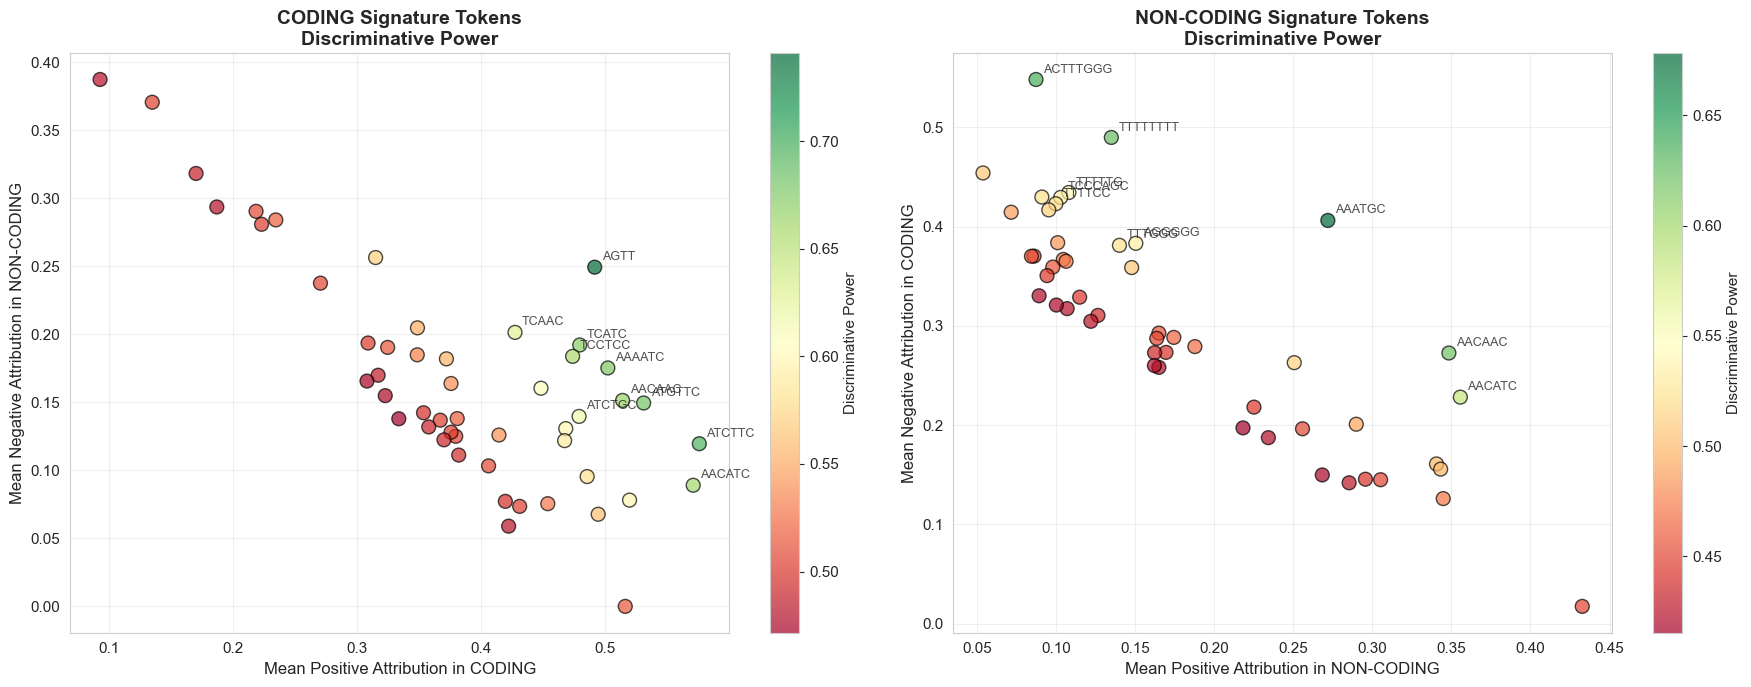

In [18]:
def compare_coding_noncoding_signatures(df, top_n=50, only_correct=True):
    """
    Find tokens that are uniquely discriminative for coding vs non-coding
    Shows which tokens are "signature" features for each class
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    # Collect token attributions for each sequence type
    coding_tokens = defaultdict(list)
    noncoding_tokens = defaultdict(list)
    
    for _, row in df.iterrows():
        tokens = row['tokens'].split('|')
        attrs = [float(x) for x in row['attributions'].split('|')]
        seq_type = row['sequence_type']
        
        for token, attr in zip(tokens, attrs):
            if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                if seq_type == 'coding':
                    coding_tokens[token].append(attr)
                else:
                    noncoding_tokens[token].append(attr)
    
    # Calculate "discriminative power" - mean positive attribution in own class vs other class
    coding_signatures = []
    noncoding_signatures = []
    
    for token in coding_tokens.keys():
        # Positive attributions in coding (support coding)
        coding_pos = [a for a in coding_tokens[token] if a > 0]
        # Negative attributions in non-coding (oppose non-coding = support coding)
        noncoding_neg = [abs(a) for a in noncoding_tokens.get(token, []) if a < 0]
        
        if len(coding_pos) >= 5:  # Minimum occurrences
            coding_score = np.mean(coding_pos)
            noncoding_opposition = np.mean(noncoding_neg) if len(noncoding_neg) > 0 else 0
            # Discriminative power = strong positive in coding + strong negative in non-coding
            disc_power = coding_score + noncoding_opposition
            coding_signatures.append((token, coding_score, noncoding_opposition, disc_power, 
                                     len(coding_pos), len(noncoding_neg)))
    
    for token in noncoding_tokens.keys():
        # Positive attributions in non-coding (support non-coding)
        noncoding_pos = [a for a in noncoding_tokens[token] if a > 0]
        # Negative attributions in coding (oppose coding = support non-coding)
        coding_neg = [abs(a) for a in coding_tokens.get(token, []) if a < 0]
        
        if len(noncoding_pos) >= 5:  # Minimum occurrences
            noncoding_score = np.mean(noncoding_pos)
            coding_opposition = np.mean(coding_neg) if len(coding_neg) > 0 else 0
            # Discriminative power = strong positive in non-coding + strong negative in coding
            disc_power = noncoding_score + coding_opposition
            noncoding_signatures.append((token, noncoding_score, coding_opposition, disc_power,
                                        len(noncoding_pos), len(coding_neg)))
    
    # Sort by discriminative power
    coding_signatures.sort(key=lambda x: x[3], reverse=True)
    noncoding_signatures.sort(key=lambda x: x[3], reverse=True)
    
    print(f"\n{'='*80}")
    print(f"CODING SIGNATURE TOKENS (Top {top_n})")
    print(f"{'='*80}")
    print(f"{'Rank':<6} {'Token':<15} {'Coding +':<12} {'NonCod -':<12} {'Disc Power':<12} {'N(C+)':<8} {'N(NC-)':<8}")
    print("-" * 80)
    for rank, (token, cod_score, nc_opp, disc, n_cod, n_nc) in enumerate(coding_signatures[:top_n], 1):
        print(f"{rank:<6} {token:<15} {cod_score:>10.4f}  {nc_opp:>10.4f}  {disc:>10.4f}  {n_cod:<8} {n_nc:<8}")
    
    print(f"\n{'='*80}")
    print(f"NON-CODING SIGNATURE TOKENS (Top {top_n})")
    print(f"{'='*80}")
    print(f"{'Rank':<6} {'Token':<15} {'NonCod +':<12} {'Coding -':<12} {'Disc Power':<12} {'N(NC+)':<8} {'N(C-)':<8}")
    print("-" * 80)
    for rank, (token, nc_score, cod_opp, disc, n_nc, n_cod) in enumerate(noncoding_signatures[:top_n], 1):
        print(f"{rank:<6} {token:<15} {nc_score:>10.4f}  {cod_opp:>10.4f}  {disc:>10.4f}  {n_nc:<8} {n_cod:<8}")
    
    # Visualization - Scatter plot of discriminative power
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Coding signatures
    cod_x = [x[1] for x in coding_signatures[:top_n]]  # Coding positive score
    cod_y = [x[2] for x in coding_signatures[:top_n]]  # Non-coding negative score
    cod_colors = [x[3] for x in coding_signatures[:top_n]]  # Discriminative power
    cod_tokens = [x[0] for x in coding_signatures[:top_n]]
    
    scatter1 = axes[0].scatter(cod_x, cod_y, c=cod_colors, s=100, alpha=0.7,
                              cmap='RdYlGn', edgecolors='black', linewidth=1)
    axes[0].set_xlabel('Mean Positive Attribution in CODING', fontsize=12)
    axes[0].set_ylabel('Mean Negative Attribution in NON-CODING', fontsize=12)
    axes[0].set_title('CODING Signature Tokens\nDiscriminative Power', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Annotate top 10
    for i in range(min(10, len(cod_tokens))):
        axes[0].annotate(cod_tokens[i], (cod_x[i], cod_y[i]),
                        fontsize=9, alpha=0.8, xytext=(5, 5), textcoords='offset points')
    
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Discriminative Power', fontsize=11)
    
    # Non-coding signatures
    nc_x = [x[1] for x in noncoding_signatures[:top_n]]  # Non-coding positive score
    nc_y = [x[2] for x in noncoding_signatures[:top_n]]  # Coding negative score
    nc_colors = [x[3] for x in noncoding_signatures[:top_n]]  # Discriminative power
    nc_tokens = [x[0] for x in noncoding_signatures[:top_n]]
    
    scatter2 = axes[1].scatter(nc_x, nc_y, c=nc_colors, s=100, alpha=0.7,
                              cmap='RdYlGn', edgecolors='black', linewidth=1)
    axes[1].set_xlabel('Mean Positive Attribution in NON-CODING', fontsize=12)
    axes[1].set_ylabel('Mean Negative Attribution in CODING', fontsize=12)
    axes[1].set_title('NON-CODING Signature Tokens\nDiscriminative Power', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Annotate top 10
    for i in range(min(10, len(nc_tokens))):
        axes[1].annotate(nc_tokens[i], (nc_x[i], nc_y[i]),
                        fontsize=9, alpha=0.8, xytext=(5, 5), textcoords='offset points')
    
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label('Discriminative Power', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'coding_signatures': coding_signatures[:top_n],
        'noncoding_signatures': noncoding_signatures[:top_n]
    }

# Run analysis
signatures = compare_coding_noncoding_signatures(df, top_n=50, only_correct=True)

## Advanced Analysis 5: Attribution Consistency

How stable are token attributions across different sequences?


CODING - Attribution Consistency Analysis

  MOST CONSISTENT Positive Attribution Tokens (high mean, low std):
  Rank   Token           Mean         Std          Mean/Std     N       
  --------------------------------------------------------------------
  1      ATCG                0.5158      0.1840        2.80  1333    
  2      ATCTGC              0.4765      0.1917        2.49  234     
  3      AACTG               0.4929      0.2046        2.41  347     
  4      AGATC               0.5189      0.2187        2.37  750     
  5      ACTTG               0.4108      0.1798        2.28  101     
  6      AATTG               0.4523      0.2027        2.23  207     
  7      AGTTC               0.3736      0.1713        2.18  710     
  8      AGTTG               0.3297      0.1532        2.15  301     
  9      TGGTC               0.4205      0.1993        2.11  614     
  10     TCAAC               0.4156      0.1971        2.11  328     
  11     AACAAC              0.5038      0.2

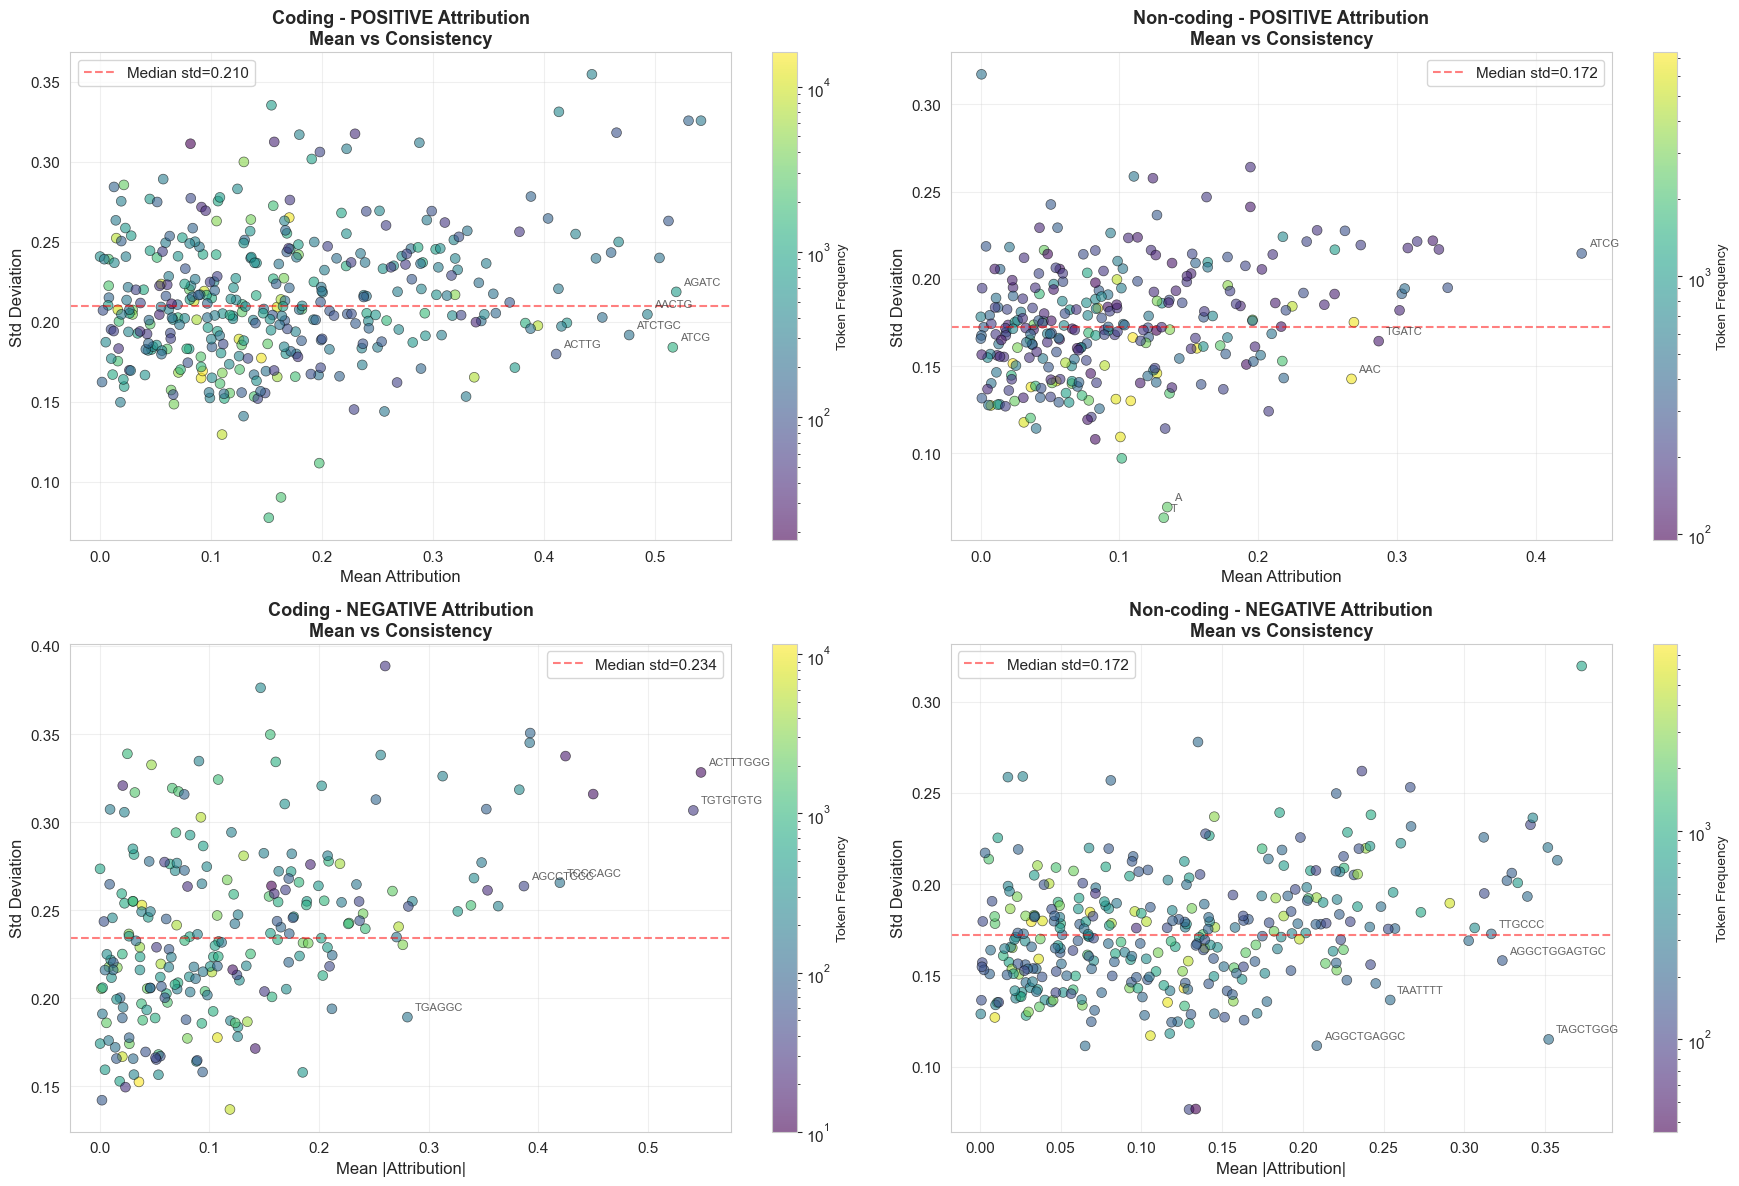

In [19]:
def analyze_attribution_consistency(df, min_occurrences=10, only_correct=True):
    """
    Analyze how consistent token attributions are across different sequences
    Low variance = reliable feature, High variance = context-dependent
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        token_attrs = defaultdict(list)
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    token_attrs[token].append(attr)
        
        # Calculate mean and std for each token
        token_stats = []
        for token, attrs in token_attrs.items():
            if len(attrs) >= min_occurrences:
                mean_attr = np.mean(attrs)
                std_attr = np.std(attrs)
                cv = std_attr / abs(mean_attr) if mean_attr != 0 else float('inf')  # Coefficient of variation
                token_stats.append((token, mean_attr, std_attr, cv, len(attrs)))
        
        # Separate positive and negative
        positive_stats = [(t, m, s, cv, n) for t, m, s, cv, n in token_stats if m > 0]
        negative_stats = [(t, abs(m), s, cv, n) for t, m, s, cv, n in token_stats if m < 0]
        
        # Plot 1: Mean vs Std (Positive)
        if positive_stats:
            means = [x[1] for x in positive_stats]
            stds = [x[2] for x in positive_stats]
            counts = [x[4] for x in positive_stats]
            
            scatter1 = axes[0, col_idx].scatter(means, stds, c=counts, s=50, alpha=0.6,
                                               cmap='viridis', edgecolors='black', linewidth=0.5,
                                               norm=plt.matplotlib.colors.LogNorm())
            axes[0, col_idx].set_xlabel('Mean Attribution', fontsize=12)
            axes[0, col_idx].set_ylabel('Std Deviation', fontsize=12)
            axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution\nMean vs Consistency',
                                      fontsize=13, fontweight='bold')
            axes[0, col_idx].grid(True, alpha=0.3)
            
            # Add reference lines
            axes[0, col_idx].axhline(y=np.median(stds), color='r', linestyle='--', 
                                    alpha=0.5, label=f'Median std={np.median(stds):.3f}')
            axes[0, col_idx].legend()
            
            cbar1 = plt.colorbar(scatter1, ax=axes[0, col_idx])
            cbar1.set_label('Token Frequency', fontsize=10)
            
            # Annotate most consistent high-attribution tokens (low std, high mean)
            consistency_score = [(t, m, s, m/s) for t, m, s, cv, n in positive_stats if s > 0]
            consistency_score.sort(key=lambda x: x[3], reverse=True)
            for token, mean, std, score in consistency_score[:5]:
                axes[0, col_idx].annotate(token, (mean, std), fontsize=8, alpha=0.7,
                                         xytext=(5, 5), textcoords='offset points')
        
        # Plot 2: Mean vs Std (Negative)
        if negative_stats:
            means = [x[1] for x in negative_stats]
            stds = [x[2] for x in negative_stats]
            counts = [x[4] for x in negative_stats]
            
            scatter2 = axes[1, col_idx].scatter(means, stds, c=counts, s=50, alpha=0.6,
                                               cmap='viridis', edgecolors='black', linewidth=0.5,
                                               norm=plt.matplotlib.colors.LogNorm())
            axes[1, col_idx].set_xlabel('Mean |Attribution|', fontsize=12)
            axes[1, col_idx].set_ylabel('Std Deviation', fontsize=12)
            axes[1, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attribution\nMean vs Consistency',
                                      fontsize=13, fontweight='bold')
            axes[1, col_idx].grid(True, alpha=0.3)
            
            # Add reference lines
            axes[1, col_idx].axhline(y=np.median(stds), color='r', linestyle='--',
                                    alpha=0.5, label=f'Median std={np.median(stds):.3f}')
            axes[1, col_idx].legend()
            
            cbar2 = plt.colorbar(scatter2, ax=axes[1, col_idx])
            cbar2.set_label('Token Frequency', fontsize=10)
            
            # Annotate most consistent high-attribution tokens
            consistency_score = [(t, m, s, m/s) for t, m, s, cv, n in negative_stats if s > 0]
            consistency_score.sort(key=lambda x: x[3], reverse=True)
            for token, mean, std, score in consistency_score[:5]:
                axes[1, col_idx].annotate(token, (mean, std), fontsize=8, alpha=0.7,
                                         xytext=(5, 5), textcoords='offset points')
        
        # Print statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Attribution Consistency Analysis")
        print(f"{'='*70}")
        
        print(f"\n  MOST CONSISTENT Positive Attribution Tokens (high mean, low std):")
        if positive_stats:
            consistent_pos = [(t, m, s, m/s if s > 0 else 0, n) for t, m, s, cv, n in positive_stats]
            consistent_pos = [x for x in consistent_pos if x[2] > 0]  # Filter out zero std
            consistent_pos.sort(key=lambda x: x[3], reverse=True)  # Sort by mean/std ratio
            print(f"  {'Rank':<6} {'Token':<15} {'Mean':<12} {'Std':<12} {'Mean/Std':<12} {'N':<8}")
            print("  " + "-" * 68)
            for rank, (token, mean, std, ratio, n) in enumerate(consistent_pos[:15], 1):
                print(f"  {rank:<6} {token:<15} {mean:>10.4f}  {std:>10.4f}  {ratio:>10.2f}  {n:<8}")
        
        print(f"\n  MOST CONSISTENT Negative Attribution Tokens (high mean, low std):")
        if negative_stats:
            consistent_neg = [(t, m, s, m/s if s > 0 else 0, n) for t, m, s, cv, n in negative_stats]
            consistent_neg = [x for x in consistent_neg if x[2] > 0]  # Filter out zero std
            consistent_neg.sort(key=lambda x: x[3], reverse=True)  # Sort by mean/std ratio
            print(f"  {'Rank':<6} {'Token':<15} {'Mean':<12} {'Std':<12} {'Mean/Std':<12} {'N':<8}")
            print("  " + "-" * 68)
            for rank, (token, mean, std, ratio, n) in enumerate(consistent_neg[:15], 1):
                print(f"  {rank:<6} {token:<15} {mean:>10.4f}  {std:>10.4f}  {ratio:>10.2f}  {n:<8}")
        
        print(f"\n  MOST VARIABLE Tokens (context-dependent, high coefficient of variation):")
        variable_tokens = [x for x in token_stats if x[3] != float('inf')]
        variable_tokens.sort(key=lambda x: x[3], reverse=True)
        print(f"  {'Rank':<6} {'Token':<15} {'Mean':<12} {'Std':<12} {'CV':<12} {'N':<8}")
        print("  " + "-" * 68)
        for rank, (token, mean, std, cv, n) in enumerate(variable_tokens[:15], 1):
            print(f"  {rank:<6} {token:<15} {mean:>10.4f}  {std:>10.4f}  {cv:>10.2f}  {n:<8}")
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_attribution_consistency(df, min_occurrences=10, only_correct=True)

## Advanced Analysis 6: Token Length Distribution

Examine if token length correlates with attribution strength


CODING - Token Length vs Attribution
  POSITIVE: Correlation = 0.0912
    Token length weakly affects attribution
  NEGATIVE: Correlation = 0.1602
    Token length weakly affects attribution

  Median attribution by token length (POSITIVE):
    Length 1: 0.1756 (n=17222)
    Length 2: 0.1404 (n=42504)
    Length 3: 0.1773 (n=109966)
    Length 4: 0.1608 (n=95534)
    Length 5: 0.1947 (n=68255)
    Length 6: 0.2029 (n=27641)
    Length 7: 0.1600 (n=874)
    Length 8: 0.0853 (n=33)
    Length 9: 0.0388 (n=2)
    Length 10: 0.1240 (n=4)

  Median attribution by token length (NEGATIVE):
    Length 1: 0.0710 (n=2792)
    Length 2: 0.1068 (n=26874)
    Length 3: 0.1148 (n=52154)
    Length 4: 0.1583 (n=83827)
    Length 5: 0.1606 (n=47206)
    Length 6: 0.1635 (n=19672)
    Length 7: 0.2011 (n=1144)
    Length 8: 0.3410 (n=197)
    Length 9: 0.2797 (n=4)
    Length 10: 0.3823 (n=6)

NON-CODING - Token Length vs Attribution
  POSITIVE: Correlation = -0.0245
    Token length weakly affects at

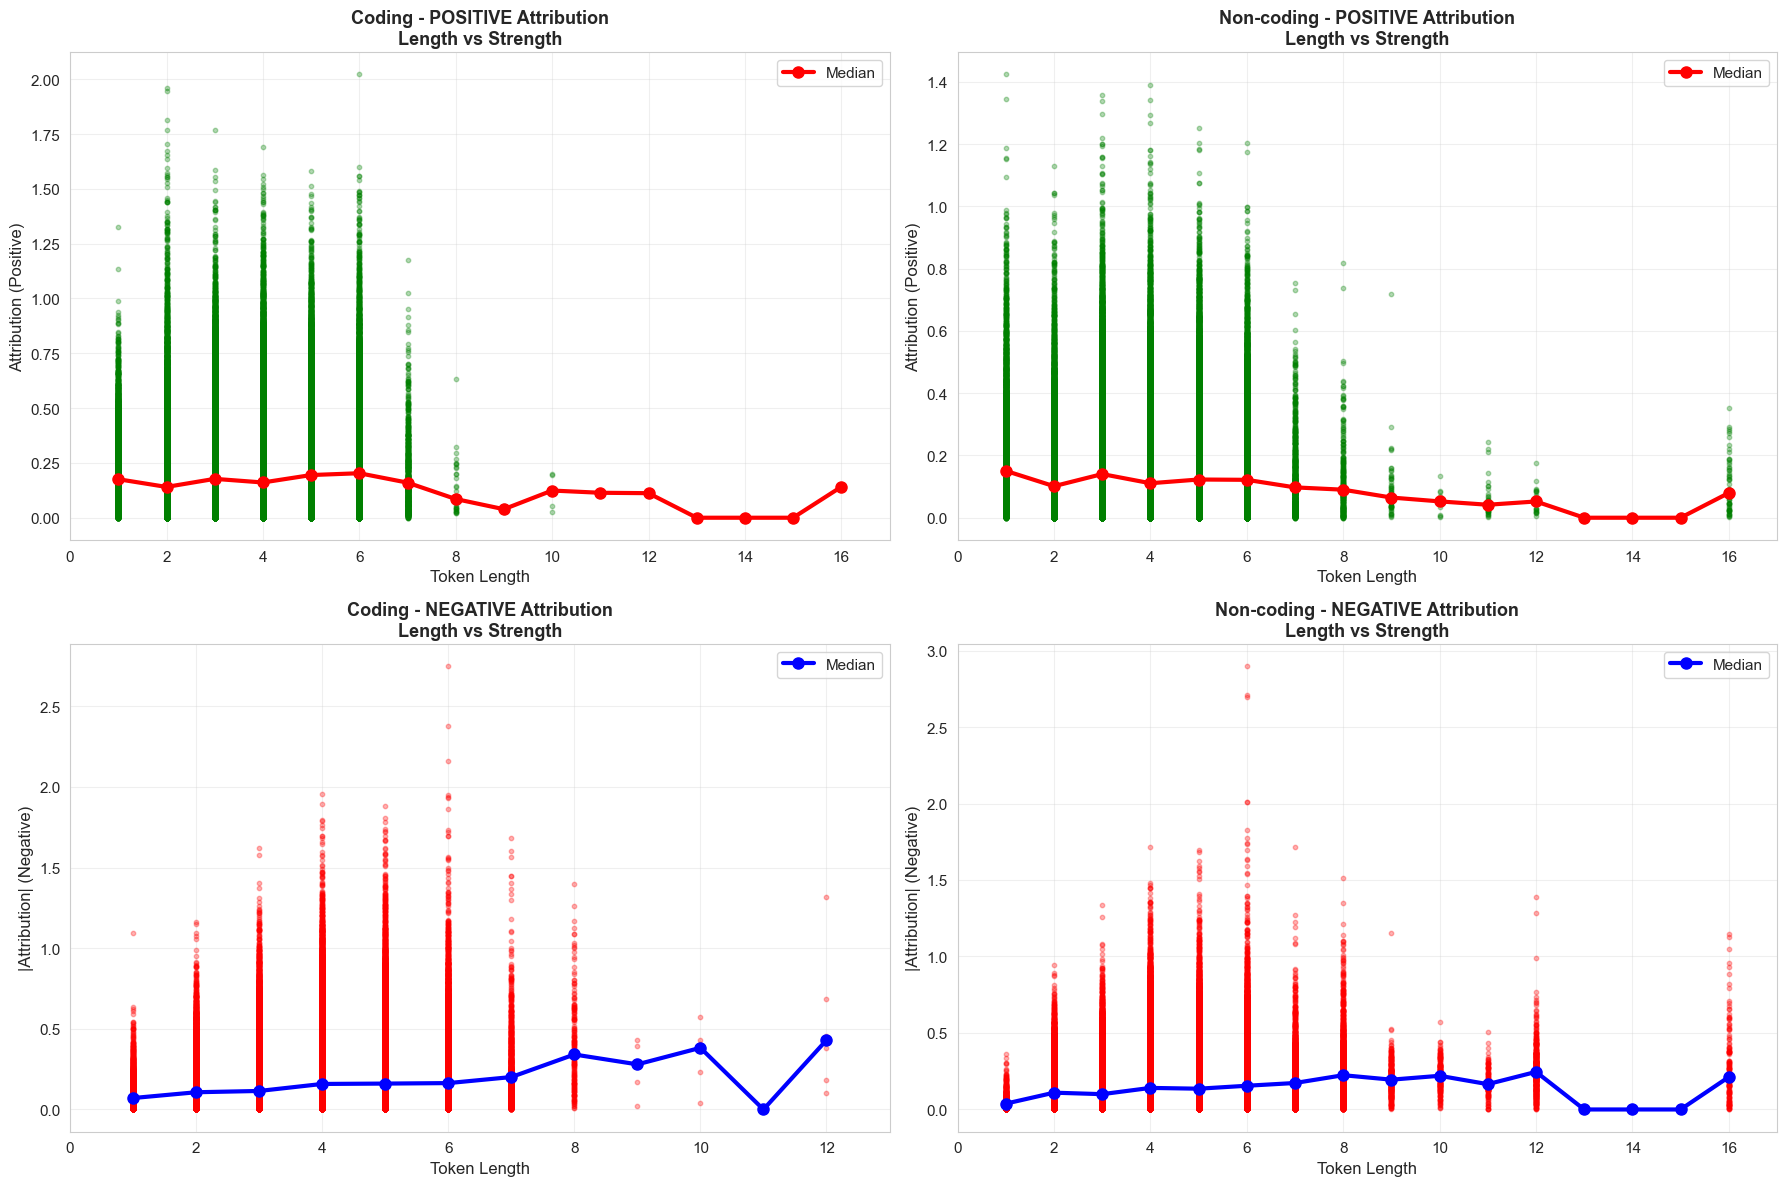

In [20]:
def token_length_attribution_scatter(df, only_correct=True):
    """
    Scatterplot: token length vs attribution strength
    Shows if longer or shorter tokens have more influence
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        # Collect data
        lengths_pos, attrs_pos, tokens_pos = [], [], []
        lengths_neg, attrs_neg, tokens_neg = [], [], []
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    if attr > 0:
                        lengths_pos.append(len(token))
                        attrs_pos.append(attr)
                        tokens_pos.append(token)
                    else:
                        lengths_neg.append(len(token))
                        attrs_neg.append(abs(attr))
                        tokens_neg.append(token)
        
        # Positive attributions scatter
        axes[0, col_idx].scatter(lengths_pos, attrs_pos, alpha=0.3, s=10, c='green')
        
        # Add boxplot overlay
        length_bins = list(range(1, max(lengths_pos) + 1))
        binned_attrs = [[] for _ in length_bins]
        for l, a in zip(lengths_pos, attrs_pos):
            if l <= len(length_bins):
                binned_attrs[l-1].append(a)
        
        # Plot medians and quartiles
        medians = [np.median(attrs) if attrs else 0 for attrs in binned_attrs]
        axes[0, col_idx].plot(length_bins, medians, 'r-', linewidth=3, label='Median', marker='o', markersize=8)
        
        axes[0, col_idx].set_xlabel('Token Length', fontsize=12)
        axes[0, col_idx].set_ylabel('Attribution (Positive)', fontsize=12)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution\nLength vs Strength',
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].legend()
        axes[0, col_idx].grid(True, alpha=0.3)
        axes[0, col_idx].set_xlim(0, min(20, max(lengths_pos) + 1))
        
        # Negative attributions scatter
        axes[1, col_idx].scatter(lengths_neg, attrs_neg, alpha=0.3, s=10, c='red')
        
        # Add boxplot overlay
        length_bins_neg = list(range(1, max(lengths_neg) + 1))
        binned_attrs_neg = [[] for _ in length_bins_neg]
        for l, a in zip(lengths_neg, attrs_neg):
            if l <= len(length_bins_neg):
                binned_attrs_neg[l-1].append(a)
        
        # Plot medians
        medians_neg = [np.median(attrs) if attrs else 0 for attrs in binned_attrs_neg]
        axes[1, col_idx].plot(length_bins_neg, medians_neg, 'b-', linewidth=3, label='Median', marker='o', markersize=8)
        
        axes[1, col_idx].set_xlabel('Token Length', fontsize=12)
        axes[1, col_idx].set_ylabel('|Attribution| (Negative)', fontsize=12)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attribution\nLength vs Strength',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].legend()
        axes[1, col_idx].grid(True, alpha=0.3)
        axes[1, col_idx].set_xlim(0, min(20, max(lengths_neg) + 1))
        
        # Print correlations
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Token Length vs Attribution")
        print(f"{'='*70}")
        
        if len(lengths_pos) > 1:
            corr_pos = np.corrcoef(lengths_pos, attrs_pos)[0, 1]
            print(f"  POSITIVE: Correlation = {corr_pos:.4f}")
            print(f"    {'Longer tokens have stronger attributions' if corr_pos > 0.2 else 'Shorter tokens have stronger attributions' if corr_pos < -0.2 else 'Token length weakly affects attribution'}")
        
        if len(lengths_neg) > 1:
            corr_neg = np.corrcoef(lengths_neg, attrs_neg)[0, 1]
            print(f"  NEGATIVE: Correlation = {corr_neg:.4f}")
            print(f"    {'Longer tokens have stronger attributions' if corr_neg > 0.2 else 'Shorter tokens have stronger attributions' if corr_neg < -0.2 else 'Token length weakly affects attribution'}")
        
        # Length-wise statistics
        print(f"\n  Median attribution by token length (POSITIVE):")
        for length, median_attr in enumerate(medians[:10], 1):
            count = len(binned_attrs[length-1])
            if count > 0:
                print(f"    Length {length}: {median_attr:.4f} (n={count})")
        
        print(f"\n  Median attribution by token length (NEGATIVE):")
        for length, median_attr in enumerate(medians_neg[:10], 1):
            count = len(binned_attrs_neg[length-1])
            if count > 0:
                print(f"    Length {length}: {median_attr:.4f} (n={count})")
    
    plt.tight_layout()
    plt.show()

# Run analysis
token_length_attribution_scatter(df, only_correct=True)

## Advanced Analysis 7: Repeating Patterns Analysis

Identify if repeating sequences (like TGTGTG) have special attribution patterns


CODING - Repeating Pattern Analysis

  Repeating Patterns:
    Mean |attribution|: 0.2287
    Median |attribution|: 0.1788
    Std: 0.1970
    Count: 57672

  Non-repeating Patterns:
    Mean |attribution|: 0.2004
    Median |attribution|: 0.1581
    Std: 0.1709
    Count: 538249

  Mann-Whitney U test:
    p-value: 0.000000
    Significant difference: YES

  Top Repeating Patterns by Mean |Attribution|:
  Rank   Pattern    Mean |Attr|     Count     
  ---------------------------------------------
  1      AAC        0.5109          231       
  2      TCC        0.4350          420       
  3      GT         0.4028          146       
  4      ATC        0.3654          235       
  5      TTC        0.3603          252       
  6      TGC        0.3220          798       
  7      TTG        0.2901          66        
  8      TGG        0.2888          354       
  9      TT         0.2783          4471      
  10     ATG        0.2724          265       
  11     AAG        0.2704

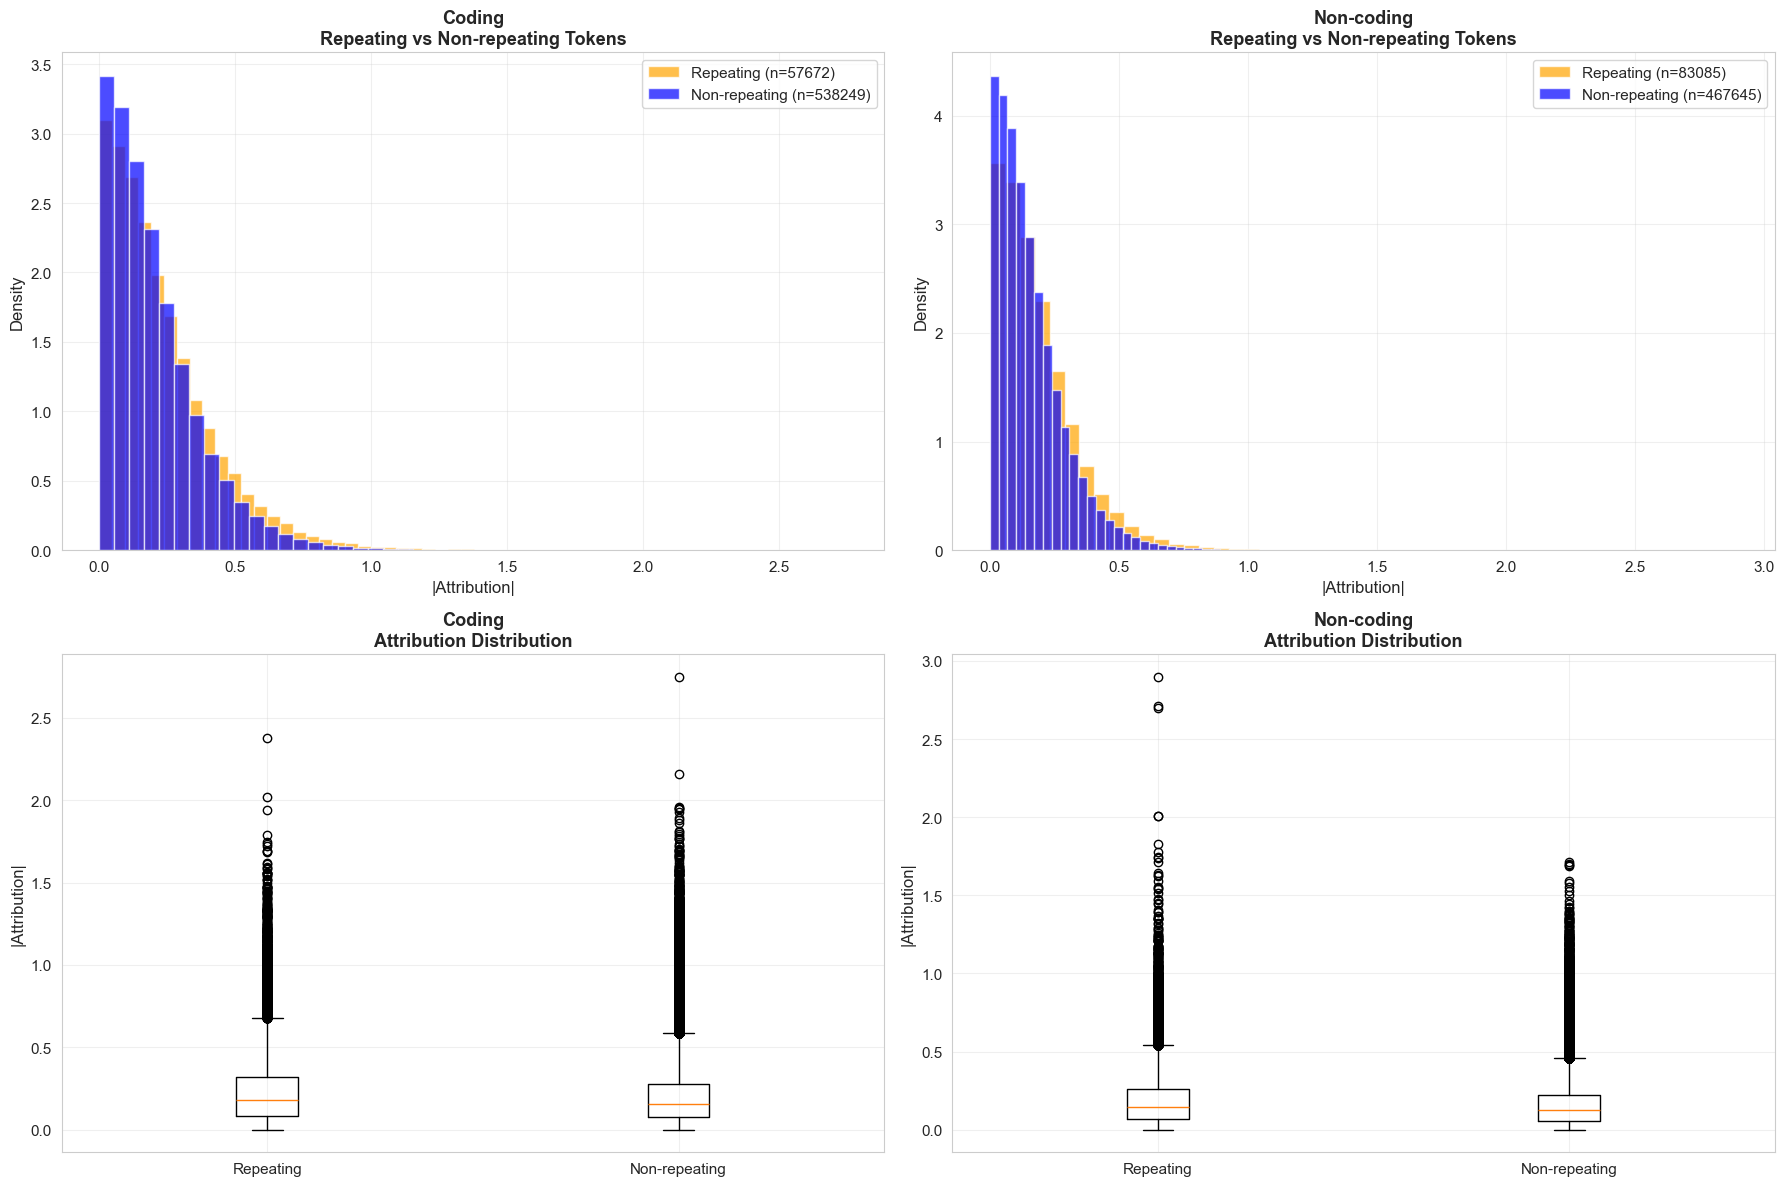

In [21]:
def analyze_repeating_patterns(df, only_correct=True):
    """
    Analyze if tokens with repeating patterns have distinct attribution patterns
    Repeating = dinucleotide repeats (ATATATAT), trinucleotide (TGTGTGTG), etc.
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    def detect_repeat_pattern(token):
        """Detect if token contains repeating pattern"""
        token_upper = token.upper()
        if len(token_upper) < 4:
            return None, 0
        
        # Check for dinucleotide repeats (AT, GC, etc.)
        for di_len in [2, 3, 4]:
            for start in range(len(token_upper) - di_len):
                pattern = token_upper[start:start+di_len]
                # Count how many times pattern repeats consecutively
                repeat_count = 1
                pos = start + di_len
                while pos + di_len <= len(token_upper) and token_upper[pos:pos+di_len] == pattern:
                    repeat_count += 1
                    pos += di_len
                
                if repeat_count >= 2:  # Pattern repeats at least twice
                    return pattern, repeat_count
        
        return None, 0
    
    results = {
        'coding': {'repeat': [], 'non_repeat': []},
        'non-coding': {'repeat': [], 'non_repeat': []}
    }
    
    repeat_details = {
        'coding': defaultdict(list),
        'non-coding': defaultdict(list)
    }
    
    for seq_type in ['coding', 'non-coding']:
        subset = df[df['sequence_type'] == seq_type]
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    continue
                
                pattern, repeat_count = detect_repeat_pattern(token)
                
                if pattern:
                    results[seq_type]['repeat'].append(abs(attr))
                    repeat_details[seq_type][pattern].append(abs(attr))
                else:
                    results[seq_type]['non_repeat'].append(abs(attr))
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        # Histogram comparison
        axes[0, col_idx].hist(results[seq_type]['repeat'], bins=50, alpha=0.7, 
                             label=f'Repeating (n={len(results[seq_type]["repeat"])})',
                             color='orange', density=True)
        axes[0, col_idx].hist(results[seq_type]['non_repeat'], bins=50, alpha=0.7,
                             label=f'Non-repeating (n={len(results[seq_type]["non_repeat"])})',
                             color='blue', density=True)
        axes[0, col_idx].set_xlabel('|Attribution|', fontsize=12)
        axes[0, col_idx].set_ylabel('Density', fontsize=12)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()}\nRepeating vs Non-repeating Tokens',
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].legend()
        axes[0, col_idx].grid(True, alpha=0.3)
        
        # Box plot comparison
        axes[1, col_idx].boxplot([results[seq_type]['repeat'], results[seq_type]['non_repeat']],
                                labels=['Repeating', 'Non-repeating'])
        axes[1, col_idx].set_ylabel('|Attribution|', fontsize=12)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()}\nAttribution Distribution',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].grid(True, alpha=0.3)
        
        # Statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Repeating Pattern Analysis")
        print(f"{'='*70}")
        
        if results[seq_type]['repeat']:
            print(f"\n  Repeating Patterns:")
            print(f"    Mean |attribution|: {np.mean(results[seq_type]['repeat']):.4f}")
            print(f"    Median |attribution|: {np.median(results[seq_type]['repeat']):.4f}")
            print(f"    Std: {np.std(results[seq_type]['repeat']):.4f}")
            print(f"    Count: {len(results[seq_type]['repeat'])}")
        
        if results[seq_type]['non_repeat']:
            print(f"\n  Non-repeating Patterns:")
            print(f"    Mean |attribution|: {np.mean(results[seq_type]['non_repeat']):.4f}")
            print(f"    Median |attribution|: {np.median(results[seq_type]['non_repeat']):.4f}")
            print(f"    Std: {np.std(results[seq_type]['non_repeat']):.4f}")
            print(f"    Count: {len(results[seq_type]['non_repeat'])}")
        
        # Statistical test
        if results[seq_type]['repeat'] and results[seq_type]['non_repeat']:
            from scipy.stats import mannwhitneyu
            stat, pval = mannwhitneyu(results[seq_type]['repeat'], results[seq_type]['non_repeat'])
            print(f"\n  Mann-Whitney U test:")
            print(f"    p-value: {pval:.6f}")
            print(f"    Significant difference: {'YES' if pval < 0.05 else 'NO'}")
        
        # Top repeating patterns
        print(f"\n  Top Repeating Patterns by Mean |Attribution|:")
        pattern_summary = [(pat, np.mean(attrs), len(attrs)) 
                          for pat, attrs in repeat_details[seq_type].items()]
        pattern_summary.sort(key=lambda x: x[1], reverse=True)
        
        print(f"  {'Rank':<6} {'Pattern':<10} {'Mean |Attr|':<15} {'Count':<10}")
        print("  " + "-" * 45)
        for rank, (pattern, mean_attr, count) in enumerate(pattern_summary[:20], 1):
            print(f"  {rank:<6} {pattern:<10} {mean_attr:<15.4f} {count:<10}")
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_repeating_patterns(df, only_correct=True)

---

# 🎯 KEY INSIGHTS & INTERPRETATION GUIDE

## What to Look For in the Results:

### 1. **Attribution vs Frequency (Analysis 1)**
- **High correlation**: Common tokens drive predictions (model relies on frequent patterns)
- **Low/negative correlation**: Model focuses on rare, specific markers
- **Look for**: Outliers (rare tokens with high attribution = novel discriminators)

### 2. **Nucleotide Composition (Analysis 2)**
- Compare A/T/C/G ratios between positive/negative attribution tokens
- **Coding expectation**: Higher GC content (especially in exons)
- **Non-coding expectation**: Higher AT content (regulatory regions often AT-rich)
- **Key question**: Does the model learn this biological signal?

### 3. **Position-Specific Importance (Analysis 3)**
- Heatmaps show which nucleotides at which positions matter most
- **Look for**: Start/end position effects (codon boundaries, motif edges)
- **Interpretation**: Bright cells = model learned position-specific rules

### 4. **Discriminative Power (Analysis 4)**
- **Top-right quadrant**: Strong signature tokens (high in own class, opposed in other)
- These are the **most reliable discriminators** the model learned
- **Compare with biology**: Do they match known motifs or reveal novel patterns?

### 5. **Attribution Consistency (Analysis 5)**
- **Low variance** = reliable, context-independent features
- **High variance** = context-dependent (meaning changes based on neighbors)
- **Best features**: High mean attribution + low variance

### 6. **Token Length Effects (Analysis 6)**
- Shows if model prefers short k-mers (2-3bp) or longer motifs (5-8bp)
- **Positive correlation**: Model relies on longer contextual patterns
- **Negative correlation**: Model uses simple dinucleotides

### 7. **Repeating Patterns (Analysis 7)**
- Repetitive sequences common in non-coding (microsatellites, tandem repeats)
- **Significant difference**: Model learned to use repetition as a feature
- **Check**: Which repeat types (AT, GC, TG) have strongest effects?

## 🔬 Next Steps for Biological Validation:

1. **Extract top signature tokens** from Analysis 4
2. **BLAST/search** them against known motif databases (JASPAR, Transfac)
3. **Cross-reference** with gene annotation (UTRs, introns, promoters)
4. **Validate**: Do high-attribution regions correspond to functional elements?

## 📊 Recommended Plots to Include in Papers:

- Analysis 2: Nucleotide composition bar charts
- Analysis 3: Position-specific heatmaps
- Analysis 4: Discriminative power scatterplots
- Analysis 5: Consistency analysis (mean vs std)

---

---

# 🔍 FOCUSED ANALYSIS: TOP 5% MOST DISCRIMINATIVE TOKENS

## Rationale
Analyzing only the top 5% of tokens by attribution strength allows us to:
- Focus on the most important discriminative features
- Reduce noise from low-attribution tokens
- Identify the "signature" patterns the model relies on most
- Compare if high-attribution tokens have different characteristics than the overall distribution

## Step 1: Filter to Top 5% Tokens

In [22]:
def create_top_5_percent_dataset(df, only_correct=True):
    """
    Create a filtered dataset containing only tokens in the top 5% by absolute attribution
    """
    if only_correct:
        df_filtered = df[df['is_correct'] == True].copy()
    else:
        df_filtered = df.copy()
    
    # Collect all absolute attribution values to find threshold
    all_abs_attrs = []
    
    for _, row in df_filtered.iterrows():
        tokens = row['tokens'].split('|')
        attrs = [float(x) for x in row['attributions'].split('|')]
        
        for token, attr in zip(tokens, attrs):
            if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                all_abs_attrs.append(abs(attr))
    
    # Calculate 95th percentile threshold
    threshold = np.percentile(all_abs_attrs, 95)
    
    print(f"Total tokens analyzed: {len(all_abs_attrs):,}")
    print(f"95th percentile |attribution| threshold: {threshold:.6f}")
    print(f"Tokens above threshold: {sum(1 for a in all_abs_attrs if a >= threshold):,} ({100 * sum(1 for a in all_abs_attrs if a >= threshold) / len(all_abs_attrs):.2f}%)")
    
    # Create new dataframe with filtered tokens
    filtered_rows = []
    
    for _, row in df_filtered.iterrows():
        tokens = row['tokens'].split('|')
        attrs = [float(x) for x in row['attributions'].split('|')]
        
        # Keep only high-attribution tokens
        filtered_tokens = []
        filtered_attrs = []
        
        for token, attr in zip(tokens, attrs):
            if token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                continue
            if abs(attr) >= threshold:
                filtered_tokens.append(token)
                filtered_attrs.append(attr)
        
        # Only keep sequences that have at least one high-attribution token
        if len(filtered_tokens) > 0:
            new_row = row.copy()
            new_row['tokens'] = '|'.join(filtered_tokens)
            new_row['attributions'] = '|'.join([str(a) for a in filtered_attrs])
            filtered_rows.append(new_row)
    
    df_top5 = pd.DataFrame(filtered_rows)
    
    print(f"\nSequences with at least one top-5% token: {len(df_top5)}")
    print(f"Sequence type distribution:")
    print(df_top5['sequence_type'].value_counts())
    
    return df_top5, threshold

# Create top 5% dataset
df_top5, top5_threshold = create_top_5_percent_dataset(df, only_correct=True)

# Quick comparison
print("\n" + "="*70)
print("COMPARISON: Full Dataset vs Top 5%")
print("="*70)

for seq_type in ['coding', 'non-coding']:
    print(f"\n{seq_type.upper()}:")
    
    # Full dataset
    full_subset = df[df['sequence_type'] == seq_type]
    full_attrs = []
    for _, row in full_subset.iterrows():
        attrs = [float(x) for x in row['attributions'].split('|')]
        full_attrs.extend([abs(a) for a in attrs])
    
    # Top 5% dataset
    top5_subset = df_top5[df_top5['sequence_type'] == seq_type]
    top5_attrs = []
    for _, row in top5_subset.iterrows():
        attrs = [float(x) for x in row['attributions'].split('|')]
        top5_attrs.extend([abs(a) for a in attrs])
    
    print(f"  Full dataset: {len(full_attrs):,} tokens, mean |attr| = {np.mean(full_attrs):.6f}")
    print(f"  Top 5%: {len(top5_attrs):,} tokens, mean |attr| = {np.mean(top5_attrs):.6f}")

Total tokens analyzed: 1,146,651
95th percentile |attribution| threshold: 0.491031
Tokens above threshold: 57,333 (5.00%)

Sequences with at least one top-5% token: 15619
Sequence type distribution:
sequence_type
coding        9075
non-coding    6544
Name: count, dtype: int64

COMPARISON: Full Dataset vs Top 5%

CODING:
  Full dataset: 661,929 tokens, mean |attr| = 0.201083
  Top 5%: 41,018 tokens, mean |attr| = 0.647324

NON-CODING:
  Full dataset: 624,211 tokens, mean |attr| = 0.165558
  Top 5%: 16,315 tokens, mean |attr| = 0.619326


## Step 2: Nucleotide Composition (Top 5% vs Full)


CODING - Nucleotide Composition Comparison

Full Dataset (n=595921 tokens):
  A: 0.2287 ± 0.2418
  T: 0.1994 ± 0.2243
  C: 0.2721 ± 0.2559
  G: 0.2999 ± 0.2839
  AT: 0.4280 ± 0.2677
  GC: 0.5720 ± 0.2677

Top 5% Dataset (n=41018 tokens):
  A: 0.2353 ± 0.2230
  T: 0.2150 ± 0.2165
  C: 0.2427 ± 0.2431
  G: 0.3070 ± 0.3029
  AT: 0.4503 ± 0.2531
  GC: 0.5497 ± 0.2531

Differences (Top5% - Full):
  A: +0.0066
  T: +0.0156
  C: -0.0293
  G: +0.0071
  AT: +0.0222
  GC: -0.0222

NON-CODING - Nucleotide Composition Comparison

Full Dataset (n=550730 tokens):
  A: 0.2952 ± 0.2632
  T: 0.3006 ± 0.2608
  C: 0.1999 ± 0.2321
  G: 0.2044 ± 0.2400
  AT: 0.5958 ± 0.2630
  GC: 0.4042 ± 0.2630

Top 5% Dataset (n=16315 tokens):
  A: 0.2425 ± 0.2489
  T: 0.3129 ± 0.2930
  C: 0.1917 ± 0.2332
  G: 0.2529 ± 0.2866
  AT: 0.5554 ± 0.2850
  GC: 0.4446 ± 0.2850

Differences (Top5% - Full):
  A: -0.0528
  T: +0.0123
  C: -0.0081
  G: +0.0486
  AT: -0.0404
  GC: +0.0404


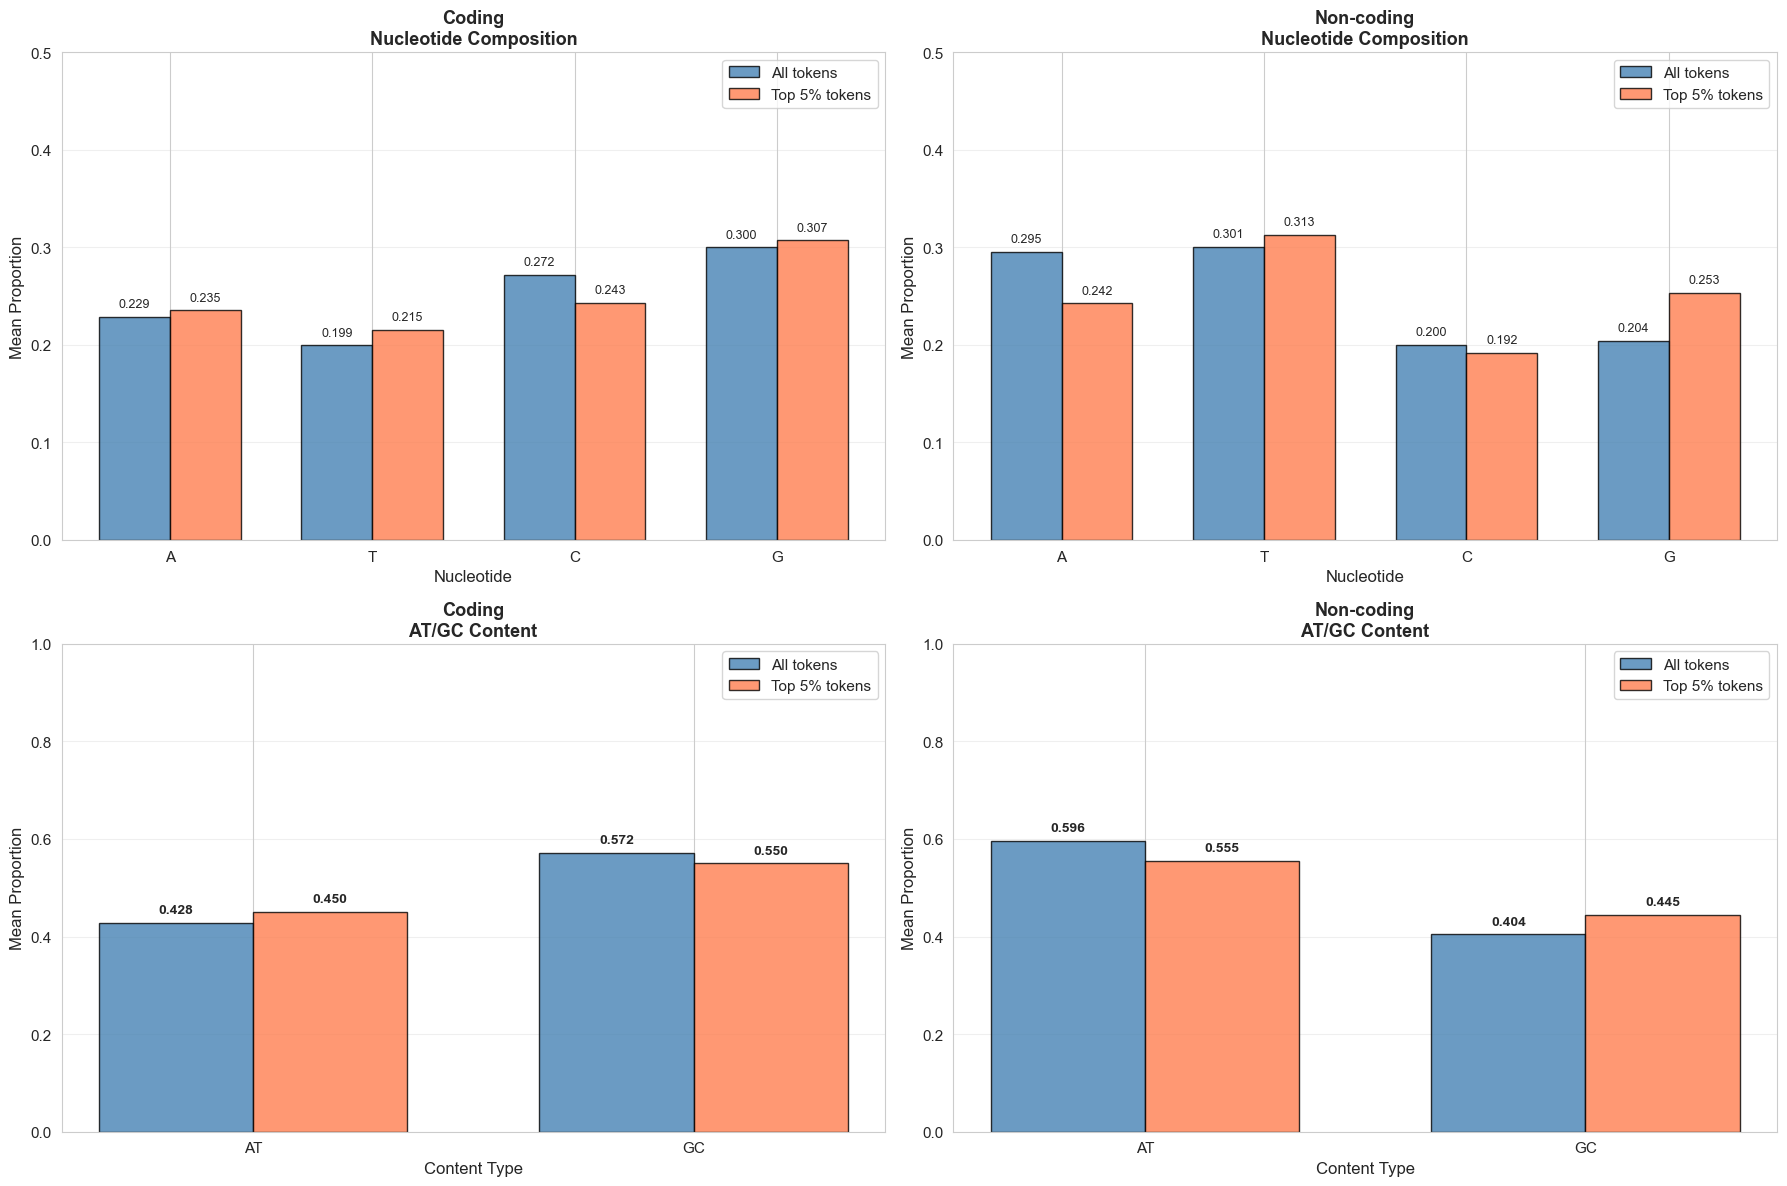

In [23]:
def compare_nucleotide_composition_top5_vs_full(df_full, df_top5, only_correct=True):
    """
    Compare nucleotide composition between full dataset and top 5% tokens
    """
    if only_correct:
        df_full = df_full[df_full['is_correct'] == True]
        df_top5 = df_top5[df_top5['is_correct'] == True]
    
    def get_nucleotide_composition(token):
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        token_upper = token.upper()
        total = len(token_upper)
        if total == 0:
            return None
        return {
            'A': token_upper.count('A') / total,
            'T': token_upper.count('T') / total,
            'C': token_upper.count('C') / total,
            'G': token_upper.count('G') / total,
            'AT': (token_upper.count('A') + token_upper.count('T')) / total,
            'GC': (token_upper.count('G') + token_upper.count('C')) / total,
        }
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        # FULL DATASET
        full_subset = df_full[df_full['sequence_type'] == seq_type]
        full_comp = {'A': [], 'T': [], 'C': [], 'G': [], 'AT': [], 'GC': []}
        
        for _, row in full_subset.iterrows():
            tokens = row['tokens'].split('|')
            for token in tokens:
                comp = get_nucleotide_composition(token)
                if comp:
                    for nuc in ['A', 'T', 'C', 'G', 'AT', 'GC']:
                        full_comp[nuc].append(comp[nuc])
        
        # TOP 5% DATASET
        top5_subset = df_top5[df_top5['sequence_type'] == seq_type]
        top5_comp = {'A': [], 'T': [], 'C': [], 'G': [], 'AT': [], 'GC': []}
        
        for _, row in top5_subset.iterrows():
            tokens = row['tokens'].split('|')
            for token in tokens:
                comp = get_nucleotide_composition(token)
                if comp:
                    for nuc in ['A', 'T', 'C', 'G', 'AT', 'GC']:
                        top5_comp[nuc].append(comp[nuc])
        
        # Plot nucleotide composition comparison
        nucleotides = ['A', 'T', 'C', 'G']
        full_means = [np.mean(full_comp[nuc]) for nuc in nucleotides]
        top5_means = [np.mean(top5_comp[nuc]) for nuc in nucleotides]
        
        x = np.arange(len(nucleotides))
        width = 0.35
        
        axes[0, col_idx].bar(x - width/2, full_means, width, label='All tokens', 
                            color='steelblue', alpha=0.8, edgecolor='black')
        axes[0, col_idx].bar(x + width/2, top5_means, width, label='Top 5% tokens',
                            color='coral', alpha=0.8, edgecolor='black')
        
        axes[0, col_idx].set_xlabel('Nucleotide', fontsize=12)
        axes[0, col_idx].set_ylabel('Mean Proportion', fontsize=12)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()}\nNucleotide Composition',
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].set_xticks(x)
        axes[0, col_idx].set_xticklabels(nucleotides)
        axes[0, col_idx].legend()
        axes[0, col_idx].grid(True, alpha=0.3, axis='y')
        axes[0, col_idx].set_ylim(0, 0.5)
        
        # Add value labels
        for i, (f, t) in enumerate(zip(full_means, top5_means)):
            axes[0, col_idx].text(i - width/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=9)
            axes[0, col_idx].text(i + width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9)
        
        # Plot AT/GC content comparison
        full_at_gc = [np.mean(full_comp['AT']), np.mean(full_comp['GC'])]
        top5_at_gc = [np.mean(top5_comp['AT']), np.mean(top5_comp['GC'])]
        
        x2 = np.arange(2)
        axes[1, col_idx].bar(x2 - width/2, full_at_gc, width, label='All tokens',
                            color='steelblue', alpha=0.8, edgecolor='black')
        axes[1, col_idx].bar(x2 + width/2, top5_at_gc, width, label='Top 5% tokens',
                            color='coral', alpha=0.8, edgecolor='black')
        
        axes[1, col_idx].set_xlabel('Content Type', fontsize=12)
        axes[1, col_idx].set_ylabel('Mean Proportion', fontsize=12)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()}\nAT/GC Content',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].set_xticks(x2)
        axes[1, col_idx].set_xticklabels(['AT', 'GC'])
        axes[1, col_idx].legend()
        axes[1, col_idx].grid(True, alpha=0.3, axis='y')
        axes[1, col_idx].set_ylim(0, 1.0)
        
        # Add value labels
        for i, (f, t) in enumerate(zip(full_at_gc, top5_at_gc)):
            axes[1, col_idx].text(i - width/2, f + 0.02, f'{f:.3f}', ha='center', fontsize=10, fontweight='bold')
            axes[1, col_idx].text(i + width/2, t + 0.02, f'{t:.3f}', ha='center', fontsize=10, fontweight='bold')
        
        # Print statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Nucleotide Composition Comparison")
        print(f"{'='*70}")
        print(f"\nFull Dataset (n={len(full_comp['A'])} tokens):")
        for nuc in ['A', 'T', 'C', 'G', 'AT', 'GC']:
            print(f"  {nuc}: {np.mean(full_comp[nuc]):.4f} ± {np.std(full_comp[nuc]):.4f}")
        
        print(f"\nTop 5% Dataset (n={len(top5_comp['A'])} tokens):")
        for nuc in ['A', 'T', 'C', 'G', 'AT', 'GC']:
            print(f"  {nuc}: {np.mean(top5_comp[nuc]):.4f} ± {np.std(top5_comp[nuc]):.4f}")
        
        print(f"\nDifferences (Top5% - Full):")
        for nuc in ['A', 'T', 'C', 'G', 'AT', 'GC']:
            diff = np.mean(top5_comp[nuc]) - np.mean(full_comp[nuc])
            print(f"  {nuc}: {diff:+.4f}")
    
    plt.tight_layout()
    plt.show()

# Run comparison
compare_nucleotide_composition_top5_vs_full(df, df_top5, only_correct=True)

## Step 3: Token Frequency Distribution (Top 5%)


CODING - Top 5% Token Frequencies
  Unique positive tokens: 483
  Unique negative tokens: 451
  Total positive occurrences: 25851
  Total negative occurrences: 15167

NON-CODING - Top 5% Token Frequencies
  Unique positive tokens: 395
  Unique negative tokens: 476
  Total positive occurrences: 6485
  Total negative occurrences: 9830


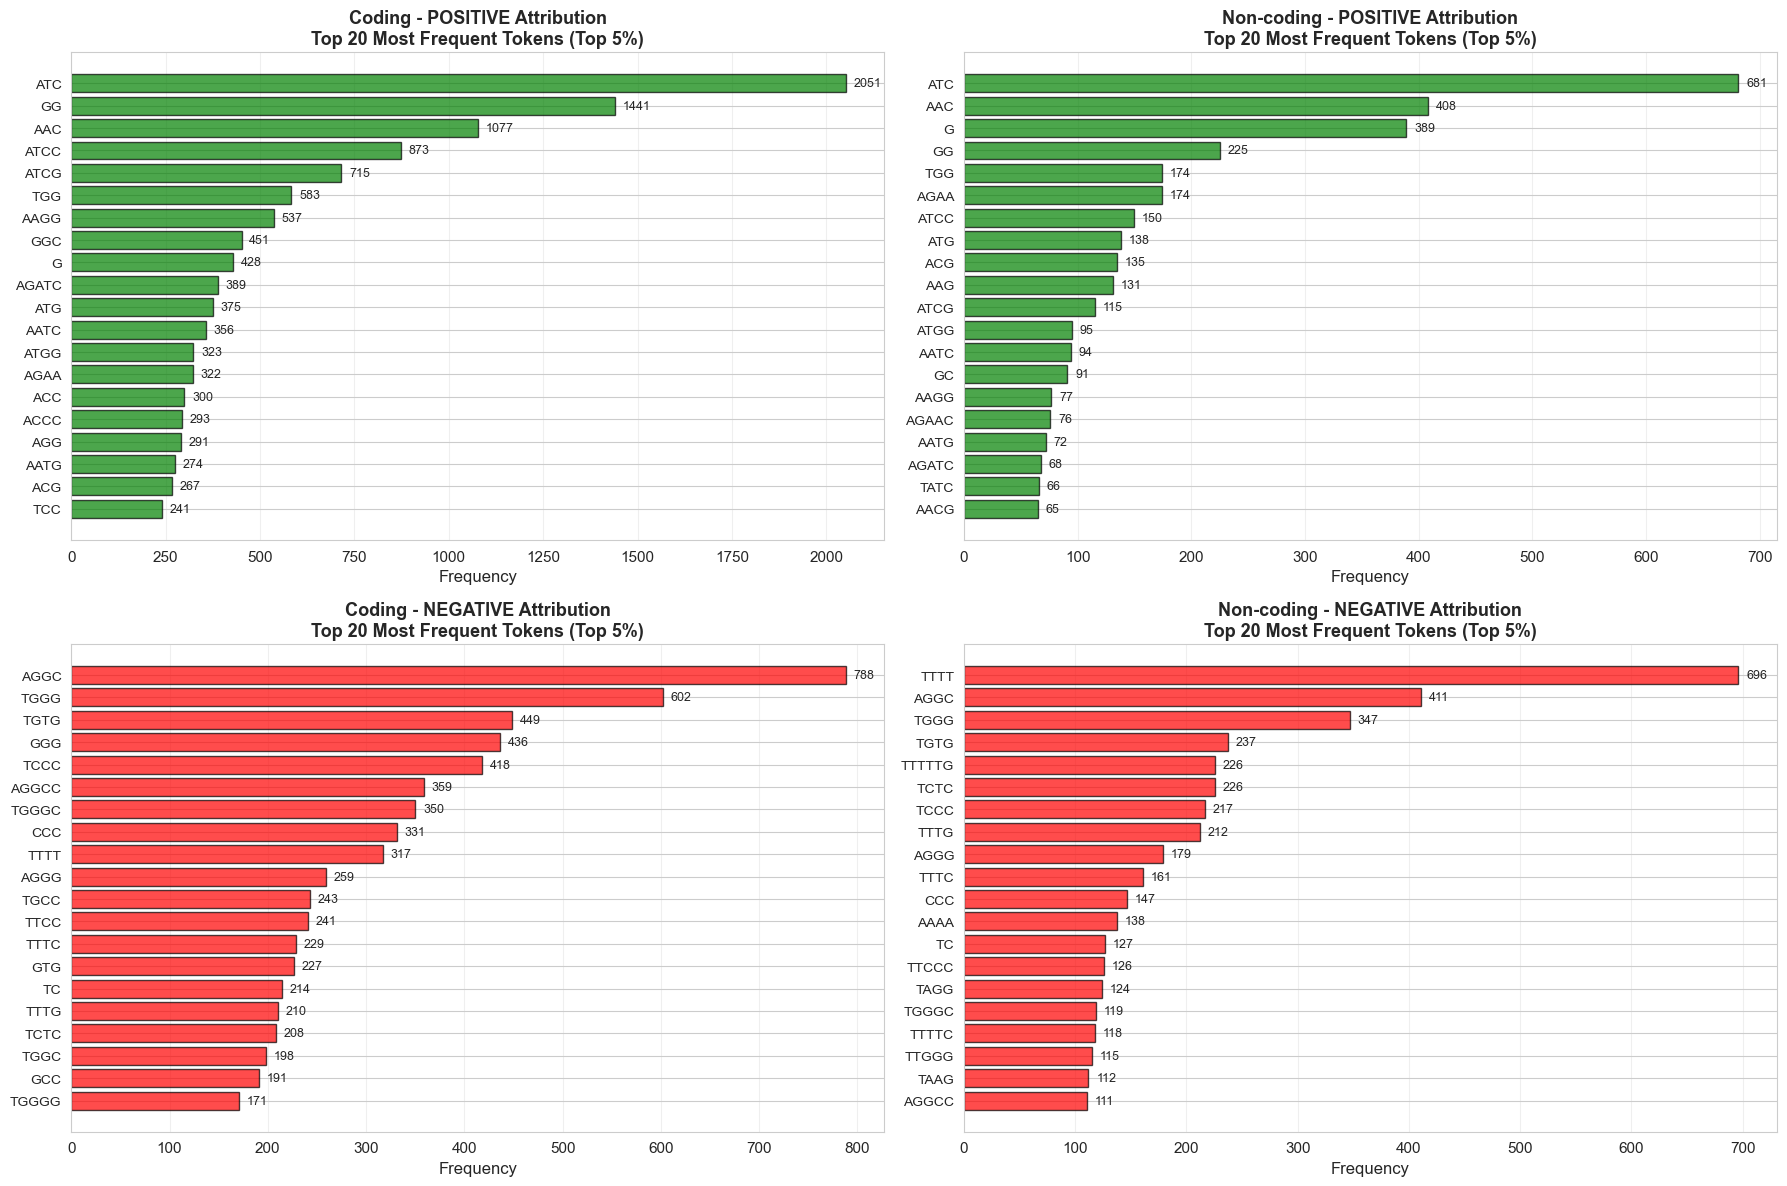

In [24]:
def analyze_top5_token_frequencies(df_top5, top_n=20):
    """
    Analyze most frequent tokens in top 5% dataset
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df_top5[df_top5['sequence_type'] == seq_type]
        
        # Separate positive and negative
        token_positive = []
        token_negative = []
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                if attr > 0:
                    token_positive.append(token)
                else:
                    token_negative.append(token)
        
        # Count frequencies
        freq_positive = Counter(token_positive)
        freq_negative = Counter(token_negative)
        
        # Plot positive
        top_pos = freq_positive.most_common(top_n)
        if top_pos:
            tokens_pos = [t for t, _ in top_pos]
            counts_pos = [c for _, c in top_pos]
            
            axes[0, col_idx].barh(range(len(tokens_pos)), counts_pos, color='green', alpha=0.7, edgecolor='black')
            axes[0, col_idx].set_yticks(range(len(tokens_pos)))
            axes[0, col_idx].set_yticklabels(tokens_pos, fontsize=10)
            axes[0, col_idx].set_xlabel('Frequency', fontsize=12)
            axes[0, col_idx].set_title(f'{seq_type.capitalize()} - POSITIVE Attribution\nTop {top_n} Most Frequent Tokens (Top 5%)',
                                       fontsize=13, fontweight='bold')
            axes[0, col_idx].invert_yaxis()
            axes[0, col_idx].grid(True, alpha=0.3, axis='x')
            
            # Add value labels
            for i, count in enumerate(counts_pos):
                axes[0, col_idx].text(count + max(counts_pos)*0.01, i, str(count), 
                                     va='center', fontsize=9)
        
        # Plot negative
        top_neg = freq_negative.most_common(top_n)
        if top_neg:
            tokens_neg = [t for t, _ in top_neg]
            counts_neg = [c for _, c in top_neg]
            
            axes[1, col_idx].barh(range(len(tokens_neg)), counts_neg, color='red', alpha=0.7, edgecolor='black')
            axes[1, col_idx].set_yticks(range(len(tokens_neg)))
            axes[1, col_idx].set_yticklabels(tokens_neg, fontsize=10)
            axes[1, col_idx].set_xlabel('Frequency', fontsize=12)
            axes[1, col_idx].set_title(f'{seq_type.capitalize()} - NEGATIVE Attribution\nTop {top_n} Most Frequent Tokens (Top 5%)',
                                       fontsize=13, fontweight='bold')
            axes[1, col_idx].invert_yaxis()
            axes[1, col_idx].grid(True, alpha=0.3, axis='x')
            
            # Add value labels
            for i, count in enumerate(counts_neg):
                axes[1, col_idx].text(count + max(counts_neg)*0.01, i, str(count),
                                     va='center', fontsize=9)
        
        # Print statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Top 5% Token Frequencies")
        print(f"{'='*70}")
        print(f"  Unique positive tokens: {len(freq_positive)}")
        print(f"  Unique negative tokens: {len(freq_negative)}")
        print(f"  Total positive occurrences: {sum(freq_positive.values())}")
        print(f"  Total negative occurrences: {sum(freq_negative.values())}")
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_top5_token_frequencies(df_top5, top_n=20)

## Step 4: Token Length Distribution (Top 5% vs Full)


CODING - Token Length Statistics
  Full Dataset:
    Mean length: 3.78 bp
    Median length: 4 bp
    Std dev: 1.24 bp
    Range: 1-16 bp

  Top 5% Dataset:
    Mean length: 4.15 bp
    Median length: 4 bp
    Std dev: 1.16 bp
    Range: 1-12 bp

  Difference (Top5% - Full):
    Mean: +0.37 bp
    Median: +0 bp

NON-CODING - Token Length Statistics
  Full Dataset:
    Mean length: 4.01 bp
    Median length: 4 bp
    Std dev: 1.28 bp
    Range: 1-16 bp

  Top 5% Dataset:
    Mean length: 4.32 bp
    Median length: 4 bp
    Std dev: 1.37 bp
    Range: 1-16 bp

  Difference (Top5% - Full):
    Mean: +0.31 bp
    Median: +0 bp


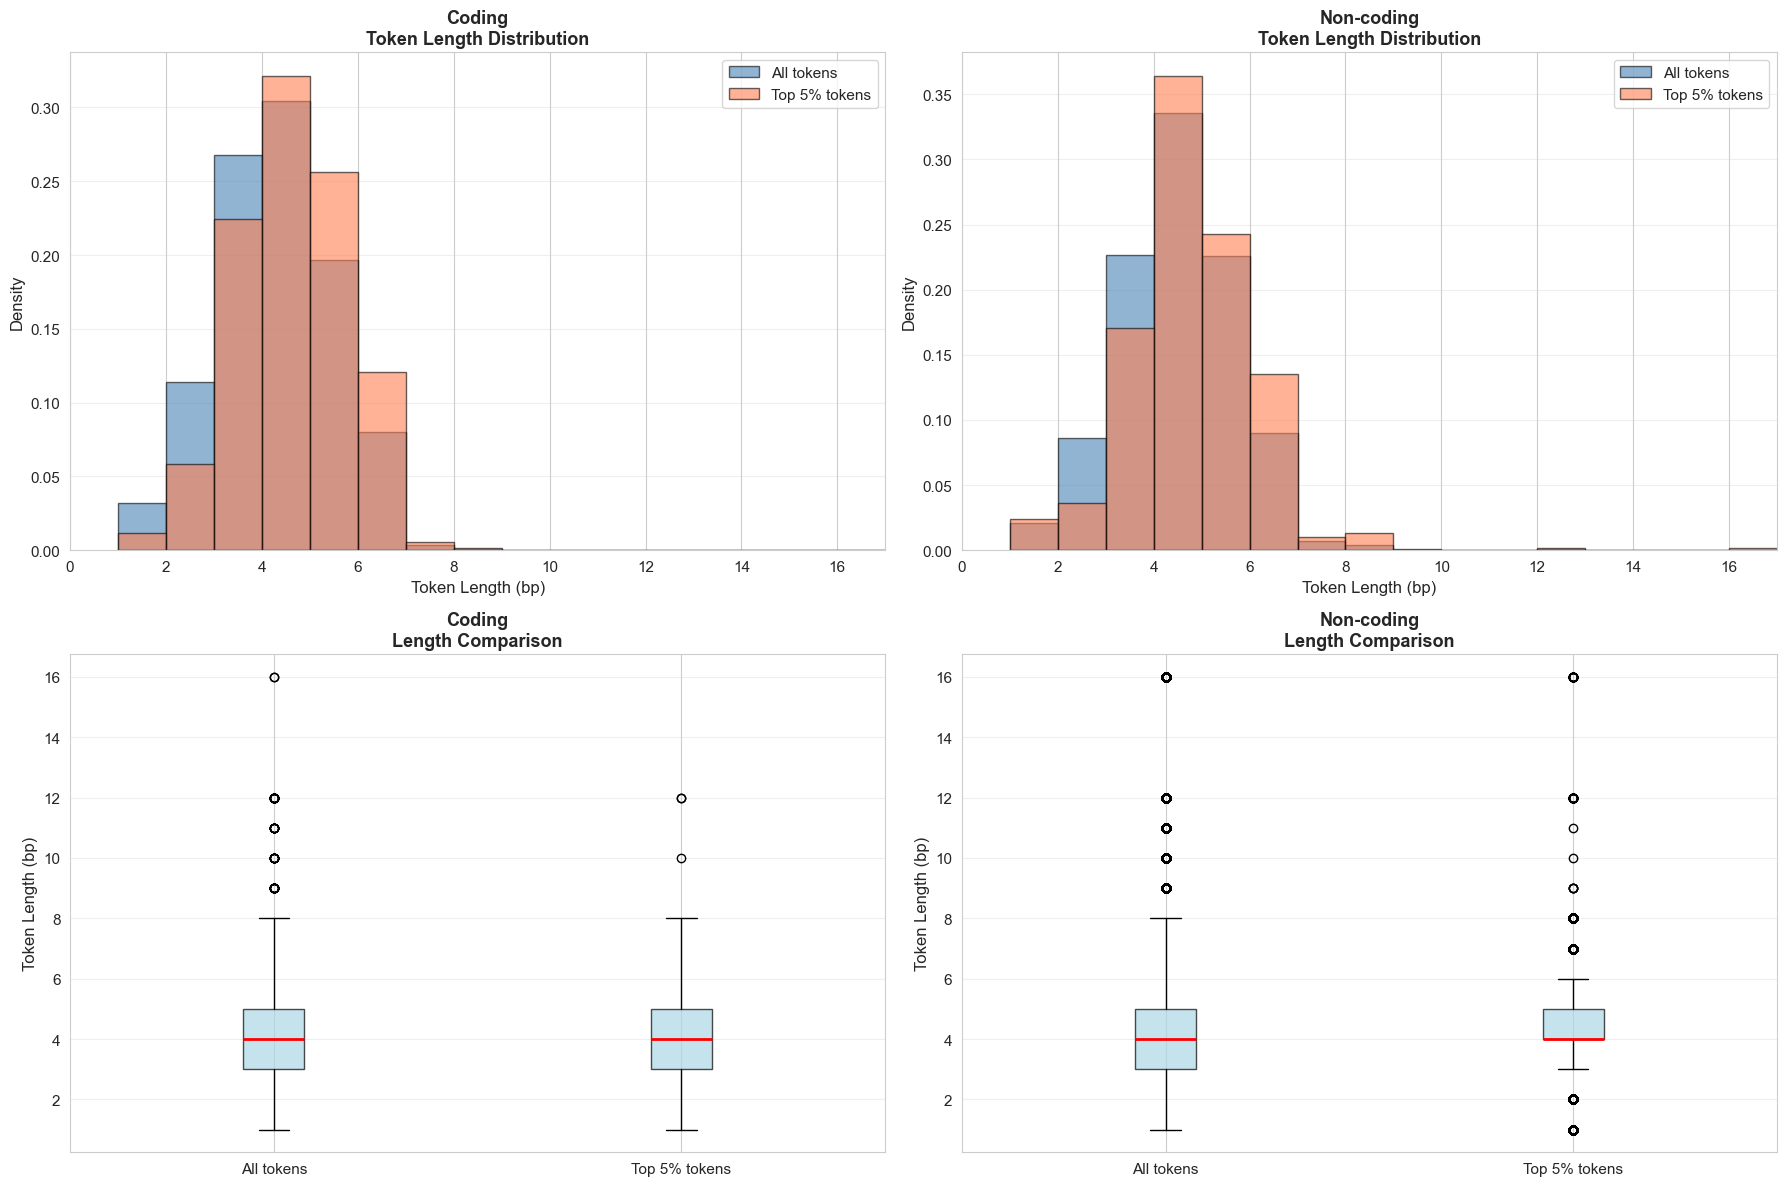

In [25]:
def compare_token_length_distribution(df_full, df_top5):
    """
    Compare token length distributions between full and top 5% datasets
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        # Full dataset lengths
        full_subset = df_full[df_full['sequence_type'] == seq_type]
        full_lengths = []
        for _, row in full_subset.iterrows():
            tokens = row['tokens'].split('|')
            for token in tokens:
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    full_lengths.append(len(token))
        
        # Top 5% dataset lengths
        top5_subset = df_top5[df_top5['sequence_type'] == seq_type]
        top5_lengths = []
        for _, row in top5_subset.iterrows():
            tokens = row['tokens'].split('|')
            for token in tokens:
                if token not in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
                    top5_lengths.append(len(token))
        
        # Histogram comparison
        max_len = min(20, max(max(full_lengths), max(top5_lengths)))
        bins = range(1, max_len + 2)
        
        axes[0, col_idx].hist(full_lengths, bins=bins, alpha=0.6, label='All tokens',
                             color='steelblue', edgecolor='black', density=True)
        axes[0, col_idx].hist(top5_lengths, bins=bins, alpha=0.6, label='Top 5% tokens',
                             color='coral', edgecolor='black', density=True)
        axes[0, col_idx].set_xlabel('Token Length (bp)', fontsize=12)
        axes[0, col_idx].set_ylabel('Density', fontsize=12)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()}\nToken Length Distribution',
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].legend(fontsize=11)
        axes[0, col_idx].grid(True, alpha=0.3, axis='y')
        axes[0, col_idx].set_xlim(0, max_len + 1)
        
        # Box plot comparison
        axes[1, col_idx].boxplot([full_lengths, top5_lengths],
                                labels=['All tokens', 'Top 5% tokens'],
                                patch_artist=True,
                                boxprops=dict(facecolor='lightblue', alpha=0.7),
                                medianprops=dict(color='red', linewidth=2))
        axes[1, col_idx].set_ylabel('Token Length (bp)', fontsize=12)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()}\nLength Comparison',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].grid(True, alpha=0.3, axis='y')
        
        # Print statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Token Length Statistics")
        print(f"{'='*70}")
        print(f"  Full Dataset:")
        print(f"    Mean length: {np.mean(full_lengths):.2f} bp")
        print(f"    Median length: {np.median(full_lengths):.0f} bp")
        print(f"    Std dev: {np.std(full_lengths):.2f} bp")
        print(f"    Range: {min(full_lengths)}-{max(full_lengths)} bp")
        
        print(f"\n  Top 5% Dataset:")
        print(f"    Mean length: {np.mean(top5_lengths):.2f} bp")
        print(f"    Median length: {np.median(top5_lengths):.0f} bp")
        print(f"    Std dev: {np.std(top5_lengths):.2f} bp")
        print(f"    Range: {min(top5_lengths)}-{max(top5_lengths)} bp")
        
        print(f"\n  Difference (Top5% - Full):")
        print(f"    Mean: {np.mean(top5_lengths) - np.mean(full_lengths):+.2f} bp")
        print(f"    Median: {np.median(top5_lengths) - np.median(full_lengths):+.0f} bp")
    
    plt.tight_layout()
    plt.show()

# Run comparison
compare_token_length_distribution(df, df_top5)

## Step 5: Discriminative Motifs (Top 5% Only)


TOP 5% TOKENS - CODING SIGNATURE MOTIFS (Top 30)
Rank   Token           Coding +     NonCod -     Disc Power   N(C+)    N(NC-)  
--------------------------------------------------------------------------------
1      TCATC               0.6862      1.2359      1.9221  201      1       
2      TCTGG               0.6432      0.9617      1.6049  67       3       
3      TTCTCC              0.5873      1.0136      1.6010  32       1       
4      AACATT              0.6459      0.9495      1.5955  17       2       
5      AGGAGC              0.6243      0.9590      1.5833  21       1       
6      ATAAGG              0.7672      0.7448      1.5120  10       1       
7      TCCAC               0.5752      0.9303      1.5055  24       1       
8      AGAGTG              0.7697      0.7349      1.5046  3        1       
9      AGGTGG              0.6471      0.8244      1.4714  32       1       
10     AAAAGG              0.7077      0.7495      1.4572  12       1       
11     AAAACC      

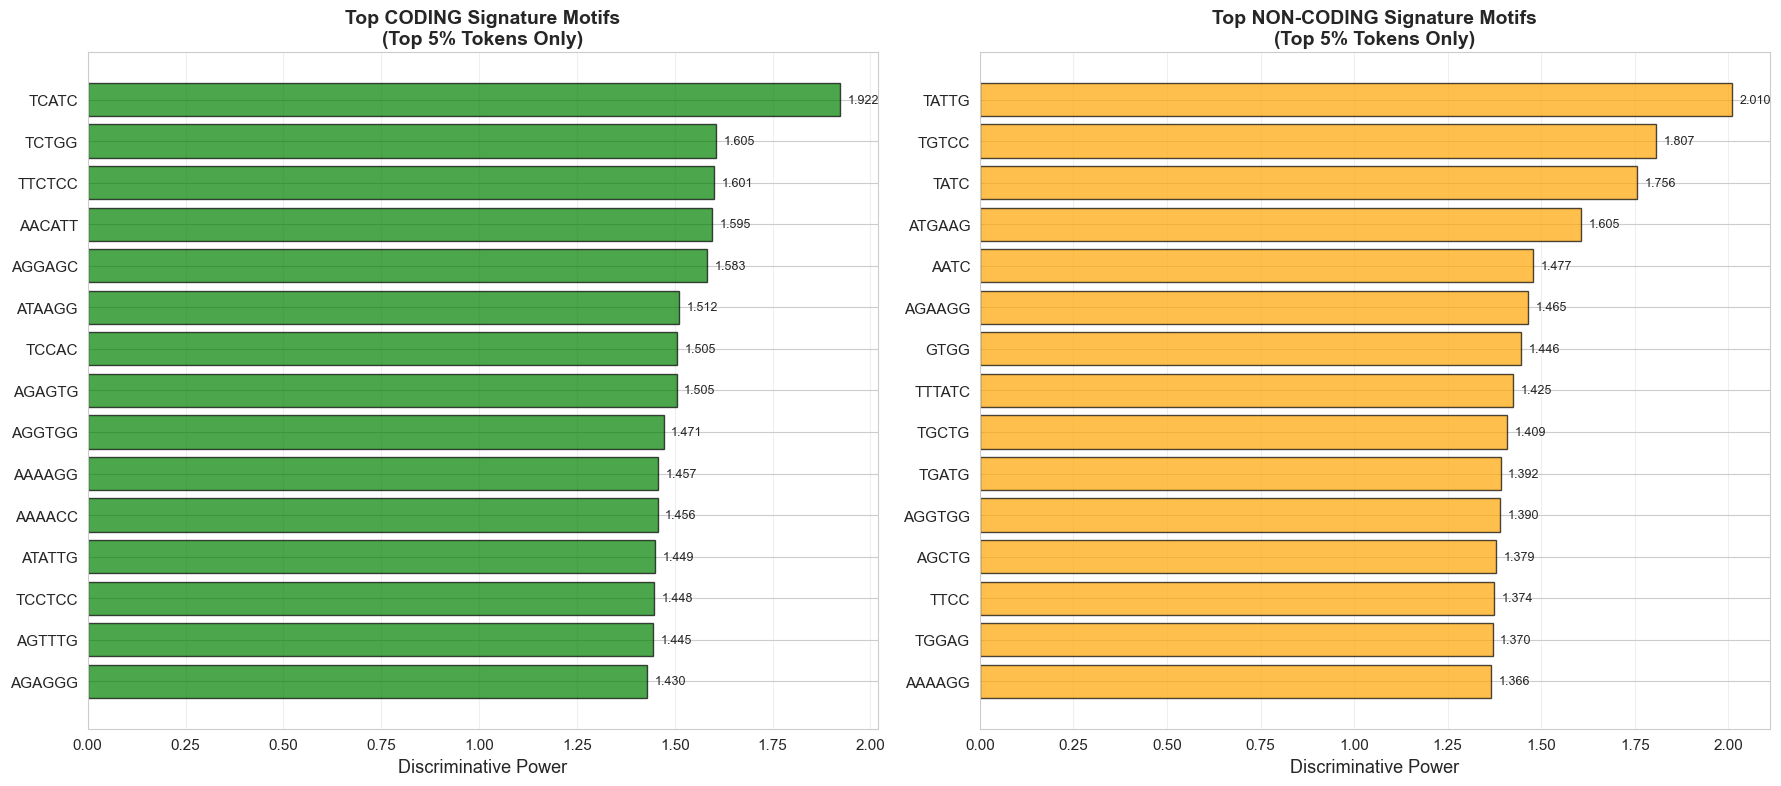

In [26]:
def find_discriminative_motifs_top5(df_top5, top_n=30):
    """
    Identify the most discriminative motifs in top 5% tokens
    """
    # Collect token attributions for each sequence type
    coding_tokens = defaultdict(list)
    noncoding_tokens = defaultdict(list)
    
    for _, row in df_top5.iterrows():
        tokens = row['tokens'].split('|')
        attrs = [float(x) for x in row['attributions'].split('|')]
        seq_type = row['sequence_type']
        
        for token, attr in zip(tokens, attrs):
            if seq_type == 'coding':
                coding_tokens[token].append(attr)
            else:
                noncoding_tokens[token].append(attr)
    
    # Calculate discriminative power
    coding_signatures = []
    noncoding_signatures = []
    
    for token in coding_tokens.keys():
        coding_pos = [a for a in coding_tokens[token] if a > 0]
        noncoding_neg = [abs(a) for a in noncoding_tokens.get(token, []) if a < 0]
        
        if len(coding_pos) >= 3:
            coding_score = np.mean(coding_pos)
            noncoding_opposition = np.mean(noncoding_neg) if len(noncoding_neg) > 0 else 0
            disc_power = coding_score + noncoding_opposition
            coding_signatures.append((token, coding_score, noncoding_opposition, disc_power,
                                     len(coding_pos), len(noncoding_neg)))
    
    for token in noncoding_tokens.keys():
        noncoding_pos = [a for a in noncoding_tokens[token] if a > 0]
        coding_neg = [abs(a) for a in coding_tokens.get(token, []) if a < 0]
        
        if len(noncoding_pos) >= 3:
            noncoding_score = np.mean(noncoding_pos)
            coding_opposition = np.mean(coding_neg) if len(coding_neg) > 0 else 0
            disc_power = noncoding_score + coding_opposition
            noncoding_signatures.append((token, noncoding_score, coding_opposition, disc_power,
                                        len(noncoding_pos), len(coding_neg)))
    
    # Sort by discriminative power
    coding_signatures.sort(key=lambda x: x[3], reverse=True)
    noncoding_signatures.sort(key=lambda x: x[3], reverse=True)
    
    print(f"\n{'='*80}")
    print(f"TOP 5% TOKENS - CODING SIGNATURE MOTIFS (Top {top_n})")
    print(f"{'='*80}")
    print(f"{'Rank':<6} {'Token':<15} {'Coding +':<12} {'NonCod -':<12} {'Disc Power':<12} {'N(C+)':<8} {'N(NC-)':<8}")
    print("-" * 80)
    for rank, (token, cod_score, nc_opp, disc, n_cod, n_nc) in enumerate(coding_signatures[:top_n], 1):
        print(f"{rank:<6} {token:<15} {cod_score:>10.4f}  {nc_opp:>10.4f}  {disc:>10.4f}  {n_cod:<8} {n_nc:<8}")
    
    print(f"\n{'='*80}")
    print(f"TOP 5% TOKENS - NON-CODING SIGNATURE MOTIFS (Top {top_n})")
    print(f"{'='*80}")
    print(f"{'Rank':<6} {'Token':<15} {'NonCod +':<12} {'Coding -':<12} {'Disc Power':<12} {'N(NC+)':<8} {'N(C-)':<8}")
    print("-" * 80)
    for rank, (token, nc_score, cod_opp, disc, n_nc, n_cod) in enumerate(noncoding_signatures[:top_n], 1):
        print(f"{rank:<6} {token:<15} {nc_score:>10.4f}  {cod_opp:>10.4f}  {disc:>10.4f}  {n_nc:<8} {n_cod:<8}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Coding signatures
    top_cod = coding_signatures[:min(15, len(coding_signatures))]
    tokens_cod = [x[0] for x in top_cod]
    disc_pow_cod = [x[3] for x in top_cod]
    
    axes[0].barh(range(len(tokens_cod)), disc_pow_cod, color='green', alpha=0.7, edgecolor='black')
    axes[0].set_yticks(range(len(tokens_cod)))
    axes[0].set_yticklabels(tokens_cod, fontsize=11)
    axes[0].set_xlabel('Discriminative Power', fontsize=13)
    axes[0].set_title('Top CODING Signature Motifs\n(Top 5% Tokens Only)',
                     fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Add values
    for i, val in enumerate(disc_pow_cod):
        axes[0].text(val + max(disc_pow_cod)*0.01, i, f'{val:.3f}',
                    va='center', fontsize=9)
    
    # Non-coding signatures
    top_nc = noncoding_signatures[:min(15, len(noncoding_signatures))]
    tokens_nc = [x[0] for x in top_nc]
    disc_pow_nc = [x[3] for x in top_nc]
    
    axes[1].barh(range(len(tokens_nc)), disc_pow_nc, color='orange', alpha=0.7, edgecolor='black')
    axes[1].set_yticks(range(len(tokens_nc)))
    axes[1].set_yticklabels(tokens_nc, fontsize=11)
    axes[1].set_xlabel('Discriminative Power', fontsize=13)
    axes[1].set_title('Top NON-CODING Signature Motifs\n(Top 5% Tokens Only)',
                     fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis='x')
    
    # Add values
    for i, val in enumerate(disc_pow_nc):
        axes[1].text(val + max(disc_pow_nc)*0.01, i, f'{val:.3f}',
                    va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'coding_signatures': coding_signatures[:top_n],
        'noncoding_signatures': noncoding_signatures[:top_n]
    }

# Run analysis
top5_signatures = find_discriminative_motifs_top5(df_top5, top_n=30)

## Step 6: Summary Comparison - Key Differences

### 📊 INTERPRETATION GUIDE: Top 5% vs Full Dataset

After running the analyses above, look for these key differences:

#### **1. Nucleotide Composition Shifts**
- **If Top 5% has HIGHER GC in coding**: Model strongly relies on GC-richness as a coding signal
- **If Top 5% has HIGHER AT in non-coding**: Model uses AT-richness to identify regulatory regions
- **Larger differences** = more extreme compositional bias in most important tokens

#### **2. Token Frequency Patterns**
- **Rare tokens in Top 5%**: Model found specific discriminative motifs (good!)
- **Common tokens in Top 5%**: Model relies on frequent patterns (statistical approach)
- **Compare token lists**: Are these biologically meaningful motifs?

#### **3. Token Length Preferences**
- **Longer tokens in Top 5%**: Model uses complex, context-rich motifs
- **Shorter tokens in Top 5%**: Model relies on simple dinucleotide signals
- **Length shift** indicates whether model learned compositional vs motif-based features

#### **4. Discriminative Power Concentration**
- **Fewer unique tokens in Top 5%**: Decision concentrated on few key motifs
- **Many unique tokens**: Distributed decision-making
- **Check overlap with known biology**: Are signature motifs recognizable?

#### **5. What Makes a Token "Top 5%"?**

Based on results, you can infer:
- **Biological relevance**: Do high-attribution tokens match known functional elements?
- **Model strategy**: Compositional bias vs specific motifs
- **Feature sparsity**: Few powerful features vs many weak features
- **Interpretability**: Can we explain decisions using top tokens alone?

#### **6. Practical Implications**

**If Top 5% tells a clear story:**
- ✅ Model is interpretable
- ✅ Can create simple rule-based filters
- ✅ Easy to validate biologically

**If Top 5% looks similar to full dataset:**
- Model uses distributed representations
- No single "smoking gun" features
- Harder to interpret but potentially more robust

---

### 🔬 Recommended Actions Based on Results:

1. **Extract top coding/non-coding signature motifs** from Step 5
2. **BLAST search** these motifs against biological databases
3. **Test perturbation**: Mutate top motifs and measure prediction change
4. **Compare with literature**: Do these match known regulatory elements?
5. **Create interpretable rules**: Build decision tree using top tokens

---

---

# 🧬 DEEP DIVE: AT/GC Content and Its Role in Predictions

## Objectives
1. Test if AT/GC content significantly differs between coding and non-coding
2. Analyze correlation between AT/GC content and attribution strength
3. Determine if AT/GC content alone can predict sequence type
4. Understand how model uses compositional bias for decisions

## Analysis 1: Statistical Significance Testing

STATISTICAL SIGNIFICANCE TESTS: AT/GC Content

GC CONTENT COMPARISON

Coding sequences:
  Mean GC: 0.5720 ± 0.2677
  Median GC: 0.5000
  n = 595,921 tokens

Non-coding sequences:
  Mean GC: 0.4042 ± 0.2630
  Median GC: 0.4000
  n = 550,730 tokens

Difference:
  Mean difference: +0.1677
  Effect size (Cohen's d): 0.6322

  Mann-Whitney U test:
    Statistic: 220551991881.50
    p-value: 0.00e+00
    Significant (α=0.05): YES ✓
    Significant (α=0.001): YES ✓✓✓

  Independent t-test:
    Statistic: 338.0807
    p-value: 0.00e+00
    Significant (α=0.05): YES ✓

  Kolmogorov-Smirnov test:
    Statistic: 0.2449
    p-value: 0.00e+00
    Significant (α=0.05): YES ✓

AT CONTENT COMPARISON

Coding sequences:
  Mean AT: 0.4280 ± 0.2677
  Median AT: 0.5000

Non-coding sequences:
  Mean AT: 0.5958 ± 0.2630
  Median AT: 0.6000

Difference:
  Mean difference: -0.1677
  Effect size (Cohen's d): -0.6322

  Mann-Whitney U test:
    Statistic: 107639580448.50
    p-value: 0.00e+00
    Significant (α=

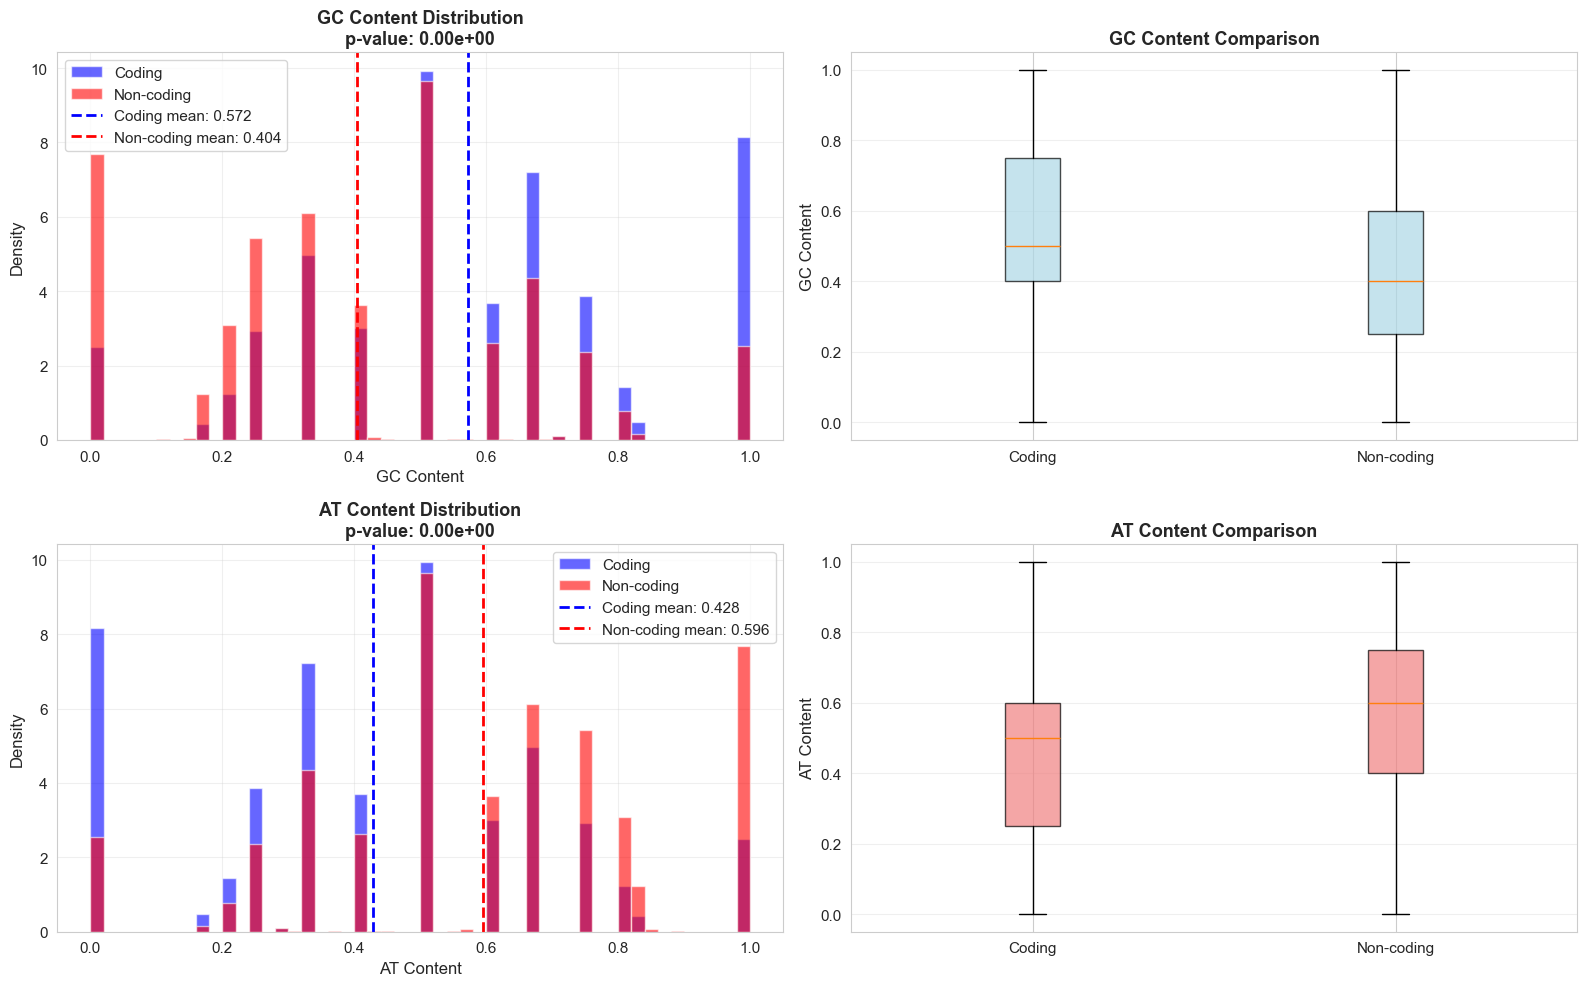

In [27]:
def statistical_test_atgc_content(df, only_correct=True):
    """
    Perform statistical tests to determine if AT/GC content significantly differs
    between coding and non-coding sequences
    """
    from scipy.stats import mannwhitneyu, ttest_ind, ks_2samp
    
    if only_correct:
        df = df[df['is_correct'] == True]
    
    def get_gc_content(token):
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        gc_count = token.upper().count('G') + token.upper().count('C')
        return gc_count / len(token) if len(token) > 0 else 0
    
    def get_at_content(token):
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        at_count = token.upper().count('A') + token.upper().count('T')
        return at_count / len(token) if len(token) > 0 else 0
    
    # Collect GC and AT content for each sequence type
    coding_gc, coding_at = [], []
    noncoding_gc, noncoding_at = [], []
    
    for _, row in df.iterrows():
        tokens = row['tokens'].split('|')
        seq_type = row['sequence_type']
        
        for token in tokens:
            gc = get_gc_content(token)
            at = get_at_content(token)
            
            if gc is not None and at is not None:
                if seq_type == 'coding':
                    coding_gc.append(gc)
                    coding_at.append(at)
                else:
                    noncoding_gc.append(gc)
                    noncoding_at.append(at)
    
    print("="*80)
    print("STATISTICAL SIGNIFICANCE TESTS: AT/GC Content")
    print("="*80)
    
    # GC Content Tests
    print("\n" + "="*80)
    print("GC CONTENT COMPARISON")
    print("="*80)
    
    print(f"\nCoding sequences:")
    print(f"  Mean GC: {np.mean(coding_gc):.4f} ± {np.std(coding_gc):.4f}")
    print(f"  Median GC: {np.median(coding_gc):.4f}")
    print(f"  n = {len(coding_gc):,} tokens")
    
    print(f"\nNon-coding sequences:")
    print(f"  Mean GC: {np.mean(noncoding_gc):.4f} ± {np.std(noncoding_gc):.4f}")
    print(f"  Median GC: {np.median(noncoding_gc):.4f}")
    print(f"  n = {len(noncoding_gc):,} tokens")
    
    print(f"\nDifference:")
    print(f"  Mean difference: {np.mean(coding_gc) - np.mean(noncoding_gc):+.4f}")
    print(f"  Effect size (Cohen's d): {(np.mean(coding_gc) - np.mean(noncoding_gc)) / np.sqrt((np.std(coding_gc)**2 + np.std(noncoding_gc)**2) / 2):.4f}")
    
    # Mann-Whitney U test (non-parametric)
    stat_mw, pval_mw = mannwhitneyu(coding_gc, noncoding_gc, alternative='two-sided')
    print(f"\n  Mann-Whitney U test:")
    print(f"    Statistic: {stat_mw:.2f}")
    print(f"    p-value: {pval_mw:.2e}")
    print(f"    Significant (α=0.05): {'YES ✓' if pval_mw < 0.05 else 'NO ✗'}")
    print(f"    Significant (α=0.001): {'YES ✓✓✓' if pval_mw < 0.001 else 'NO'}")
    
    # t-test (parametric)
    stat_t, pval_t = ttest_ind(coding_gc, noncoding_gc)
    print(f"\n  Independent t-test:")
    print(f"    Statistic: {stat_t:.4f}")
    print(f"    p-value: {pval_t:.2e}")
    print(f"    Significant (α=0.05): {'YES ✓' if pval_t < 0.05 else 'NO ✗'}")
    
    # Kolmogorov-Smirnov test (distribution difference)
    stat_ks, pval_ks = ks_2samp(coding_gc, noncoding_gc)
    print(f"\n  Kolmogorov-Smirnov test:")
    print(f"    Statistic: {stat_ks:.4f}")
    print(f"    p-value: {pval_ks:.2e}")
    print(f"    Significant (α=0.05): {'YES ✓' if pval_ks < 0.05 else 'NO ✗'}")
    
    # AT Content Tests
    print("\n" + "="*80)
    print("AT CONTENT COMPARISON")
    print("="*80)
    
    print(f"\nCoding sequences:")
    print(f"  Mean AT: {np.mean(coding_at):.4f} ± {np.std(coding_at):.4f}")
    print(f"  Median AT: {np.median(coding_at):.4f}")
    
    print(f"\nNon-coding sequences:")
    print(f"  Mean AT: {np.mean(noncoding_at):.4f} ± {np.std(noncoding_at):.4f}")
    print(f"  Median AT: {np.median(noncoding_at):.4f}")
    
    print(f"\nDifference:")
    print(f"  Mean difference: {np.mean(coding_at) - np.mean(noncoding_at):+.4f}")
    print(f"  Effect size (Cohen's d): {(np.mean(coding_at) - np.mean(noncoding_at)) / np.sqrt((np.std(coding_at)**2 + np.std(noncoding_at)**2) / 2):.4f}")
    
    stat_mw_at, pval_mw_at = mannwhitneyu(coding_at, noncoding_at, alternative='two-sided')
    print(f"\n  Mann-Whitney U test:")
    print(f"    Statistic: {stat_mw_at:.2f}")
    print(f"    p-value: {pval_mw_at:.2e}")
    print(f"    Significant (α=0.05): {'YES ✓' if pval_mw_at < 0.05 else 'NO ✗'}")
    print(f"    Significant (α=0.001): {'YES ✓✓✓' if pval_mw_at < 0.001 else 'NO'}")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # GC Content - Histograms
    axes[0, 0].hist(coding_gc, bins=50, alpha=0.6, label='Coding', color='blue', density=True)
    axes[0, 0].hist(noncoding_gc, bins=50, alpha=0.6, label='Non-coding', color='red', density=True)
    axes[0, 0].axvline(np.mean(coding_gc), color='blue', linestyle='--', linewidth=2, label=f'Coding mean: {np.mean(coding_gc):.3f}')
    axes[0, 0].axvline(np.mean(noncoding_gc), color='red', linestyle='--', linewidth=2, label=f'Non-coding mean: {np.mean(noncoding_gc):.3f}')
    axes[0, 0].set_xlabel('GC Content', fontsize=12)
    axes[0, 0].set_ylabel('Density', fontsize=12)
    axes[0, 0].set_title(f'GC Content Distribution\np-value: {pval_mw:.2e}', fontsize=13, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # GC Content - Box plots
    axes[0, 1].boxplot([coding_gc, noncoding_gc], labels=['Coding', 'Non-coding'],
                       patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[0, 1].set_ylabel('GC Content', fontsize=12)
    axes[0, 1].set_title('GC Content Comparison', fontsize=13, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # AT Content - Histograms
    axes[1, 0].hist(coding_at, bins=50, alpha=0.6, label='Coding', color='blue', density=True)
    axes[1, 0].hist(noncoding_at, bins=50, alpha=0.6, label='Non-coding', color='red', density=True)
    axes[1, 0].axvline(np.mean(coding_at), color='blue', linestyle='--', linewidth=2, label=f'Coding mean: {np.mean(coding_at):.3f}')
    axes[1, 0].axvline(np.mean(noncoding_at), color='red', linestyle='--', linewidth=2, label=f'Non-coding mean: {np.mean(noncoding_at):.3f}')
    axes[1, 0].set_xlabel('AT Content', fontsize=12)
    axes[1, 0].set_ylabel('Density', fontsize=12)
    axes[1, 0].set_title(f'AT Content Distribution\np-value: {pval_mw_at:.2e}', fontsize=13, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # AT Content - Box plots
    axes[1, 1].boxplot([coding_at, noncoding_at], labels=['Coding', 'Non-coding'],
                       patch_artist=True,
                       boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[1, 1].set_ylabel('AT Content', fontsize=12)
    axes[1, 1].set_title('AT Content Comparison', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'coding_gc': coding_gc,
        'noncoding_gc': noncoding_gc,
        'coding_at': coding_at,
        'noncoding_at': noncoding_at,
        'gc_pvalue': pval_mw,
        'at_pvalue': pval_mw_at
    }

# Run statistical tests
atgc_stats = statistical_test_atgc_content(df, only_correct=True)

## Analysis 2: GC Content vs Attribution Strength & Sign


CODING - GC Content vs Attribution Analysis

Correlations:
  GC vs Attribution (signed): r = -0.0938
  GC vs |Attribution|: r = -0.0436

GC Content by Attribution Sign:
  Positive attributions:
    Mean GC: 0.5578 ± 0.2718
    Median GC: 0.5000
    n = 362,038
  Negative attributions:
    Mean GC: 0.5939 ± 0.2598
    Median GC: 0.6000
    n = 233,883

  Difference (Positive - Negative):
    Mean GC difference: -0.0361
    Mann-Whitney U test p-value: 0.00e+00
    Significant (α=0.05): YES ✓

NON-CODING - GC Content vs Attribution Analysis

Correlations:
  GC vs Attribution (signed): r = 0.0685
  GC vs |Attribution|: r = 0.0150

GC Content by Attribution Sign:
  Positive attributions:
    Mean GC: 0.4222 ± 0.2481
    Median GC: 0.4000
    n = 265,442
  Negative attributions:
    Mean GC: 0.3875 ± 0.2750
    Median GC: 0.4000
    n = 285,288

  Difference (Positive - Negative):
    Mean GC difference: +0.0347
    Mann-Whitney U test p-value: 0.00e+00
    Significant (α=0.05): YES ✓


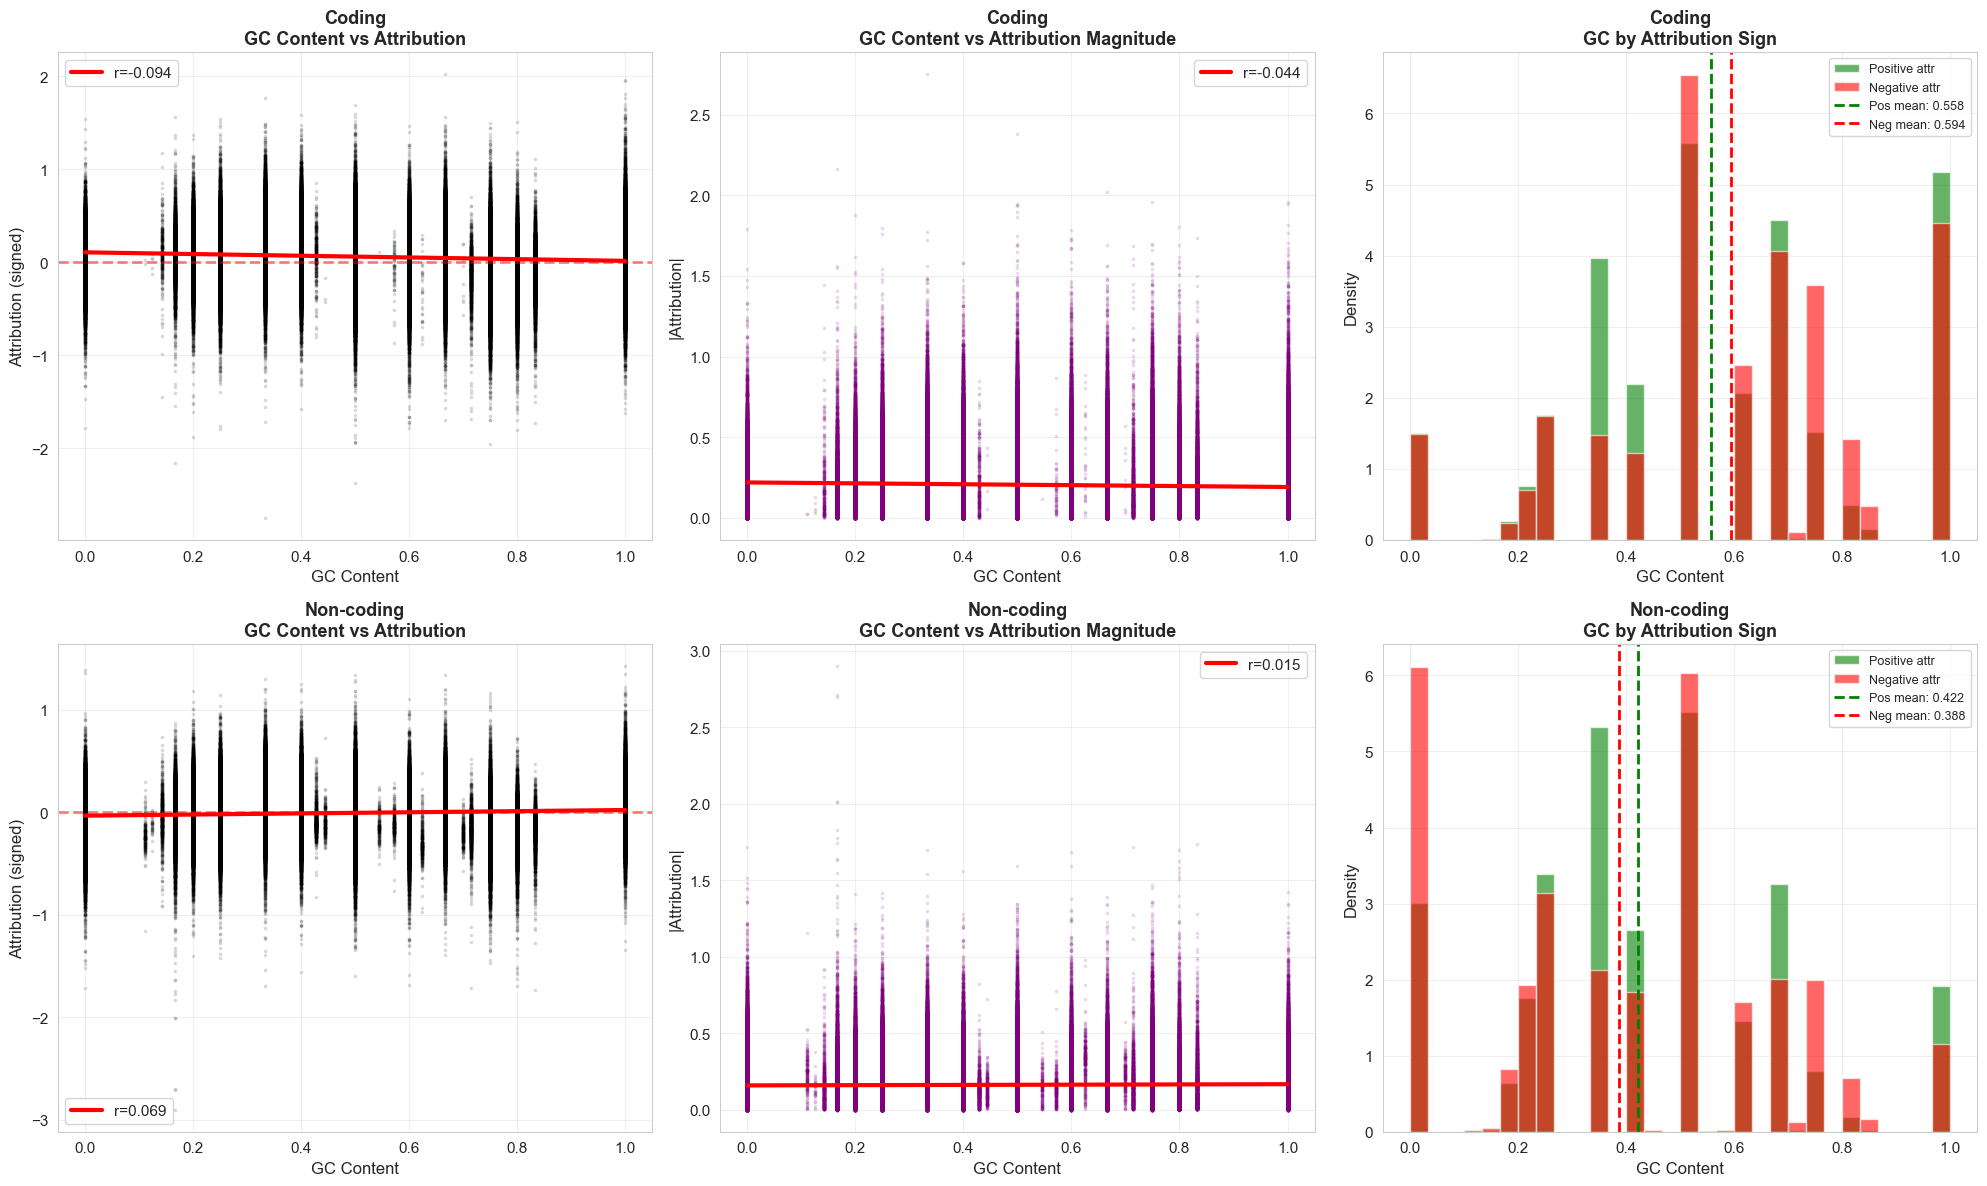

In [28]:
def analyze_gc_attribution_relationship(df, only_correct=True):
    """
    Analyze how GC content correlates with attribution magnitude and sign
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    def get_gc_content(token):
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        gc_count = token.upper().count('G') + token.upper().count('C')
        return gc_count / len(token) if len(token) > 0 else 0
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    for row_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        # Collect data
        gc_content = []
        attributions = []
        abs_attributions = []
        positive_attrs = []
        negative_attrs = []
        gc_positive = []
        gc_negative = []
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                gc = get_gc_content(token)
                if gc is not None:
                    gc_content.append(gc)
                    attributions.append(attr)
                    abs_attributions.append(abs(attr))
                    
                    if attr > 0:
                        positive_attrs.append(attr)
                        gc_positive.append(gc)
                    else:
                        negative_attrs.append(attr)
                        gc_negative.append(gc)
        
        # Plot 1: GC vs Attribution (scatter with trend)
        axes[row_idx, 0].scatter(gc_content, attributions, alpha=0.1, s=3, c='black')
        axes[row_idx, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
        
        # Add trend line
        if len(gc_content) > 100:
            z = np.polyfit(gc_content, attributions, 1)
            p = np.poly1d(z)
            x_line = np.linspace(0, 1, 100)
            corr = np.corrcoef(gc_content, attributions)[0, 1]
            axes[row_idx, 0].plot(x_line, p(x_line), "r-", linewidth=3, 
                                 label=f'r={corr:.3f}')
        
        axes[row_idx, 0].set_xlabel('GC Content', fontsize=12)
        axes[row_idx, 0].set_ylabel('Attribution (signed)', fontsize=12)
        axes[row_idx, 0].set_title(f'{seq_type.capitalize()}\nGC Content vs Attribution',
                                   fontsize=13, fontweight='bold')
        axes[row_idx, 0].legend()
        axes[row_idx, 0].grid(True, alpha=0.3)
        
        # Plot 2: GC vs |Attribution|
        axes[row_idx, 1].scatter(gc_content, abs_attributions, alpha=0.1, s=3, c='purple')
        
        if len(gc_content) > 100:
            z = np.polyfit(gc_content, abs_attributions, 1)
            p = np.poly1d(z)
            x_line = np.linspace(0, 1, 100)
            corr = np.corrcoef(gc_content, abs_attributions)[0, 1]
            axes[row_idx, 1].plot(x_line, p(x_line), "r-", linewidth=3,
                                 label=f'r={corr:.3f}')
        
        axes[row_idx, 1].set_xlabel('GC Content', fontsize=12)
        axes[row_idx, 1].set_ylabel('|Attribution|', fontsize=12)
        axes[row_idx, 1].set_title(f'{seq_type.capitalize()}\nGC Content vs Attribution Magnitude',
                                   fontsize=13, fontweight='bold')
        axes[row_idx, 1].legend()
        axes[row_idx, 1].grid(True, alpha=0.3)
        
        # Plot 3: Distribution by attribution sign
        axes[row_idx, 2].hist(gc_positive, bins=30, alpha=0.6, label='Positive attr', 
                             color='green', density=True)
        axes[row_idx, 2].hist(gc_negative, bins=30, alpha=0.6, label='Negative attr',
                             color='red', density=True)
        axes[row_idx, 2].axvline(np.mean(gc_positive), color='green', linestyle='--', 
                                linewidth=2, label=f'Pos mean: {np.mean(gc_positive):.3f}')
        axes[row_idx, 2].axvline(np.mean(gc_negative), color='red', linestyle='--',
                                linewidth=2, label=f'Neg mean: {np.mean(gc_negative):.3f}')
        axes[row_idx, 2].set_xlabel('GC Content', fontsize=12)
        axes[row_idx, 2].set_ylabel('Density', fontsize=12)
        axes[row_idx, 2].set_title(f'{seq_type.capitalize()}\nGC by Attribution Sign',
                                   fontsize=13, fontweight='bold')
        axes[row_idx, 2].legend(fontsize=9)
        axes[row_idx, 2].grid(True, alpha=0.3)
        
        # Print statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - GC Content vs Attribution Analysis")
        print(f"{'='*70}")
        
        print(f"\nCorrelations:")
        corr_signed = np.corrcoef(gc_content, attributions)[0, 1]
        corr_abs = np.corrcoef(gc_content, abs_attributions)[0, 1]
        print(f"  GC vs Attribution (signed): r = {corr_signed:.4f}")
        print(f"  GC vs |Attribution|: r = {corr_abs:.4f}")
        
        print(f"\nGC Content by Attribution Sign:")
        print(f"  Positive attributions:")
        print(f"    Mean GC: {np.mean(gc_positive):.4f} ± {np.std(gc_positive):.4f}")
        print(f"    Median GC: {np.median(gc_positive):.4f}")
        print(f"    n = {len(gc_positive):,}")
        
        print(f"  Negative attributions:")
        print(f"    Mean GC: {np.mean(gc_negative):.4f} ± {np.std(gc_negative):.4f}")
        print(f"    Median GC: {np.median(gc_negative):.4f}")
        print(f"    n = {len(gc_negative):,}")
        
        print(f"\n  Difference (Positive - Negative):")
        print(f"    Mean GC difference: {np.mean(gc_positive) - np.mean(gc_negative):+.4f}")
        
        # Statistical test
        from scipy.stats import mannwhitneyu
        stat, pval = mannwhitneyu(gc_positive, gc_negative)
        print(f"    Mann-Whitney U test p-value: {pval:.2e}")
        print(f"    Significant (α=0.05): {'YES ✓' if pval < 0.05 else 'NO ✗'}")
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_gc_attribution_relationship(df, only_correct=True)

## Analysis 3: GC/AT Content Stratification Analysis


CODING - Stratified GC Analysis

GC Bin          Mean Attr       Mean |Attr|     % Positive      Count     
----------------------------------------------------------------------
0.00-0.10          0.0405          0.1795           60.9%    29,806
0.10-0.20          0.0860          0.2229           64.8%     5,385
0.20-0.30          0.0688          0.2109           61.5%    49,475
0.30-0.40          0.1855          0.2436           80.6%    59,318
0.40-0.50          0.1517          0.2433           73.5%    36,066
0.50-0.60          0.0337          0.1964           56.8%   162,513
0.60-0.70          0.0620          0.1825           63.2%    86,055
0.70-0.80         -0.0776          0.2107           39.2%    47,379
0.80-0.90         -0.1106          0.2322           34.9%    22,685

Key Findings:
  Highest positive attribution: GC=0.30-0.40, mean=0.1855
  Highest negative attribution: GC=0.80-0.90, mean=-0.1106

NON-CODING - Stratified GC Analysis

GC Bin          Mean Attr       Mean |

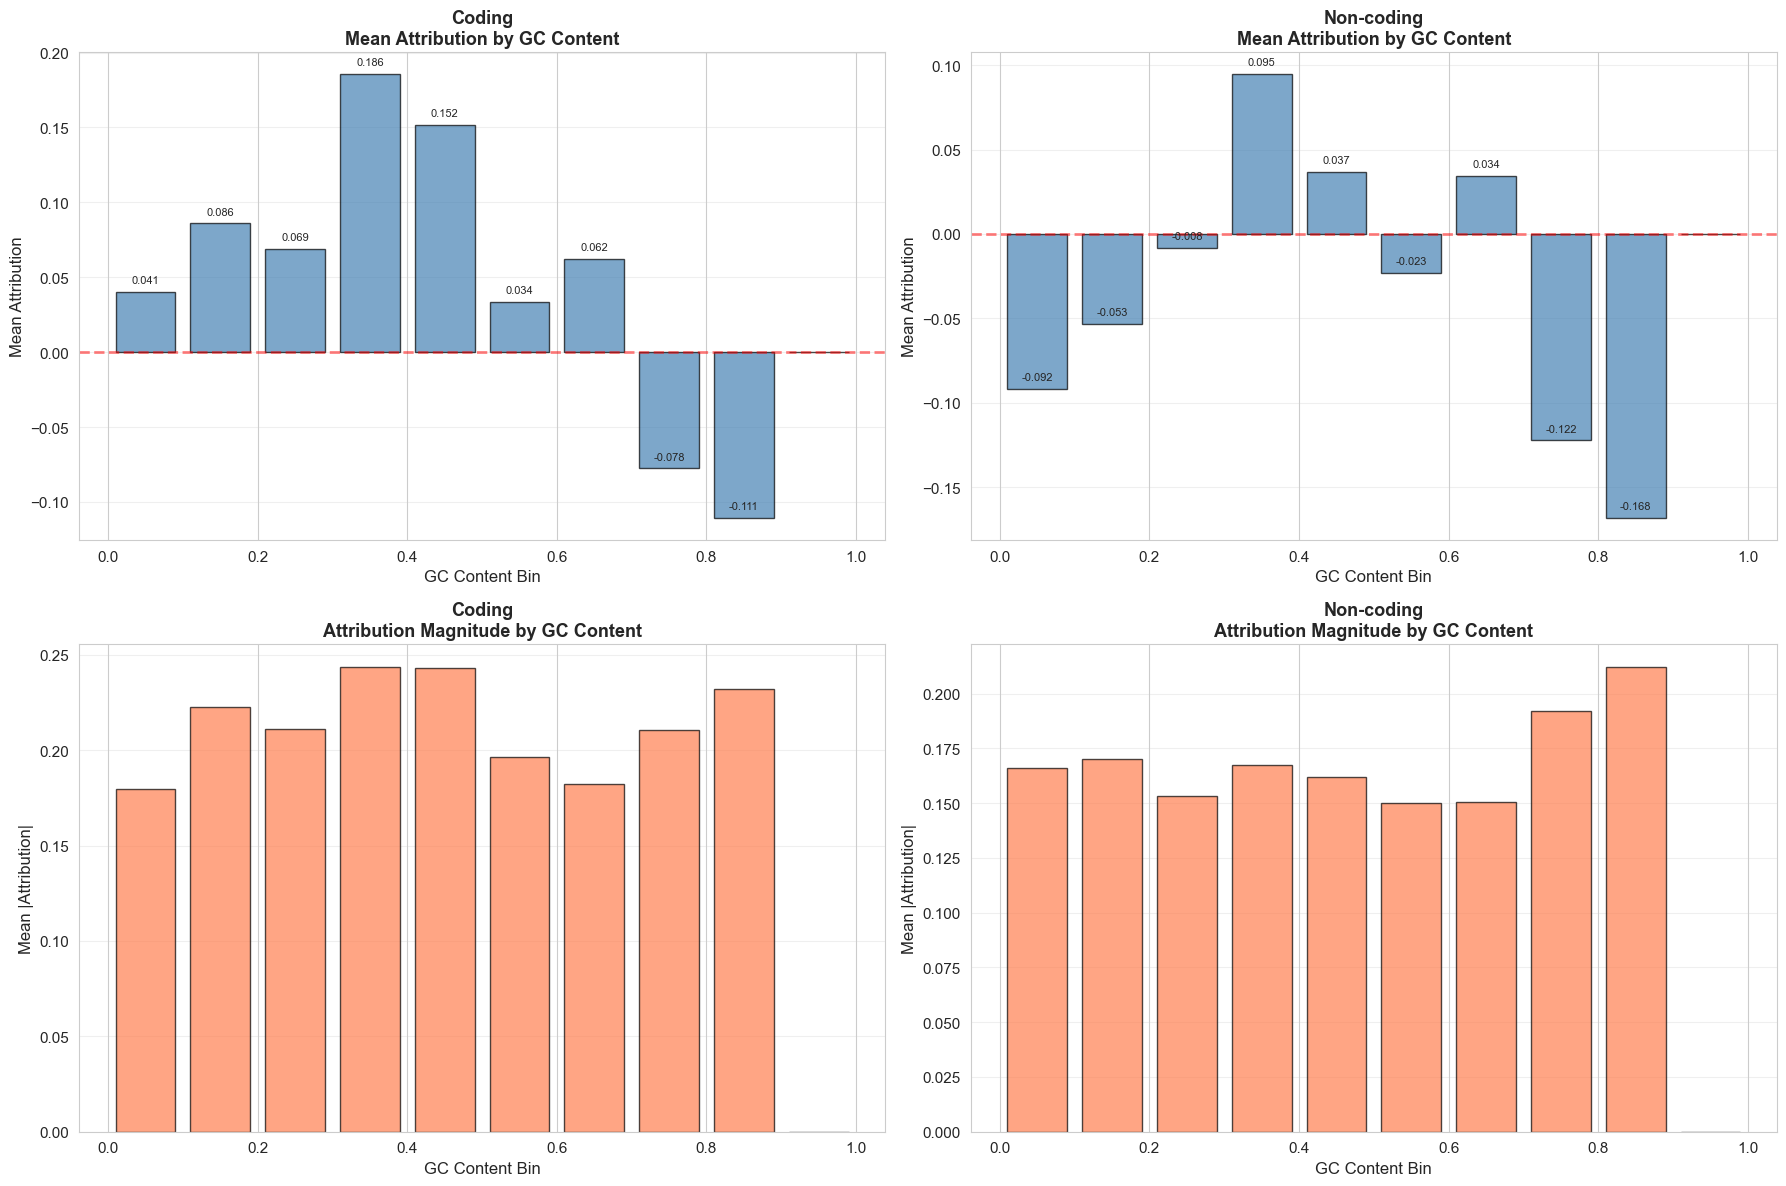

In [29]:
def stratified_gc_analysis(df, n_bins=10, only_correct=True):
    """
    Stratify tokens by GC content bins and analyze attribution patterns
    Shows how attribution changes across GC content spectrum
    """
    if only_correct:
        df = df[df['is_correct'] == True]
    
    def get_gc_content(token):
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        gc_count = token.upper().count('G') + token.upper().count('C')
        return gc_count / len(token) if len(token) > 0 else 0
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    for col_idx, seq_type in enumerate(['coding', 'non-coding']):
        subset = df[df['sequence_type'] == seq_type]
        
        # Collect data
        gc_attr_pairs = []
        
        for _, row in subset.iterrows():
            tokens = row['tokens'].split('|')
            attrs = [float(x) for x in row['attributions'].split('|')]
            
            for token, attr in zip(tokens, attrs):
                gc = get_gc_content(token)
                if gc is not None:
                    gc_attr_pairs.append((gc, attr))
        
        # Create bins
        gc_values = [x[0] for x in gc_attr_pairs]
        attr_values = [x[1] for x in gc_attr_pairs]
        
        bins = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # Stratify data
        mean_attrs = []
        median_attrs = []
        mean_abs_attrs = []
        positive_fractions = []
        counts = []
        
        for i in range(n_bins):
            bin_mask = (np.array(gc_values) >= bins[i]) & (np.array(gc_values) < bins[i+1])
            bin_attrs = np.array(attr_values)[bin_mask]
            
            if len(bin_attrs) > 0:
                mean_attrs.append(np.mean(bin_attrs))
                median_attrs.append(np.median(bin_attrs))
                mean_abs_attrs.append(np.mean(np.abs(bin_attrs)))
                positive_fractions.append(np.sum(bin_attrs > 0) / len(bin_attrs))
                counts.append(len(bin_attrs))
            else:
                mean_attrs.append(0)
                median_attrs.append(0)
                mean_abs_attrs.append(0)
                positive_fractions.append(0)
                counts.append(0)
        
        # Plot 1: Mean Attribution by GC bin
        axes[0, col_idx].bar(bin_centers, mean_attrs, width=1/n_bins*0.8, 
                            alpha=0.7, edgecolor='black', color='steelblue')
        axes[0, col_idx].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
        axes[0, col_idx].set_xlabel('GC Content Bin', fontsize=12)
        axes[0, col_idx].set_ylabel('Mean Attribution', fontsize=12)
        axes[0, col_idx].set_title(f'{seq_type.capitalize()}\nMean Attribution by GC Content',
                                   fontsize=13, fontweight='bold')
        axes[0, col_idx].grid(True, alpha=0.3, axis='y')
        
        # Add values on bars
        for i, (bc, val) in enumerate(zip(bin_centers, mean_attrs)):
            if counts[i] > 0:
                axes[0, col_idx].text(bc, val + (max(mean_attrs) - min(mean_attrs))*0.02,
                                     f'{val:.3f}', ha='center', fontsize=8)
        
        # Plot 2: Mean |Attribution| by GC bin
        axes[1, col_idx].bar(bin_centers, mean_abs_attrs, width=1/n_bins*0.8,
                            alpha=0.7, edgecolor='black', color='coral')
        axes[1, col_idx].set_xlabel('GC Content Bin', fontsize=12)
        axes[1, col_idx].set_ylabel('Mean |Attribution|', fontsize=12)
        axes[1, col_idx].set_title(f'{seq_type.capitalize()}\nAttribution Magnitude by GC Content',
                                   fontsize=13, fontweight='bold')
        axes[1, col_idx].grid(True, alpha=0.3, axis='y')
        
        # Print statistics
        print(f"\n{'='*70}")
        print(f"{seq_type.upper()} - Stratified GC Analysis")
        print(f"{'='*70}")
        print(f"\n{'GC Bin':<15} {'Mean Attr':<15} {'Mean |Attr|':<15} {'% Positive':<15} {'Count':<10}")
        print("-" * 70)
        
        for i in range(n_bins):
            if counts[i] > 0:
                print(f"{bins[i]:.2f}-{bins[i+1]:.2f}    {mean_attrs[i]:>12.4f}  {mean_abs_attrs[i]:>14.4f}  "
                      f"{positive_fractions[i]*100:>13.1f}%  {counts[i]:>8,}")
        
        # Find peak GC bin
        max_pos_idx = np.argmax(mean_attrs)
        max_neg_idx = np.argmin(mean_attrs)
        print(f"\nKey Findings:")
        print(f"  Highest positive attribution: GC={bins[max_pos_idx]:.2f}-{bins[max_pos_idx+1]:.2f}, "
              f"mean={mean_attrs[max_pos_idx]:.4f}")
        print(f"  Highest negative attribution: GC={bins[max_neg_idx]:.2f}-{bins[max_neg_idx+1]:.2f}, "
              f"mean={mean_attrs[max_neg_idx]:.4f}")
    
    plt.tight_layout()
    plt.show()

# Run stratified analysis
stratified_gc_analysis(df, n_bins=10, only_correct=True)

## Analysis 4: Predictive Power of GC Content Alone

PREDICTIVE POWER OF GC CONTENT

Mean GC only:
  Accuracy: 0.7976 (79.76%)
  AUC-ROC: 0.8924
  Features used: mean_gc
  Model: P(coding) = sigmoid(16.8443 * mean_GC + -8.0576)
  → Higher GC → More likely coding

Mean + Std GC:
  Accuracy: 0.7987 (79.87%)
  AUC-ROC: 0.8933
  Features used: mean_gc, std_gc

All GC features:
  Accuracy: 0.7985 (79.85%)
  AUC-ROC: 0.8925
  Features used: mean_gc, median_gc, std_gc, max_gc, min_gc


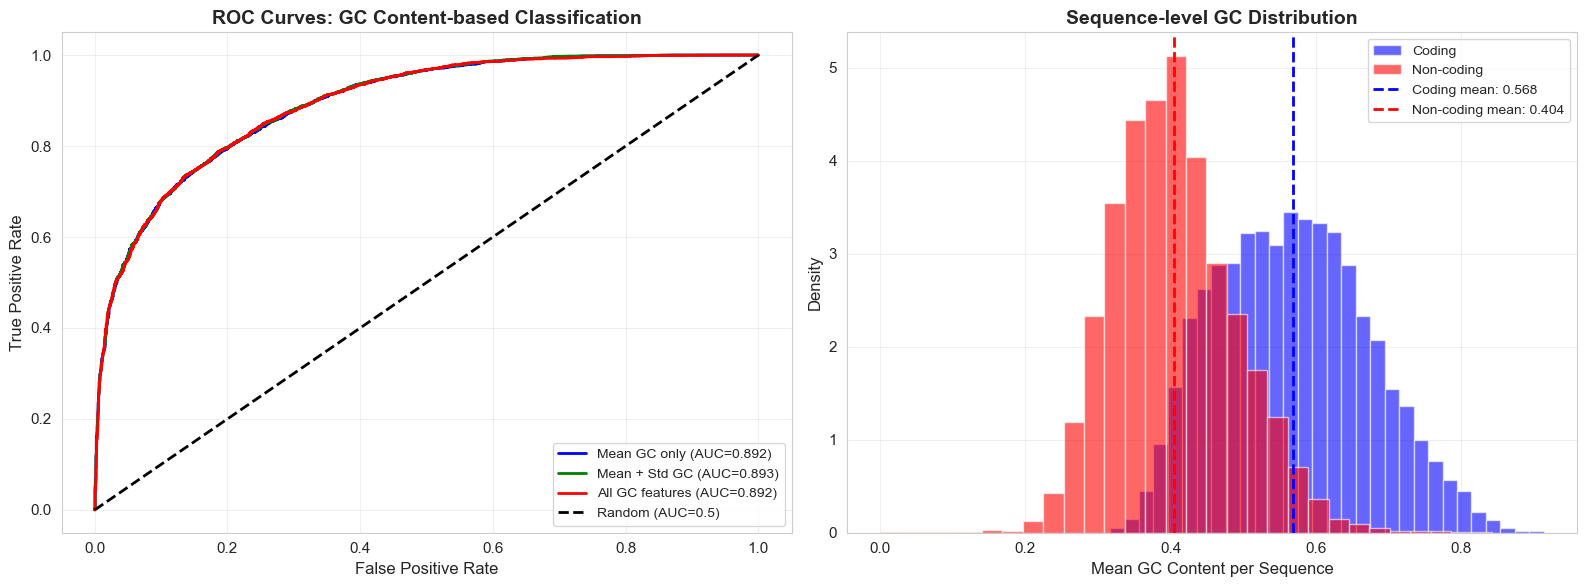


INTERPRETATION

Best single feature predictor: Mean + Std GC
  Achieves 79.87% accuracy
  AUC: 0.8933

GROVER model accuracy: 89.07%
GC-content-only accuracy: 79.87%
Gap: 9.20%

→ GC content is HIGHLY PREDICTIVE of sequence type
→ Model likely relies heavily on compositional bias


In [30]:
def gc_content_predictive_power(df, only_correct=True):
    """
    Test how well GC content alone can predict sequence type
    Uses simple logistic regression
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
    from sklearn.model_selection import train_test_split
    
    if only_correct:
        df_filtered = df[df['is_correct'] == True]
    else:
        df_filtered = df
    
    def get_gc_content(token):
        if not token or token in ['[CLS]', '[SEP]', '<s>', '</s>', '<pad>', '[PAD]']:
            return None
        gc_count = token.upper().count('G') + token.upper().count('C')
        return gc_count / len(token) if len(token) > 0 else 0
    
    # Aggregate GC content per sequence
    sequence_data = []
    
    for _, row in df_filtered.iterrows():
        tokens = row['tokens'].split('|')
        gc_values = []
        
        for token in tokens:
            gc = get_gc_content(token)
            if gc is not None:
                gc_values.append(gc)
        
        if len(gc_values) > 0:
            sequence_data.append({
                'mean_gc': np.mean(gc_values),
                'median_gc': np.median(gc_values),
                'std_gc': np.std(gc_values),
                'max_gc': np.max(gc_values),
                'min_gc': np.min(gc_values),
                'label': 1 if row['sequence_type'] == 'coding' else 0,  # 1=coding, 0=non-coding
                'true_label': row['sequence_type']
            })
    
    seq_df = pd.DataFrame(sequence_data)
    
    print("="*80)
    print("PREDICTIVE POWER OF GC CONTENT")
    print("="*80)
    
    # Test with different GC features
    feature_sets = {
        'Mean GC only': ['mean_gc'],
        'Mean + Std GC': ['mean_gc', 'std_gc'],
        'All GC features': ['mean_gc', 'median_gc', 'std_gc', 'max_gc', 'min_gc']
    }
    
    results = {}
    
    for feature_name, features in feature_sets.items():
        X = seq_df[features].values
        y = seq_df['label'].values
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
        
        # Train logistic regression
        model = LogisticRegression(random_state=42)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        results[feature_name] = {
            'accuracy': accuracy,
            'auc': auc,
            'y_test': y_test,
            'y_prob': y_prob,
            'model': model,
            'features': features
        }
        
        print(f"\n{feature_name}:")
        print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"  AUC-ROC: {auc:.4f}")
        print(f"  Features used: {', '.join(features)}")
        
        if len(features) == 1:
            coef = model.coef_[0][0]
            intercept = model.intercept_[0]
            print(f"  Model: P(coding) = sigmoid({coef:.4f} * mean_GC + {intercept:.4f})")
            print(f"  → {'Higher' if coef > 0 else 'Lower'} GC → {'More' if coef > 0 else 'Less'} likely coding")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: ROC curves
    colors = ['blue', 'green', 'red']
    for (feature_name, result), color in zip(results.items(), colors):
        fpr, tpr, _ = roc_curve(result['y_test'], result['y_prob'])
        axes[0].plot(fpr, tpr, linewidth=2, label=f'{feature_name} (AUC={result["auc"]:.3f})',
                    color=color)
    
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5)')
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curves: GC Content-based Classification', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: GC distribution by sequence type
    coding_gc = seq_df[seq_df['label'] == 1]['mean_gc']
    noncoding_gc = seq_df[seq_df['label'] == 0]['mean_gc']
    
    axes[1].hist(coding_gc, bins=30, alpha=0.6, label='Coding', color='blue', density=True)
    axes[1].hist(noncoding_gc, bins=30, alpha=0.6, label='Non-coding', color='red', density=True)
    axes[1].axvline(np.mean(coding_gc), color='blue', linestyle='--', linewidth=2,
                   label=f'Coding mean: {np.mean(coding_gc):.3f}')
    axes[1].axvline(np.mean(noncoding_gc), color='red', linestyle='--', linewidth=2,
                   label=f'Non-coding mean: {np.mean(noncoding_gc):.3f}')
    axes[1].set_xlabel('Mean GC Content per Sequence', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].set_title('Sequence-level GC Distribution', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*80)
    print("INTERPRETATION")
    print("="*80)
    best_result = max(results.items(), key=lambda x: x[1]['accuracy'])
    print(f"\nBest single feature predictor: {best_result[0]}")
    print(f"  Achieves {best_result[1]['accuracy']*100:.2f}% accuracy")
    print(f"  AUC: {best_result[1]['auc']:.4f}")
    
    # Compare with model accuracy
    model_accuracy = df['is_correct'].sum() / len(df)
    print(f"\nGROVER model accuracy: {model_accuracy*100:.2f}%")
    print(f"GC-content-only accuracy: {best_result[1]['accuracy']*100:.2f}%")
    print(f"Gap: {(model_accuracy - best_result[1]['accuracy'])*100:.2f}%")
    
    if best_result[1]['accuracy'] > 0.7:
        print(f"\n→ GC content is HIGHLY PREDICTIVE of sequence type")
        print(f"→ Model likely relies heavily on compositional bias")
    elif best_result[1]['accuracy'] > 0.6:
        print(f"\n→ GC content is MODERATELY PREDICTIVE")
        print(f"→ Model uses GC content but also other features")
    else:
        print(f"\n→ GC content is WEAKLY PREDICTIVE")
        print(f"→ Model relies more on motifs than composition")
    
    return results

# Run predictive power analysis
gc_prediction_results = gc_content_predictive_power(df, only_correct=True)

## Summary: AT/GC Content Analysis Interpretation Guide

### Key Questions to Answer:

1. **Statistical Significance (Analysis 1)**
   - Are the AT/GC differences between coding/non-coding statistically significant?
   - **If significant**: GC bias exists in the data and could be learned by the model
   - **If not significant**: Model cannot be relying on compositional bias

2. **Attribution Relationship (Analysis 2)**
   - How does GC content correlate with attribution magnitude?
   - **Strong positive correlation**: Higher GC → Higher attribution → Model uses GC as signal
   - **No correlation**: Model doesn't care about GC directly
   - **Sign analysis**: Do high-GC tokens predict one class more than the other?

3. **GC Spectrum Patterns (Analysis 3)**
   - Do attributions show threshold effects at certain GC levels?
   - **Sharp transitions**: Model learned GC cutoff rule
   - **Gradual trends**: Model uses GC as continuous feature
   - **No pattern**: GC content not systematically used

4. **Predictive Power (Analysis 4)**
   - Can GC content alone classify sequences?
   - **High accuracy (>70%)**: Compositional bias is dominant signal
   - **Moderate accuracy (60-70%)**: GC is informative but not sufficient
   - **Low accuracy (<60%)**: Motifs/patterns matter more than composition

### Overall Interpretation Framework:

| Scenario | Interpretation | Implication |
|----------|----------------|-------------|
| **All analyses point to GC** | Significant differences + Strong correlations + High predictive power | Model primarily uses compositional bias |
| **Mixed signals** | Some GC influence but not dominant | Model uses GC as one of many features |
| **GC not important** | Weak/no correlations + Low predictive power | Model focuses on specific motifs/patterns |

### Next Steps Based on Results:

- **If compositional bias dominates**: 
  - Test model on GC-normalized sequences
  - Check if model generalizes to sequences with atypical GC content
  - Consider if this is biologically meaningful or dataset artifact

- **If motifs dominate**:
  - Focus on the discriminative motifs identified earlier
  - Compare with known regulatory elements
  - Validate motif importance via perturbation

- **If mixed**:
  - Interaction analysis: How do motifs interact with GC content?
  - Context-dependent analysis: When does model use GC vs motifs?